# Unsupervised Pretraining + Robust Supervised Head for Temporal Collision Risk

This notebook implements the following pipeline:

1. **Data loading** from a `safe_col_mix.txt` file with per-frame features and labels.
2. **Unsupervised pretraining** of a temporal Transformer encoder as an autoencoder on trajectory sequences (ignoring labels).
3. **Supervised fine-tuning** of a classifier head on top of the pretrained encoder, using a **robust bootstrapped loss** to mitigate label flipping.
4. (Optional) Simple evaluation and inspection utilities.

You should adapt the path to your TXT file and adjust hyperparameters as needed for your data and GPU.


In [2]:
import os
import math
import numpy as np
from typing import List, Tuple
import torch
import joblib
import pickle

import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib.lines import lineStyles
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import f1_score
import time
from sklearn.manifold import TSNE

# Optional: for simple metrics
try:
    from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, precision_score
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Path to your mixed safe/collision TXT file
TXT_PATH = "safe_col_mix.txt"  # <-- change this to your actual path




Using device: cuda


## Data Loading Utilities

In [2]:
def load_mix_txt(path: str) -> np.ndarray:
    """Load TXT file with columns:
    0: time/frame index
    1: distance
    2: angle
    3: sin(yaw)
    4: cos(yaw)
    5: speed
    6: frame-level label (0 = safe, 1 = collision)
    7: sequence_id
    """
    data = np.loadtxt(path)
    if data.ndim == 1:
        data = data[None, :]  # ensure 2D
    return data


def group_sequences_with_frame_labels(data: np.ndarray):
    """Group flat data by sequence_id and sort by time.

    Returns:
        sequences: list of arrays, each of shape (T_i, 5) with features
                   [distance, angle, sin(yaw), cos(yaw), speed]
        frame_labels: list of arrays, each of shape (T_i,) with 0/1 labels
        seq_ids: list of sequence ids
    """
    seq_col = data[:, 7].astype(int)
    time_col = data[:, 0]
    unique_ids = np.unique(seq_col)

    sequences = []
    frame_labels = []
    seq_ids = []

    for sid in unique_ids:
        mask = (seq_col == sid)
        seq_data = data[mask]
        # sort by time
        order = np.argsort(seq_data[:, 0])
        seq_data = seq_data[order]

        # features: columns 1..5
        X = seq_data[:, 1:6].astype(np.float32)
        y = seq_data[:, 6].astype(np.float32)

        sequences.append(X)
        frame_labels.append(y)
        seq_ids.append(int(sid))

    return sequences, frame_labels, seq_ids


# Quick sanity check (only if file exists)
if os.path.exists(TXT_PATH):
    raw_data = load_mix_txt(TXT_PATH)
    sequences, frame_labels, seq_ids = group_sequences_with_frame_labels(raw_data)
    print(f"Loaded {len(sequences)} sequences from {TXT_PATH}")
else:
    print(f"WARNING: TXT_PATH '{TXT_PATH}' not found. Please update the path.")


Loaded 981 sequences from safe_col_mix.txt


## Datasets: Unsupervised and Supervised (Prefix-Based)

In [3]:
class UnsupervisedSeqDataset(Dataset):
    """Dataset for unsupervised pretraining.

    Returns full sequences (T_i, 5), ignoring labels.
    """
    def __init__(self, txt_path: str):
        data = load_mix_txt(txt_path)
        sequences, _, _ = group_sequences_with_frame_labels(data)
        self.seqs = [torch.tensor(s, dtype=torch.float32) for s in sequences]

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        return self.seqs[idx]


def build_current_risk_prefixes(
    sequences: List[np.ndarray],
    frame_labels: List[np.ndarray],
    min_len: int = 2,
    max_len: int = None,
):
    """Build prefix sequences and labels = last-frame label for each prefix.

    For each sequence of length T:
        prefixes of length L in [min_len, ..., T] (or up to max_len if set).
        label of prefix = y_seq[L-1]
    """
    prefix_seqs = []
    prefix_labels = []

    for X, y in zip(sequences, frame_labels):
        T = X.shape[0]
        if T < min_len:
            continue
        L_max = T if max_len is None else min(max_len, T)
        for L in range(min_len, L_max + 1):
            prefix_seqs.append(X[:L].astype(np.float32))
            prefix_labels.append(float(y[L - 1]))

    return prefix_seqs, np.array(prefix_labels, dtype=np.float32)


class CurrentRiskPrefixDataset(Dataset):
    """Supervised dataset of variable-length prefixes with binary labels.

    Each sample:
        X: (L, 5) prefix of a trajectory
        y: scalar, last-frame label in {0,1}
    """
    def __init__(self, txt_path: str, min_len: int = 2, max_len: int = None):
        data = load_mix_txt(txt_path)
        sequences, frame_labels, _ = group_sequences_with_frame_labels(data)
        prefix_seqs, prefix_labels = build_current_risk_prefixes(
            sequences, frame_labels, min_len=min_len, max_len=max_len
        )
        self.seqs = [torch.tensor(s, dtype=torch.float32) for s in prefix_seqs]
        self.labels = torch.tensor(prefix_labels, dtype=torch.float32)

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        return self.seqs[idx], self.labels[idx]


## Collate Functions (Padding Variable-Length Sequences)

In [4]:
def pad_collate_unsupervised(batch):
    """Collate function for UnsupervisedSeqDataset.

    Args:
        batch: list of tensors [T_i, F]

    Returns:
        padded: (B, T_max, F)
        pad_mask: (B, T_max) bool, True where padding
    """
    lengths = [x.shape[0] for x in batch]
    padded = pad_sequence(batch, batch_first=True)  # (B, T_max, F)
    T_max = padded.shape[1]

    # pad_mask: True where positions are padding
    idxs = torch.arange(T_max).unsqueeze(0).expand(len(lengths), -1)
    lengths_tensor = torch.tensor(lengths).unsqueeze(1)
    pad_mask = idxs >= lengths_tensor

    return padded, pad_mask


def pad_collate_supervised(batch):
    """Collate function for supervised prefix dataset.

    Args:
        batch: list of (tensor[T_i, F], label)

    Returns:
        padded: (B, T_max, F)
        labels: (B,)
        pad_mask: (B, T_max) bool
    """
    seqs, labels = zip(*batch)
    lengths = [x.shape[0] for x in seqs]
    padded = pad_sequence(seqs, batch_first=True)  # (B, T_max, F)
    T_max = padded.shape[1]

    idxs = torch.arange(T_max).unsqueeze(0).expand(len(lengths), -1)
    lengths_tensor = torch.tensor(lengths).unsqueeze(1)
    pad_mask = idxs >= lengths_tensor

    labels = torch.stack(labels)  # (B,)
    return padded, labels, pad_mask


## Temporal Encoder (Transformer) and Positional Encoding

In [5]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding for sequences with batch_first=True.

    Expects input of shape (B, T, D).
    """
    def __init__(self, d_model: int, max_len: int = 500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, D)
        T = x.size(1)
        x = x + self.pe[:, :T, :]
        return x


class TemporalEncoder(nn.Module):
    """Shared temporal encoder: input_dim -> d_model via TransformerEncoder."""
    def __init__(
        self,
        input_dim: int = 5,
        d_model: int = 64,
        nhead: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 128,
        dropout: float = 0.1,
        max_len: int = 500,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.d_model = d_model

        self.in_proj = nn.Linear(input_dim, d_model)
        self.pos = PositionalEncoding(d_model, max_len=max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x: torch.Tensor, pad_mask: torch.Tensor = None) -> torch.Tensor:
        """Forward pass.

        Args:
            x: (B, T, input_dim)
            pad_mask: (B, T) bool, True where padding

        Returns:
            h: (B, T, d_model)
        """
        h = self.in_proj(x)
        h = self.pos(h)
        h = self.encoder(h, src_key_padding_mask=pad_mask)
        return h


## Unsupervised Autoencoder Model (Pretraining Stage)

In [6]:
class TemporalAutoencoder(nn.Module):
    """Temporal autoencoder: encoder + linear decoder back to input_dim."""
    def __init__(self, encoder: TemporalEncoder):
        super().__init__()
        self.encoder = encoder
        self.out_proj = nn.Linear(encoder.d_model, encoder.input_dim)

    def forward(self, x: torch.Tensor, pad_mask: torch.Tensor = None) -> torch.Tensor:
        """Reconstruct the input sequence.

        Args:
            x: (B, T, input_dim)
            pad_mask: (B, T) bool

        Returns:
            x_hat: (B, T, input_dim)
        """
        h = self.encoder(x, pad_mask=pad_mask)
        x_hat = self.out_proj(h)
        return x_hat


## Supervised Classifier with Attention Pooling (Robust Head)

In [7]:
class TemporalRiskTransformer(nn.Module):
    """Transformer encoder + masked attention pooling -> sequence-level logit.

    Uses a pretrained TemporalEncoder and a small MLP head.
    """
    def __init__(self, encoder: TemporalEncoder, d_hidden: int = 64, dropout: float = 0.1):
        super().__init__()
        self.encoder = encoder

        d_model = encoder.d_model

        # Attention pooling over time
        self.pool = nn.Linear(d_model, 1)

        # Classification head
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, 1),
        )

    def forward(self, x: torch.Tensor, pad_mask: torch.Tensor = None):
        """Forward pass.

        Args:
            x: (B, T, input_dim)
            pad_mask: (B, T) bool

        Returns:
            logits: (B,) raw logits for collision probability
            z_seq: (B, d_model) pooled sequence representation
        """
        h = self.encoder(x, pad_mask=pad_mask)  # (B, T, d_model)

        # Attention logits over time
        att_logits = self.pool(h).squeeze(-1)  # (B, T)

        if pad_mask is not None:
            att_logits = att_logits.masked_fill(pad_mask, float("-inf"))

        att_weights = F.softmax(att_logits, dim=1)  # (B, T)

        # Weighted sum
        z_seq = torch.sum(h * att_weights.unsqueeze(-1), dim=1)  # (B, d_model)

        logits = self.head(z_seq).squeeze(-1)  # (B,)
        return logits, z_seq


## Robust Loss: Bootstrapped BCE (Mitigating Label Flipping)

In [8]:
def bootstrapped_bce_with_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
    beta: float = 0.8,
) -> torch.Tensor:
    """Bootstrapped binary cross-entropy with logits.

    targets: (B,) in {0,1}
    We mix the noisy targets with the model's own predictions to reduce the
    influence of flipped labels.

    y_soft = beta * y + (1 - beta) * p.detach()
    loss = BCEWithLogits(logits, y_soft)
    """
    probs = torch.sigmoid(logits)
    y_soft = beta * targets + (1.0 - beta) * probs.detach()
    loss = F.binary_cross_entropy_with_logits(logits, y_soft)
    return loss


In [9]:

# === nnPU (Positive–Unlabeled) loss for collision (positive) vs safe (unlabeled) ===
import torch.nn.functional as F

def nnpu_loss(
    logits: torch.Tensor,
    targets: torch.Tensor,
    prior: float,
    gamma: float = 1.0,
    beta: float = 0.0,
) -> torch.Tensor:
    # nnPU loss (non-negative PU) with logistic loss.
    #
    # logits: (B,)
    # targets: (B,) in {0, 1}, where:
    #     1 = positive (collision)
    #     0 = unlabeled (safe / mixture)
    #
    # prior: π_p, estimated positive prior (collision prior) in the training set.
    # gamma, beta: hyperparameters controlling how aggressively to handle negative risk.

    # Ensure float
    y = targets.float()
    logits = logits.view(-1)

    # Masks
    pos_mask = (y == 1)
    unl_mask = (y == 0)

    # Logistic loss for y=+1 and y=-1
    # l(f, +1) = log(1 + exp(-f)) = softplus(-f)
    # l(f, -1) = log(1 + exp(f))  = softplus(f)
    def loss_pos(z):
        return F.softplus(-z)

    def loss_neg(z):
        return F.softplus(z)

    device = logits.device

    if pos_mask.any():
        pos_logits = logits[pos_mask]
        L_p_pos = loss_pos(pos_logits).mean()          # E_p[l(f, +1)]
        L_p_neg = loss_neg(pos_logits).mean()          # E_p[l(f, -1)]
    else:
        # No positive examples in this batch; set to zero
        L_p_pos = torch.tensor(0.0, device=device)
        L_p_neg = torch.tensor(0.0, device=device)

    if unl_mask.any():
        unl_logits = logits[unl_mask]
        L_u_neg = loss_neg(unl_logits).mean()          # E_u[l(f, -1)]
    else:
        L_u_neg = torch.tensor(0.0, device=device)

    # Positive risk
    risk_positive = prior * L_p_pos

    # Negative risk estimate
    risk_negative = L_u_neg - prior * L_p_neg

    # Non-negative PU trick
    if risk_negative.item() < -beta:
        # In this regime, flip the sign of the negative risk and scale by gamma
        loss = risk_positive - gamma * risk_negative
    else:
        loss = risk_positive + risk_negative

    return loss

def upu_loss(
    logits: torch.Tensor,
    targets: torch.Tensor,
    prior: float,
    gamma: float = 1.0,
    beta: float = 0.0,
) -> torch.Tensor:
    """Unbiased PU (uPU) loss — same as nnPU but WITHOUT non-negative clipping."""

    y = targets.float()
    logits = logits.view(-1)

    pos_mask = (y == 1)
    unl_mask = (y == 0)

    def loss_pos(z):
        return F.softplus(-z)

    def loss_neg(z):
        return F.softplus(z)

    # Positive risk
    if pos_mask.sum() > 0:
        L_p_pos = loss_pos(logits[pos_mask]).mean()
        L_p_neg = loss_neg(logits[pos_mask]).mean()
    else:
        L_p_pos = torch.tensor(0.0, device=logits.device)
        L_p_neg = torch.tensor(0.0, device=logits.device)

    # Unlabeled risk
    if unl_mask.sum() > 0:
        L_u_neg = loss_neg(logits[unl_mask]).mean()
    else:
        L_u_neg = torch.tensor(0.0, device=logits.device)

    risk_positive = prior * L_p_pos
    risk_negative = L_u_neg - prior * L_p_neg  # <-- NO max(0, ...) here

    loss = risk_positive + risk_negative
    return loss


## Stage 1: Unsupervised Pretraining of the Encoder

In [33]:
# Hyperparameters for the encoder and AE
encoder = TemporalEncoder(
    input_dim=5,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.1,
    max_len=500,
)
encoder.to(device)

ae_model = TemporalAutoencoder(encoder).to(device)

ae_epochs = 20           # adjust as needed
ae_batch_size = 16       # adjust based on GPU memory
ae_lr = 1e-3
ae_weight_decay = 1e-4

ae_optimizer = torch.optim.AdamW(ae_model.parameters(), lr=ae_lr, weight_decay=ae_weight_decay)
ae_criterion = nn.MSELoss()

if os.path.exists(TXT_PATH):
    unsup_ds = UnsupervisedSeqDataset(TXT_PATH)
    unsup_loader = DataLoader(
        unsup_ds,
        batch_size=ae_batch_size,
        shuffle=True,
        collate_fn=pad_collate_unsupervised,
    )
    print(f"Unsupervised dataset size: {len(unsup_ds)} sequences")
else:
    unsup_ds = None
    unsup_loader = None
    print("Unsupervised dataset not created because TXT file is missing.")

if unsup_loader is not None:
    for epoch in range(1, ae_epochs + 1):
        ae_model.train()
        epoch_loss = 0.0
        for X, pad_mask in unsup_loader:
            X = X.to(device)
            pad_mask = pad_mask.to(device)

            X_hat = ae_model(X, pad_mask=pad_mask)
            loss = ae_criterion(X_hat, X)

            ae_optimizer.zero_grad()
            loss.backward()
            ae_optimizer.step()

            epoch_loss += loss.item()

        mean_loss = epoch_loss / len(unsup_loader)
        print(f"[AE] Epoch {epoch}/{ae_epochs} - MSE Loss: {mean_loss:.6f}")
else:
    print("Skip AE training (no data).")


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Unsupervised dataset size: 981 sequences
[AE] Epoch 1/20 - MSE Loss: 2.127623
[AE] Epoch 2/20 - MSE Loss: 0.153240
[AE] Epoch 3/20 - MSE Loss: 0.082357
[AE] Epoch 4/20 - MSE Loss: 0.056104
[AE] Epoch 5/20 - MSE Loss: 0.042732
[AE] Epoch 6/20 - MSE Loss: 0.034246
[AE] Epoch 7/20 - MSE Loss: 0.028629
[AE] Epoch 8/20 - MSE Loss: 0.023827
[AE] Epoch 9/20 - MSE Loss: 0.020811
[AE] Epoch 10/20 - MSE Loss: 0.018316
[AE] Epoch 11/20 - MSE Loss: 0.016340
[AE] Epoch 12/20 - MSE Loss: 0.014543
[AE] Epoch 13/20 - MSE Loss: 0.012941
[AE] Epoch 14/20 - MSE Loss: 0.011731
[AE] Epoch 15/20 - MSE Loss: 0.010778
[AE] Epoch 16/20 - MSE Loss: 0.009716
[AE] Epoch 17/20 - MSE Loss: 0.008694
[AE] Epoch 18/20 - MSE Loss: 0.008163
[AE] Epoch 19/20 - MSE Loss: 0.007469
[AE] Epoch 20/20 - MSE Loss: 0.006875


In [34]:
# Save Stage 1 pretrained encoder weights
torch.save(ae_model.encoder.state_dict(), "pretrained_encoder1.pt")
print("Stage 1 encoder saved.")

Stage 1 encoder saved.


## Stage 2: Supervised Fine-Tuning with Robust Head

In [35]:
class LabelFlipWrapper(Dataset):
    """
    Wraps any dataset returning (x, y) with y in {0,1}.
    Flips y for a percentage of samples (symmetric flipping: 0<->1).
    """
    def __init__(self, base_ds, flip_pct: float, seed: int = 0):
        assert 0.0 <= flip_pct <= 1.0
        self.base_ds = base_ds
        self.flip_pct = flip_pct

        n = len(base_ds)
        k = int(round(flip_pct * n))

        g = torch.Generator()
        g.manual_seed(seed)

        perm = torch.randperm(n, generator=g)
        flip_local_idx = perm[:k]
        self.flip_mask = torch.zeros(n, dtype=torch.bool)
        self.flip_mask[flip_local_idx] = True

    def __len__(self):
        return len(self.base_ds)

    def __getitem__(self, i):
        x, y = self.base_ds[i]
        # ensure scalar 0/1 float
        y = float(y)
        if self.flip_mask[i]:
            y = 1.0 - y
        return x, torch.tensor(y, dtype=torch.float32)

In [39]:
# Create a fresh encoder
encoder = TemporalEncoder(
    input_dim=5, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1, max_len=500,)

# Load Stage 1 weights into it
encoder.load_state_dict(torch.load("pretrained_encoder.pt"))

# Create the classifier using this encoder
clf_model = TemporalRiskTransformer(encoder=encoder).to(device)

print("Fresh model with pretrained encoder loaded.")

# Now run Stage 2 with your chosen prior
pos_prior = 0.1# change this for each run: 0.05, 0.10, 0.15, 0.20, 0.25, 0.30

Fresh model with pretrained encoder loaded.


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
C:\Users\l_daryel\AppData\Local\Temp\ipykernel_17624\2031456202.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend y

In [40]:
# Optionally: freeze some or all encoder parameters at the start
freeze_encoder = False  # set True to freeze encoder fully
if freeze_encoder:
    for p in clf_model.encoder.parameters():
        p.requires_grad = False

# PU-learning dataset (prefix-based: collision = positive, safe = unlabeled)
if os.path.exists(TXT_PATH):
    sup_ds = CurrentRiskPrefixDataset(TXT_PATH, min_len=2, max_len=None)
    print(f"Supervised prefix dataset size: {len(sup_ds)} samples")
    torch.manual_seed(42)
    # Train/validation split
    n_total = len(sup_ds)
    n_train = int(0.8 * n_total)
    n_val = n_total - n_train
    train_ds, val_ds = random_split(sup_ds, [n_train, n_val])
    flip_pct = 0   # 10% label flipping
    flip_seed = 123

    #train_ds = LabelFlipWrapper(train_ds, flip_pct=flip_pct, seed=flip_seed)
    #train_ds = PositiveHideWrapper(
    #base_ds=train_ds,
    #hide_pct=0.7,          # hide 70% of positives → c = 0.3
    #unlabeled_value=0,
    #seed=42,)


    train_loader = DataLoader(
        train_ds,
        batch_size=32,
        shuffle=True,
        collate_fn=pad_collate_supervised,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=64,
        shuffle=False,
        collate_fn=pad_collate_supervised,
    )
else:
    sup_ds = None
    train_loader = None
    val_loader = None
    print("Supervised dataset not created because TXT file is missing.")

Supervised prefix dataset size: 13734 samples


In [41]:
# Training hyperparameters for supervised fine-tuning
clf_epochs = 200  # set high; early stopping will stop earlier
clf_lr = 1e-4  # smaller LR, since encoder is already pretrained
clf_weight_decay = 1e-4
boot_beta = 0.8

clf_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, clf_model.parameters()),
    lr=clf_lr,
    weight_decay=clf_weight_decay,
)

import copy

class EarlyStopping:
    def __init__(self, patience=8, min_delta=1e-4, mode="max"):
        """Simple early stopping with best-weight restore.
        mode="max": metric should increase (e.g., AUC)
        mode="min": metric should decrease (e.g., loss)
        """
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best = -np.inf if mode == "max" else np.inf
        self.num_bad_epochs = 0
        self.best_state = None

    def step(self, metric, model):
        improved = (metric > self.best + self.min_delta) if self.mode == "max" else (metric < self.best - self.min_delta)
        if improved:
            self.best = metric
            self.num_bad_epochs = 0
            self.best_state = copy.deepcopy(model.state_dict())
            return False
        self.num_bad_epochs += 1
        return self.num_bad_epochs >= self.patience

    def restore_best_weights(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def evaluate_classifier(model, loader, threshold=0.5):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for X, y, pad_mask in loader:
            X = X.to(device)
            y = y.to(device)
            pad_mask = pad_mask.to(device)

            logits, _ = model(X, pad_mask=pad_mask)
            probs = torch.sigmoid(logits)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(y.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    preds = (all_probs >= threshold).astype(np.int32)

    acc = accuracy_score(all_labels, preds)
    auc = roc_auc_score(all_labels, all_probs)
    recall = recall_score(all_labels, preds)
    f1 = f1_score(all_labels, preds)

    return acc, auc, recall, f1


if train_loader is not None:
    early_stopper = EarlyStopping(
    patience=8,
    min_delta=1e-3,
    mode="max")
    best_epoch = None

    for epoch in range(1, clf_epochs + 1):
        clf_model.train()
        epoch_loss = 0.0

        for X, y, pad_mask in train_loader:
            X = X.to(device)
            y = y.to(device)
            pad_mask = pad_mask.to(device)

            logits, _ = clf_model(X, pad_mask=pad_mask)
            # PU-learning: y==1 → collision (positive), y==0 → unlabeled (safe)
            loss = nnpu_loss(logits, y, prior=pos_prior, gamma=1.0, beta=0.0)

            clf_optimizer.zero_grad()
            loss.backward()
            clf_optimizer.step()

            epoch_loss += loss.item()

        mean_train_loss = epoch_loss / len(train_loader)

        # Validation (early stopping uses AUC when sklearn is available)
        if val_loader is not None and SKLEARN_AVAILABLE:
            acc, auc, recall, f1 = evaluate_classifier(clf_model, val_loader)

            print(
                f"[CLF] Epoch {epoch}/{clf_epochs} - Train loss: {mean_train_loss:.4f} - "
                f"Val ACC: {acc:.4f}, Val AUC: {auc:.4f}, "
                f"Val Recall: {recall:.4f}, Val F1: {f1:.4f}"
            )
            should_stop = early_stopper.step(f1, clf_model)
            if early_stopper.best_state is not None and best_epoch is None:
                best_epoch = epoch
            if f1 == early_stopper.best:
                best_epoch = epoch

            if should_stop:
                print(
                    f"Early stopping triggered at epoch {epoch}. "
                    f"Best Val F1={early_stopper.best:.4f} (epoch {best_epoch})."
                )
                break
        else:
            print(f"[CLF] Epoch {epoch}/{clf_epochs} - Train loss: {mean_train_loss:.4f}")

    # Restore best weights (if we had validation AUC)
    if val_loader is not None and SKLEARN_AVAILABLE:
        early_stopper.restore_best_weights(clf_model)
        if best_epoch is not None:
            print(f"Restored best model weights from epoch {best_epoch} (Val AUC={early_stopper.best:.4f}).")
else:
    print("Skip classifier training (no data).")


[CLF] Epoch 1/200 - Train loss: 0.3560 - Val ACC: 0.7597, Val AUC: 0.7694, Val Recall: 0.0000, Val F1: 0.0000
[CLF] Epoch 2/200 - Train loss: 0.2496 - Val ACC: 0.8078, Val AUC: 0.8842, Val Recall: 0.3152, Val F1: 0.4407
[CLF] Epoch 3/200 - Train loss: 0.1810 - Val ACC: 0.8544, Val AUC: 0.9148, Val Recall: 0.6833, Val F1: 0.6928
[CLF] Epoch 4/200 - Train loss: 0.1605 - Val ACC: 0.8609, Val AUC: 0.9356, Val Recall: 0.5394, Val F1: 0.6508
[CLF] Epoch 5/200 - Train loss: 0.1387 - Val ACC: 0.8773, Val AUC: 0.9468, Val Recall: 0.8364, Val F1: 0.7661
[CLF] Epoch 6/200 - Train loss: 0.1159 - Val ACC: 0.9137, Val AUC: 0.9615, Val Recall: 0.7909, Val F1: 0.8150
[CLF] Epoch 7/200 - Train loss: 0.1061 - Val ACC: 0.9054, Val AUC: 0.9679, Val Recall: 0.8758, Val F1: 0.8164
[CLF] Epoch 8/200 - Train loss: 0.1034 - Val ACC: 0.9279, Val AUC: 0.9718, Val Recall: 0.8621, Val F1: 0.8518
[CLF] Epoch 9/200 - Train loss: 0.0974 - Val ACC: 0.9225, Val AUC: 0.9668, Val Recall: 0.8000, Val F1: 0.8322
[CLF] Epoc

In [32]:
total_params = sum(p.numel() for p in clf_model.parameters())

trainable_params = sum(
    p.numel()
    for p in clf_model.parameters()
    if p.requires_grad
)


In [33]:
import os
import torch

torch.save(clf_model.state_dict(), "tf_nnpu_model.pt")

size_mb = os.path.getsize("tf_nnpu_model.pt") / (1024 ** 2)

print(f"Serialized model size: {size_mb:.3f} MB")

Serialized model size: 0.408 MB


In [34]:
from thop import profile

X = torch.randn(1, 15, 5).to(device)
pad_mask = torch.zeros(1, 15, dtype=torch.bool).to(device)

macs, params = profile(
    clf_model,
    inputs=(X, pad_mask),
    verbose=False
)

print("MACs:", macs)
print("FLOPs approx:", 2 * macs)

MACs: 517056.0
FLOPs approx: 1034112.0


In [35]:
torch.cuda.reset_peak_memory_stats()

X = torch.randn(1, 15, 5).to(device)
pad_mask = torch.zeros(
    1, 15,
    dtype=torch.bool,
    device=device
)

with torch.no_grad():
    _ = clf_model(X, pad_mask)

torch.cuda.synchronize()

peak_memory_mb = (
    torch.cuda.max_memory_allocated() / 1024**2
)

print(
    f"Peak inference memory: "
    f"{peak_memory_mb:.2f} MB"
)

Peak inference memory: 21.73 MB


In [37]:
import torch
import platform
import psutil

print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print(
    "GPU memory:",
    torch.cuda.get_device_properties(0).total_memory / 1e9
)
print("CPU:", platform.processor())
print("RAM:", psutil.virtual_memory().total / 1e9)

PyTorch: 2.5.1+cu121
CUDA: 12.1
GPU: NVIDIA RTX A400
GPU memory: 4.292345856
CPU: Intel64 Family 6 Model 143 Stepping 8, GenuineIntel
RAM: 67.914366976


In [16]:
# Save the full Stage 2 model (encoder + attention pooling + classification head)
torch.save(clf_model.state_dict(), "stage2_trained_model1.pt")
print("Stage 2 model saved.")

Stage 2 model saved.


In [38]:
# ============================================================
# COMPLETE COMPUTATIONAL COMPLEXITY + LATENCY ANALYSIS
# Reviewer 1 Comment 4 / Reviewer 2 Comment 1
#
# Assumptions:
#   - clf_model = trained TF-nnPU model
#   - device = torch.device("cuda" if ...)
#   - model forward:
#         logits, z = clf_model(X, pad_mask=pad_mask)
# ============================================================

import os
import sys
import time
import math
import tempfile
import platform
import numpy as np
import pandas as pd
import torch

# ============================================================
# CONFIGURATION
# ============================================================

PREFIX_LENGTHS = [2, 5, 8, 10, 15]

INPUT_DIM = 5
BATCH_SIZE = 1

SENSOR_FPS = 7.4
FRAME_BUDGET_MS = 1000.0 / SENSOR_FPS

N_WARMUP = 50
N_RUNS = 500

clf_model = clf_model.to(device)
clf_model.eval()

print("=" * 75)
print(" COMPUTATIONAL COMPLEXITY AND INFERENCE ANALYSIS")
print("=" * 75)


# ============================================================
# 1. HARDWARE / SOFTWARE INFORMATION
# ============================================================

print("\n" + "=" * 75)
print("1. HARDWARE / SOFTWARE")
print("=" * 75)

print(f"Python version : {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
print(f"PyTorch CUDA   : {torch.version.cuda}")
print(f"Operating system: {platform.platform()}")
print(f"CPU            : {platform.processor()}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(device)
    props = torch.cuda.get_device_properties(device)

    gpu_total_memory_gb = props.total_memory / (1024**3)

    print(f"GPU            : {gpu_name}")
    print(f"GPU memory     : {gpu_total_memory_gb:.2f} GiB")
    print(f"CUDA capability: {props.major}.{props.minor}")
else:
    gpu_name = "CPU"
    gpu_total_memory_gb = np.nan


# Optional RAM information
try:
    import psutil

    system_ram_gb = psutil.virtual_memory().total / (1024**3)
    print(f"System RAM     : {system_ram_gb:.2f} GiB")

except ImportError:
    system_ram_gb = np.nan
    print("System RAM     : psutil not installed")


# ============================================================
# 2. PARAMETER COUNT
# ============================================================

print("\n" + "=" * 75)
print("2. MODEL PARAMETERS")
print("=" * 75)

total_params = sum(
    p.numel() for p in clf_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in clf_model.parameters()
    if p.requires_grad
)

nontrainable_params = total_params - trainable_params


# Encoder/head split if the model has .encoder
if hasattr(clf_model, "encoder"):

    encoder_params = sum(
        p.numel()
        for p in clf_model.encoder.parameters()
    )

    head_params = total_params - encoder_params

else:
    encoder_params = np.nan
    head_params = np.nan


print(f"Total parameters        : {total_params:,}")
print(f"Trainable parameters    : {trainable_params:,}")
print(f"Non-trainable parameters: {nontrainable_params:,}")

if not np.isnan(encoder_params):
    print(f"Encoder parameters      : {encoder_params:,}")
    print(f"Head parameters         : {head_params:,}")


# ============================================================
# 3. PARAMETER MEMORY
# ============================================================

# Exact memory occupied by model parameters and buffers
parameter_bytes = sum(
    p.numel() * p.element_size()
    for p in clf_model.parameters()
)

buffer_bytes = sum(
    b.numel() * b.element_size()
    for b in clf_model.buffers()
)

model_memory_bytes = parameter_bytes + buffer_bytes
model_memory_mib = model_memory_bytes / (1024**2)

print("\nParameter/buffer memory")
print(f"Parameter memory : {parameter_bytes / 1024**2:.4f} MiB")
print(f"Buffer memory    : {buffer_bytes / 1024**2:.4f} MiB")
print(f"Total model memory: {model_memory_mib:.4f} MiB")


# ============================================================
# 4. SERIALIZED MODEL SIZE
# ============================================================

with tempfile.NamedTemporaryFile(
    suffix=".pt",
    delete=False
) as tmp:

    temp_model_path = tmp.name


torch.save(
    clf_model.state_dict(),
    temp_model_path
)

serialized_size_bytes = os.path.getsize(
    temp_model_path
)

serialized_size_mib = (
    serialized_size_bytes / (1024**2)
)

os.remove(temp_model_path)

print(
    f"Serialized state_dict size: "
    f"{serialized_size_mib:.4f} MiB"
)


# ============================================================
# 5. ESTIMATED FLOPs
# ============================================================
#
# Uses PyTorch profiler so no external profiling library
# is strictly required.
#
# NOTE:
# This should be described in the paper as
# "profiler-estimated FLOPs" because some inexpensive
# operations (activation, normalization, softmax, etc.)
# may not be fully counted.
# ============================================================

print("\n" + "=" * 75)
print("3. COMPUTATIONAL COST")
print("=" * 75)


def estimate_flops_pytorch(model, T, input_dim=5):

    X = torch.randn(
        1, T, input_dim,
        device=device
    )

    pad_mask = torch.zeros(
        1, T,
        dtype=torch.bool,
        device=device
    )

    activities = [
        torch.profiler.ProfilerActivity.CPU
    ]

    if device.type == "cuda":
        activities.append(
            torch.profiler.ProfilerActivity.CUDA
        )

    try:

        with torch.inference_mode():

            with torch.profiler.profile(
                activities=activities,
                with_flops=True,
                record_shapes=True
            ) as prof:

                _ = model(
                    X,
                    pad_mask=pad_mask
                )

        total_flops = 0

        for event in prof.key_averages():

            if event.flops is not None:
                total_flops += event.flops

        return float(total_flops)

    except Exception as e:

        print(
            "PyTorch FLOP profiler failed:",
            e
        )

        return np.nan


flop_results = {}

for T in PREFIX_LENGTHS:

    flops = estimate_flops_pytorch(
        clf_model,
        T,
        INPUT_DIM
    )

    # Approximate MAC count.
    # For multiply-accumulate dominated neural networks:
    # FLOPs ≈ 2 × MACs.
    macs_approx = (
        flops / 2.0
        if not np.isnan(flops)
        else np.nan
    )

    flop_results[T] = {
        "flops": flops,
        "macs": macs_approx
    }

    print(f"\nT = {T}")

    if not np.isnan(flops):

        print(
            f"Estimated FLOPs : "
            f"{flops / 1e6:.4f} MFLOPs"
        )

        print(
            f"Approx. MACs    : "
            f"{macs_approx / 1e6:.4f} MMACs"
        )

    else:

        print("FLOPs unavailable")


# ============================================================
# 6. PEAK INFERENCE MEMORY
# ============================================================

print("\n" + "=" * 75)
print("4. INFERENCE MEMORY")
print("=" * 75)


memory_results = {}


for T in PREFIX_LENGTHS:

    X = torch.randn(
        BATCH_SIZE,
        T,
        INPUT_DIM,
        device=device
    )

    pad_mask = torch.zeros(
        BATCH_SIZE,
        T,
        dtype=torch.bool,
        device=device
    )

    if device.type == "cuda":

        torch.cuda.empty_cache()
        torch.cuda.synchronize()

        # Memory before model forward
        baseline_allocated = (
            torch.cuda.memory_allocated(device)
        )

        torch.cuda.reset_peak_memory_stats(device)

        with torch.inference_mode():

            _ = clf_model(
                X,
                pad_mask=pad_mask
            )

        torch.cuda.synchronize()

        peak_allocated = (
            torch.cuda.max_memory_allocated(device)
        )

        peak_reserved = (
            torch.cuda.max_memory_reserved(device)
        )

        incremental_memory = (
            peak_allocated
            - baseline_allocated
        )

        memory_results[T] = {
            "baseline_allocated_mib":
                baseline_allocated / 1024**2,

            "peak_allocated_mib":
                peak_allocated / 1024**2,

            "peak_reserved_mib":
                peak_reserved / 1024**2,

            "incremental_mib":
                incremental_memory / 1024**2
        }

        print(f"\nT = {T}")
        print(
            f"Peak allocated CUDA memory : "
            f"{peak_allocated / 1024**2:.3f} MiB"
        )

        print(
            f"Incremental inference memory: "
            f"{incremental_memory / 1024**2:.3f} MiB"
        )

        print(
            f"Peak reserved CUDA memory  : "
            f"{peak_reserved / 1024**2:.3f} MiB"
        )

    else:

        memory_results[T] = {
            "baseline_allocated_mib": np.nan,
            "peak_allocated_mib": np.nan,
            "peak_reserved_mib": np.nan,
            "incremental_mib": np.nan
        }

        print(
            f"T={T}: CUDA memory statistics "
            "not available on CPU"
        )


# ============================================================
# 7. LATENCY BENCHMARK
# ============================================================

print("\n" + "=" * 75)
print("5. INFERENCE LATENCY")
print("=" * 75)

print(
    f"Warm-up iterations : {N_WARMUP}"
)

print(
    f"Measured iterations: {N_RUNS}"
)

print(
    f"Batch size         : {BATCH_SIZE}"
)

print(
    f"Sensor frequency   : {SENSOR_FPS:.2f} Hz"
)

print(
    f"Frame budget       : "
    f"{FRAME_BUDGET_MS:.3f} ms"
)


timing_results = {}


for T in PREFIX_LENGTHS:

    X = torch.randn(
        BATCH_SIZE,
        T,
        INPUT_DIM,
        device=device
    )

    pad_mask = torch.zeros(
        BATCH_SIZE,
        T,
        dtype=torch.bool,
        device=device
    )


    # -----------------------------
    # Warm-up
    # -----------------------------

    with torch.inference_mode():

        for _ in range(N_WARMUP):

            _ = clf_model(
                X,
                pad_mask=pad_mask
            )


    if device.type == "cuda":
        torch.cuda.synchronize()


    # -----------------------------
    # Timed inference
    # -----------------------------

    times_ms = []


    with torch.inference_mode():

        for _ in range(N_RUNS):

            if device.type == "cuda":
                torch.cuda.synchronize()

            start = time.perf_counter()

            _ = clf_model(
                X,
                pad_mask=pad_mask
            )

            if device.type == "cuda":
                torch.cuda.synchronize()

            end = time.perf_counter()

            times_ms.append(
                (end - start) * 1000.0
            )


    times_ms = np.array(times_ms)


    mean_ms = np.mean(times_ms)
    std_ms = np.std(times_ms)

    median_ms = np.median(times_ms)

    p95_ms = np.percentile(
        times_ms,
        95
    )

    p99_ms = np.percentile(
        times_ms,
        99
    )

    min_ms = np.min(times_ms)
    max_ms = np.max(times_ms)

    fps_equivalent = (
        1000.0 / median_ms
    )

    budget_utilization = (
        median_ms
        / FRAME_BUDGET_MS
        * 100.0
    )

    p95_budget_utilization = (
        p95_ms
        / FRAME_BUDGET_MS
        * 100.0
    )


    timing_results[T] = {

        "mean_ms": mean_ms,
        "std_ms": std_ms,

        "median_ms": median_ms,

        "p95_ms": p95_ms,
        "p99_ms": p99_ms,

        "min_ms": min_ms,
        "max_ms": max_ms,

        "fps_equivalent":
            fps_equivalent,

        "budget_utilization_percent":
            budget_utilization,

        "p95_budget_percent":
            p95_budget_utilization
    }


    print("\n" + "-" * 55)
    print(f"PREFIX LENGTH T = {T}")
    print("-" * 55)

    print(
        f"Mean latency   : "
        f"{mean_ms:.4f} ± "
        f"{std_ms:.4f} ms"
    )

    print(
        f"Median latency : "
        f"{median_ms:.4f} ms"
    )

    print(
        f"P95 latency    : "
        f"{p95_ms:.4f} ms"
    )

    print(
        f"P99 latency    : "
        f"{p99_ms:.4f} ms"
    )

    print(
        f"Equivalent FPS : "
        f"{fps_equivalent:.1f}"
    )

    print(
        f"Budget usage   : "
        f"{budget_utilization:.3f}%"
    )

    print(
        f"P95 budget use : "
        f"{p95_budget_utilization:.3f}%"
    )


# ============================================================
# 8. BUILD LATENCY / COMPLEXITY TABLE
# ============================================================

rows = []


for T in PREFIX_LENGTHS:

    t = timing_results[T]

    m = memory_results[T]

    f = flop_results[T]

    rows.append({

        "Prefix T": T,

        "Input shape":
            f"{BATCH_SIZE}x{T}x{INPUT_DIM}",

        "FLOPs (M)":
            f["flops"] / 1e6
            if not np.isnan(f["flops"])
            else np.nan,

        "Approx MACs (M)":
            f["macs"] / 1e6
            if not np.isnan(f["macs"])
            else np.nan,

        "Incremental memory (MiB)":
            m["incremental_mib"],

        "Mean latency (ms)":
            t["mean_ms"],

        "Std latency (ms)":
            t["std_ms"],

        "Median latency (ms)":
            t["median_ms"],

        "P95 latency (ms)":
            t["p95_ms"],

        "P99 latency (ms)":
            t["p99_ms"],

        "Budget utilization (%)":
            t["budget_utilization_percent"],

        "P95 budget utilization (%)":
            t["p95_budget_percent"]
    })


complexity_df = pd.DataFrame(rows)


print("\n" + "=" * 75)
print("6. COMPLEXITY TABLE")
print("=" * 75)

print(
    complexity_df.to_string(
        index=False
    )
)


# ============================================================
# 9. FINAL T=15 DEPLOYMENT SUMMARY
# ============================================================

T_FINAL = 15

t = timing_results[T_FINAL]
m = memory_results[T_FINAL]
f = flop_results[T_FINAL]


summary = {

    "Total parameters":
        total_params,

    "Trainable parameters":
        trainable_params,

    "Encoder parameters":
        encoder_params,

    "Head parameters":
        head_params,

    "Model memory MiB":
        model_memory_mib,

    "Serialized size MiB":
        serialized_size_mib,

    "Estimated FLOPs":
        f["flops"],

    "Approx MACs":
        f["macs"],

    "Incremental inference memory MiB":
        m["incremental_mib"],

    "Peak allocated CUDA memory MiB":
        m["peak_allocated_mib"],

    "Median latency ms":
        t["median_ms"],

    "Mean latency ms":
        t["mean_ms"],

    "Latency std ms":
        t["std_ms"],

    "P95 latency ms":
        t["p95_ms"],

    "P99 latency ms":
        t["p99_ms"],

    "Frame budget ms":
        FRAME_BUDGET_MS,

    "Median budget utilization %":
        t["budget_utilization_percent"],

    "P95 budget utilization %":
        t["p95_budget_percent"],

    "Device":
        str(device),

    "GPU":
        gpu_name,

    "GPU memory GiB":
        gpu_total_memory_gb,

    "PyTorch":
        torch.__version__,

    "CUDA":
        torch.version.cuda,

    "Python":
        sys.version.split()[0],

    "Batch size":
        BATCH_SIZE,

    "Maximum prefix":
        T_FINAL,

    "Input dimension":
        INPUT_DIM,

    "Sensor rate Hz":
        SENSOR_FPS
}


summary_df = pd.DataFrame(
    list(summary.items()),
    columns=[
        "Metric",
        "Value"
    ]
)


print("\n" + "=" * 75)
print("7. FINAL T=15 SUMMARY")
print("=" * 75)

print(
    summary_df.to_string(
        index=False
    )
)


# ============================================================
# 10. SAVE RESULTS
# ============================================================

complexity_df.to_csv(
    "computational_complexity_by_prefix.csv",
    index=False
)

summary_df.to_csv(
    "computational_complexity_summary.csv",
    index=False
)


print("\nResults saved:")
print(
    "  computational_complexity_by_prefix.csv"
)

print(
    "  computational_complexity_summary.csv"
)


# ============================================================
# 11. PAPER-READY OUTPUT
# ============================================================

print("\n" + "=" * 75)
print("8. PAPER-READY NUMBERS")
print("=" * 75)


print(
    f"""
Maximum prefix length T = {T_FINAL}
Input shape            = 1 × {T_FINAL} × {INPUT_DIM}

Total parameters       = {total_params:,}
Trainable parameters   = {trainable_params:,}

Model memory           = {model_memory_mib:.4f} MiB
Serialized model size  = {serialized_size_mib:.4f} MiB

Estimated FLOPs        = {f['flops']/1e6:.4f} MFLOPs
Approximate MACs       = {f['macs']/1e6:.4f} MMACs

Incremental inference
memory                  = {m['incremental_mib']:.4f} MiB

Median latency         = {t['median_ms']:.4f} ms
Mean latency           = {t['mean_ms']:.4f} ± {t['std_ms']:.4f} ms
P95 latency            = {t['p95_ms']:.4f} ms
P99 latency            = {t['p99_ms']:.4f} ms

Sensor frame budget    = {FRAME_BUDGET_MS:.4f} ms
Median budget use      = {t['budget_utilization_percent']:.4f} %
P95 budget use         = {t['p95_budget_percent']:.4f} %

Hardware               = {gpu_name}
PyTorch                = {torch.__version__}
CUDA                    = {torch.version.cuda}
"""
)

 COMPUTATIONAL COMPLEXITY AND INFERENCE ANALYSIS

1. HARDWARE / SOFTWARE
Python version : 3.11.3
PyTorch version: 2.5.1+cu121
CUDA available : True
PyTorch CUDA   : 12.1
Operating system: Windows-10-10.0.26100-SP0
CPU            : Intel64 Family 6 Model 143 Stepping 8, GenuineIntel
GPU            : NVIDIA RTX A400
GPU memory     : 4.00 GiB
CUDA capability: 8.6
System RAM     : 63.25 GiB

2. MODEL PARAMETERS
Total parameters        : 71,746
Trainable parameters    : 71,746
Non-trainable parameters: 0
Encoder parameters      : 67,328
Head parameters         : 4,418

Parameter/buffer memory
Parameter memory : 0.2737 MiB
Buffer memory    : 0.1222 MiB
Total model memory: 0.3959 MiB
Serialized state_dict size: 0.4150 MiB

3. COMPUTATIONAL COST

T = 2
Estimated FLOPs : 0.2088 MFLOPs
Approx. MACs    : 0.1044 MMACs

T = 5
Estimated FLOPs : 0.5171 MFLOPs
Approx. MACs    : 0.2586 MMACs

T = 8
Estimated FLOPs : 0.8347 MFLOPs
Approx. MACs    : 0.4173 MMACs

T = 10
Estimated FLOPs : 1.0515 MFLOPs
Ap

In [56]:
# ============================================================
# ROBUST GPU LATENCY BENCHMARK USING CUDA EVENTS
# ============================================================

import torch
import numpy as np
import pandas as pd

PREFIX_LENGTHS = [2, 5, 8, 10, 15]
INPUT_DIM = 5

N_WARMUP = 100
N_RUNS = 1000

SENSOR_FPS = 7.4
FRAME_BUDGET_MS = 1000 / SENSOR_FPS

clf_model.eval()
clf_model.to(device)

assert device.type == "cuda", \
    "CUDA Events require a CUDA device."

results = []

for T in PREFIX_LENGTHS:

    X = torch.randn(
        1, T, INPUT_DIM,
        device=device
    )

    pad_mask = torch.zeros(
        1, T,
        dtype=torch.bool,
        device=device
    )

    # ----------------------------------------
    # Warm-up
    # ----------------------------------------
    with torch.inference_mode():
        for _ in range(N_WARMUP):
            _ = clf_model(
                X,
                pad_mask=pad_mask
            )

    torch.cuda.synchronize()

    # ----------------------------------------
    # Individual CUDA-event measurements
    # ----------------------------------------
    times = []

    with torch.inference_mode():

        for _ in range(N_RUNS):

            start_event = torch.cuda.Event(
                enable_timing=True
            )

            end_event = torch.cuda.Event(
                enable_timing=True
            )

            start_event.record()

            _ = clf_model(
                X,
                pad_mask=pad_mask
            )

            end_event.record()

            # Wait until GPU operation finishes
            end_event.synchronize()

            elapsed_ms = start_event.elapsed_time(
                end_event
            )

            times.append(elapsed_ms)

    times = np.asarray(times)

    mean_ms = np.mean(times)
    std_ms = np.std(times)
    median_ms = np.median(times)

    p95_ms = np.percentile(times, 95)
    p99_ms = np.percentile(times, 99)

    budget_median = (
        median_ms / FRAME_BUDGET_MS
    ) * 100

    budget_p95 = (
        p95_ms / FRAME_BUDGET_MS
    ) * 100

    results.append({
        "Prefix T": T,
        "Mean (ms)": mean_ms,
        "Std (ms)": std_ms,
        "Median (ms)": median_ms,
        "P95 (ms)": p95_ms,
        "P99 (ms)": p99_ms,
        "Median budget (%)": budget_median,
        "P95 budget (%)": budget_p95,
    })


df_latency = pd.DataFrame(results)

print(df_latency.to_string(index=False))

df_latency.to_csv(
    "cuda_event_latency.csv",
    index=False
)

 Prefix T  Mean (ms)  Std (ms)  Median (ms)  P95 (ms)  P99 (ms)  Median budget (%)  P95 budget (%)
        2   1.615803  0.671687     1.458576  2.827202  4.407624           1.079346        2.092129
        5   1.747524  1.234072     1.497648  3.170355  5.389675           1.108260        2.346063
        8   1.555460  0.820542     1.400832  2.440704  4.270234           1.036616        1.806121
       10   1.672167  1.338374     1.455104  3.131648  4.678666           1.076777        2.317420
       15   1.533452  0.676281     1.408512  2.307430  4.031304           1.042299        1.707498


In [50]:
import numpy as np
import torch

# ============================================================
# NEAR-MISS ANALYSIS (VALIDATION ONLY)
# ============================================================
raw_data = load_mix_txt(TXT_PATH)
sequences, frame_labels, seq_ids = group_sequences_with_frame_labels(raw_data)

d_th = 9

# Get validation sequence indices (from your 80/20 split or best CV fold)
# If using the best fold from 5-fold CV:
#val_seq_indices = best_val_seq_idx

# If using the 80/20 split instead, reconstruct:
torch.manual_seed(42)
n_seqs = len(sequences)
perm = torch.randperm(n_seqs).tolist()
val_seq_indices = perm[int(0.8 * n_seqs):]

# Classify VALIDATION non-collision sequences only
val_non_collision = [i for i in val_seq_indices if frame_labels[i].max() == 0]

near_miss_indices = []
safe_indices = []
min_distances_nm = []

for idx in val_non_collision:
    seq = sequences[idx]
    for t in range (1,15):
        min_dist = seq[0:t, 0].min()
        if min_dist < d_th:
            near_miss_indices.append(t)
            min_distances_nm.append(min_dist)
        else:
            safe_indices.append(t)

print(f"Validation non-collision sequences: {len(val_non_collision)}")
print(f"  Near-miss (min distance < {d_th}): {len(near_miss_indices)}")
print(f"  Safe (min distance >= {d_th}): {len(safe_indices)}")
print(f"  Near-miss fraction: {len(near_miss_indices)/len(val_non_collision)*100:.1f}%")

# ... rest of the analysis code stays the same ...

if near_miss_indices:
    print(f"\nNear-miss distance statistics:")
    print(f"  Min: {np.min(min_distances_nm):.2f}")
    print(f"  Max: {np.max(min_distances_nm):.2f}")
    print(f"  Mean: {np.mean(min_distances_nm):.2f}")

# ============================================================
# False alarm analysis: near-miss vs safe vs all non-collision
# ============================================================
def compute_false_alarm_for_subset(clf_model, sequences, indices, device,
                                    thresholds=[0.3, 0.5, 0.7]):
    """Compute false alarm rate for a subset of sequences."""
    clf_model.eval()
    results = {tau: 0 for tau in thresholds}
    max_probs = []

    for idx in indices:
        seq = sequences[idx]
        T = len(seq)
        X_full = torch.tensor(seq, dtype=torch.float32)

        seq_max_prob = 0.0
        for t in range(2, T + 1):
            X_t = X_full[:t].unsqueeze(0).to(device)
            pad_mask = torch.zeros(1, t, dtype=torch.bool, device=device)
            with torch.no_grad():
                logits, _ = clf_model(X_t, pad_mask)
                prob = torch.sigmoid(logits).item()
            seq_max_prob = max(seq_max_prob, prob)

        max_probs.append(seq_max_prob)
        for tau in thresholds:
            if seq_max_prob >= tau:
                results[tau] += 1

    n = len(indices)
    fa_rates = {tau: results[tau] / n * 100 if n > 0 else 0 for tau in thresholds}
    mean_max_prob = np.mean(max_probs) if max_probs else 0

    return fa_rates, mean_max_prob, max_probs


# Compute for each subset
print(f"\n{'='*65}")
print(f"  FALSE ALARM ANALYSIS BY SCENARIO TYPE")
print(f"{'='*65}")

fa_nm, mean_p_nm, probs_nm = compute_false_alarm_for_subset(
    clf_model, sequences, near_miss_indices, device)
fa_safe, mean_p_safe, probs_safe = compute_false_alarm_for_subset(
    clf_model, sequences, safe_indices, device)
fa_all, mean_p_all, probs_all = compute_false_alarm_for_subset(
    clf_model, sequences, val_non_collision, device)

print(f"\n  {'Subset':<25} {'N':>5} {'Mean max P':>12} "
      f"{'FA@0.3':>8} {'FA@0.5':>8} {'FA@0.7':>8}")
print(f"  {'─'*70}")
print(f"  {'Near-miss (d < ' + str(d_th) + ')':<25} {len(near_miss_indices):>5} "
      f"{mean_p_nm:>12.3f} {fa_nm[0.3]:>7.1f}% {fa_nm[0.5]:>7.1f}% {fa_nm[0.7]:>7.1f}%")
print(f"  {'Safe (d >= ' + str(d_th) + ')':<25} {len(safe_indices):>5} "
      f"{mean_p_safe:>12.3f} {fa_safe[0.3]:>7.1f}% {fa_safe[0.5]:>7.1f}% {fa_safe[0.7]:>7.1f}%")
print(f"  {'All non-collision':<25} {len(val_non_collision):>5} "
      f"{mean_p_all:>12.3f} {fa_all[0.3]:>7.1f}% {fa_all[0.5]:>7.1f}% {fa_all[0.7]:>7.1f}%")

Validation non-collision sequences: 130
  Near-miss (min distance < 9): 1037
  Safe (min distance >= 9): 783
  Near-miss fraction: 797.7%

Near-miss distance statistics:
  Min: 3.13
  Max: 9.00
  Mean: 6.82

  FALSE ALARM ANALYSIS BY SCENARIO TYPE

  Subset                        N   Mean max P   FA@0.3   FA@0.5   FA@0.7
  ──────────────────────────────────────────────────────────────────────
  Near-miss (d < 9)          1037        0.647    78.4%    68.3%    57.1%
  Safe (d >= 9)               783        0.578    62.2%    59.0%    57.2%
  All non-collision           130        0.188    20.8%     3.1%     0.8%


Computing near-miss prefix analysis...
Computing safe prefix analysis...
Computing collision prefix analysis...


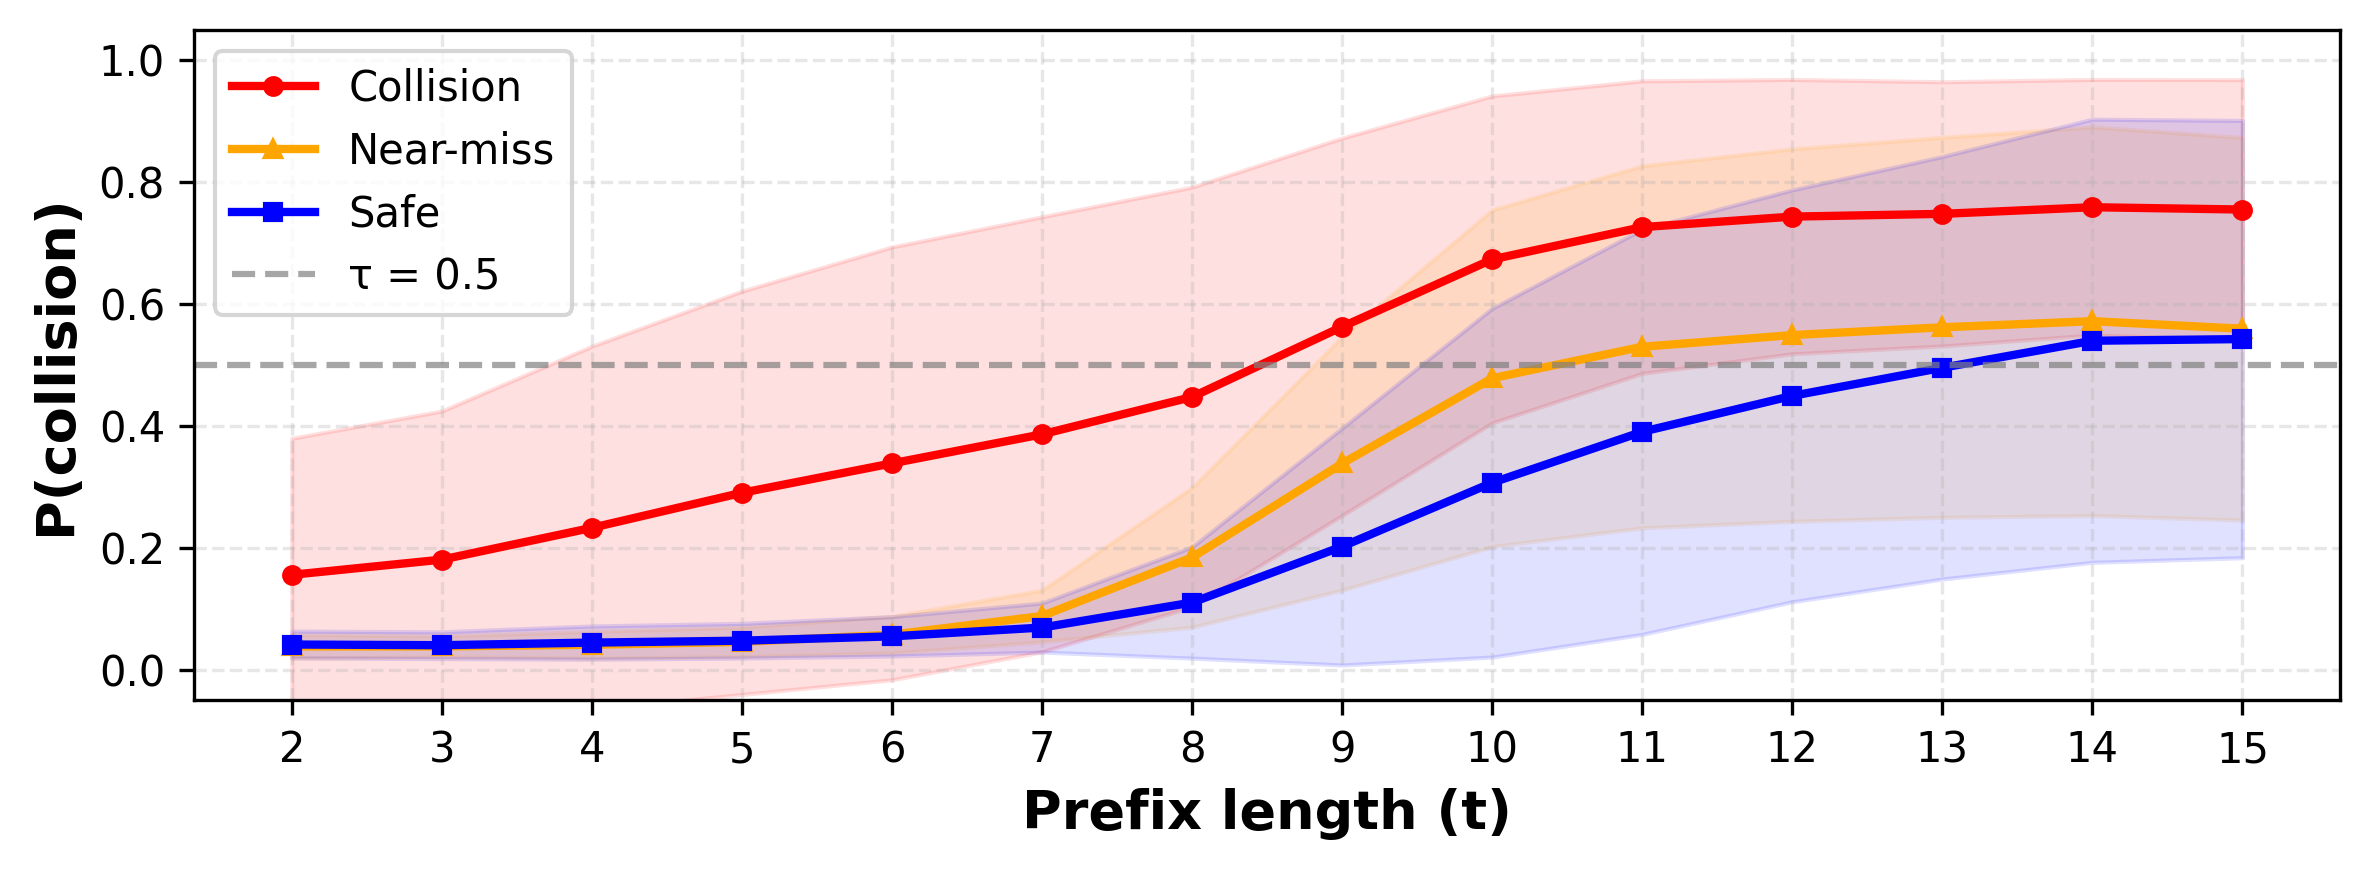

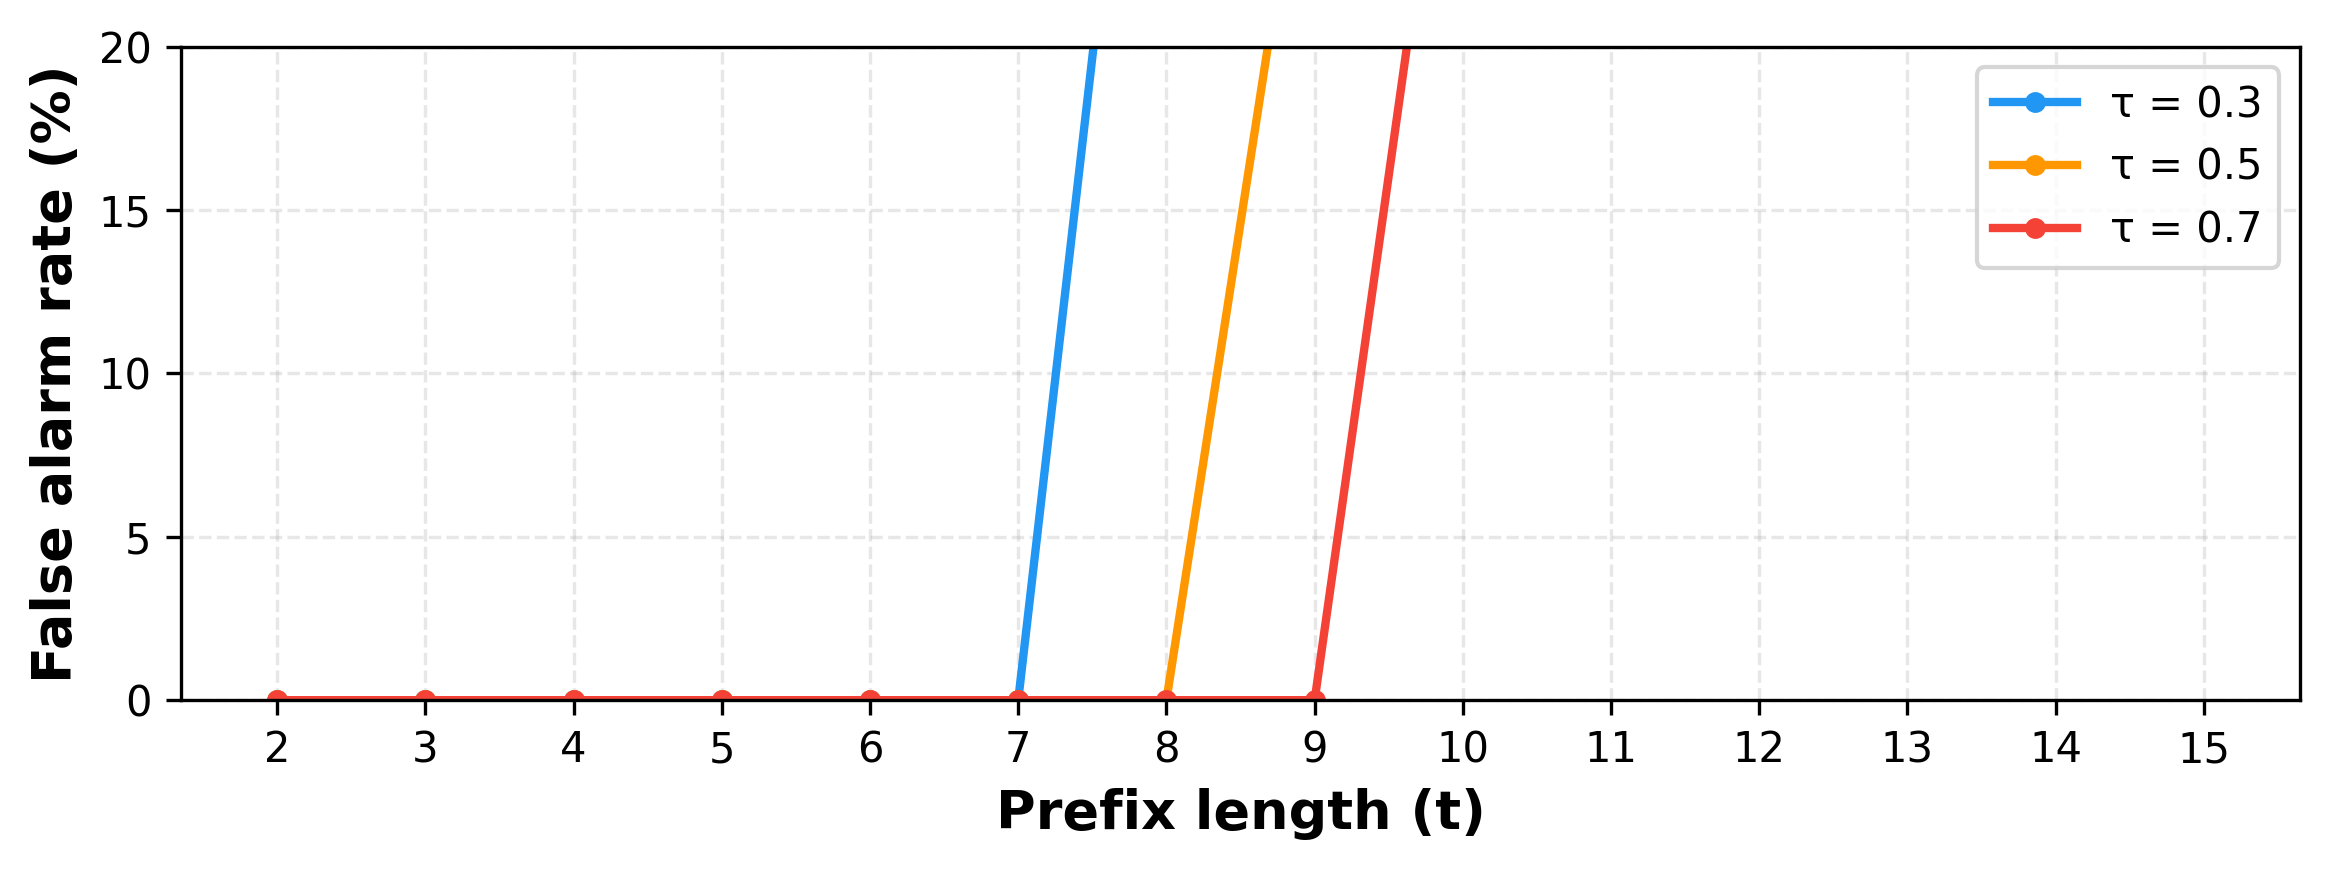


  NEAR-MISS FALSE ALARM PER PREFIX LENGTH (n=1037)
     t    Mean P     Std P    FA@0.3    FA@0.5    FA@0.7
  ──────────────────────────────────────────────────
     2     0.038     0.019      0.0%      0.0%      0.0%
     3     0.038     0.017      0.0%      0.0%      0.0%
     4     0.041     0.022      0.0%      0.0%      0.0%
     5     0.046     0.024      0.0%      0.0%      0.0%
     6     0.057     0.030      0.0%      0.0%      0.0%
     7     0.088     0.042      0.0%      0.0%      0.0%
     8     0.184     0.114     39.3%      0.0%      0.0%
     9     0.339     0.208     53.4%     29.2%      0.0%
    10     0.478     0.276     64.4%     54.3%     32.1%
    11     0.530     0.297     74.7%     59.9%     48.7%
    12     0.549     0.306     64.6%     53.4%     41.2%
    13     0.562     0.312     68.3%     53.4%     45.9%
    14     0.572     0.319     68.3%     57.1%     49.6%
    15     0.560     0.314     68.3%     57.1%     49.6%


In [18]:
# ============================================================
# NEAR-MISS FALSE ALARM ANALYSIS PER PREFIX LENGTH
# ============================================================

def compute_per_prefix_fa(clf_model, sequences, indices, device,
                          thresholds=[0.3, 0.5, 0.7], min_len=2):
    """Compute false alarm rate at each prefix length for a subset of sequences."""
    clf_model.eval()

    T = sequences[indices[0]].shape[0]
    prefix_lengths = list(range(min_len, T + 1))
    n_seqs = len(indices)

    # prob_matrix: (n_seqs, n_prefix_lengths)
    prob_matrix = np.zeros((n_seqs, len(prefix_lengths)))

    for seq_i, idx in enumerate(indices):
        seq = sequences[idx]
        X_full = torch.tensor(seq, dtype=torch.float32)

        for t_idx, t in enumerate(prefix_lengths):
            X_t = X_full[:t].unsqueeze(0).to(device)
            pad_mask = torch.zeros(1, t, dtype=torch.bool, device=device)
            with torch.no_grad():
                logits, _ = clf_model(X_t, pad_mask)
                prob = torch.sigmoid(logits).item()
            prob_matrix[seq_i, t_idx] = prob

    # Compute FA rate per prefix length
    fa_results = {}
    for tau in thresholds:
        fa_per_t = []
        for t_idx in range(len(prefix_lengths)):
            fa_count = (prob_matrix[:, t_idx] >= tau).sum()
            fa_per_t.append(fa_count / n_seqs * 100)
        fa_results[tau] = fa_per_t

    mean_probs = prob_matrix.mean(axis=0)
    std_probs = prob_matrix.std(axis=0)

    return prefix_lengths, prob_matrix, fa_results, mean_probs, std_probs


# --- Run for near-miss and safe subsets ---
print("Computing near-miss prefix analysis...")
pl_nm, pm_nm, fa_nm, mean_nm, std_nm = compute_per_prefix_fa(
    clf_model, sequences, near_miss_indices, device)

print("Computing safe prefix analysis...")
pl_safe, pm_safe, fa_safe, mean_safe, std_safe = compute_per_prefix_fa(
    clf_model, sequences, safe_indices, device)

# Also load collision data for comparison
collision_indices_val = [i for i in val_seq_indices if frame_labels[i].max() == 1]
print("Computing collision prefix analysis...")
pl_col, pm_col, _, mean_col, std_col = compute_per_prefix_fa(
    clf_model, sequences, collision_indices_val, device)


# ============================================================
# PLOT: Mean P(collision) per prefix — collision vs near-miss vs safe
# ============================================================
fig, ax = plt.subplots(figsize=(8, 3), dpi=300)

ax.plot(pl_col, mean_col, '-o', color='red', linewidth=2, markersize=4, label='Collision')
ax.fill_between(pl_col, mean_col - std_col, np.minimum(mean_col + std_col, 1.0),
                alpha=0.12, color='red')

ax.plot(pl_nm, mean_nm, '-^', color='orange', linewidth=2, markersize=4, label='Near-miss')
ax.fill_between(pl_nm, np.maximum(mean_nm - std_nm, 0), mean_nm + std_nm,
                alpha=0.12, color='orange')

ax.plot(pl_safe, mean_safe, '-s', color='blue', linewidth=2, markersize=4, label='Safe')
ax.fill_between(pl_safe, np.maximum(mean_safe - std_safe, 0), mean_safe + std_safe,
                alpha=0.12, color='blue')

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='τ = 0.5')

ax.set_xlabel("Prefix length (t)", fontsize=13, fontweight='bold')
ax.set_ylabel("P(collision)", fontsize=13, fontweight='bold')
ax.set_xticks(pl_nm)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# PLOT: FA rate per prefix length for near-miss sequences
# ============================================================
fig, ax = plt.subplots(figsize=(8, 3), dpi=300)

colors = ['#2196F3', '#FF9800', '#F44336']
for i, tau in enumerate([0.3, 0.5, 0.7]):
    ax.plot(pl_nm, fa_nm[tau], '-o', color=colors[i], linewidth=2,
            markersize=4, label=f'τ = {tau}')

ax.set_xlabel("Prefix length (t)", fontsize=13, fontweight='bold')
ax.set_ylabel("False alarm rate (%)", fontsize=13, fontweight='bold')
ax.set_xticks(pl_nm)
ax.set_ylim(0, 20)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# PRINT TABLE
# ============================================================
print(f"\n{'='*75}")
print(f"  NEAR-MISS FALSE ALARM PER PREFIX LENGTH (n={len(near_miss_indices)})")
print(f"{'='*75}")
print(f"  {'t':>4}  {'Mean P':>8}  {'Std P':>8}  {'FA@0.3':>8}  {'FA@0.5':>8}  {'FA@0.7':>8}")
print(f"  {'─'*50}")
for t_idx, t in enumerate(pl_nm):
    print(f"  {t:>4}  {mean_nm[t_idx]:>8.3f}  {std_nm[t_idx]:>8.3f}  "
          f"{fa_nm[0.3][t_idx]:>7.1f}%  {fa_nm[0.5][t_idx]:>7.1f}%  {fa_nm[0.7][t_idx]:>7.1f}%")

# 5-fold cross validation

In [19]:
# ============================================================
# 5-Fold CV at PREFIX level (same as 80/20 splitting approach)
# WARNING: This has temporal leakage — use only for comparison
# ============================================================

from sklearn.model_selection import KFold
import copy

clf_epochs       = 200
clf_lr           = 1e-4
clf_weight_decay = 1e-4
pos_prior        = 0.1
N_FOLDS          = 5

# Load ALL prefixes as one dataset (same as 80/20 code)
sup_ds_all = CurrentRiskPrefixDataset(TXT_PATH, min_len=2, max_len=None)
n_total = len(sup_ds_all)
print(f"Total prefixes: {n_total}")

# KFold on prefix indices
prefix_indices = np.arange(n_total)
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

pretrained_encoder_state = torch.load("pretrained_encoder_good.pt", map_location=device)

fold_best_f1 = []
fold_precisions = []
fold_recalls = []

for fold, (train_idx, val_idx) in enumerate(kf.split(prefix_indices), start=1):
    print(f"\n{'='*60}")
    print(f"  FOLD {fold}/{N_FOLDS}  |  {len(train_idx)} train / {len(val_idx)} val prefixes")
    print(f"{'='*60}")

    train_subset = torch.utils.data.Subset(sup_ds_all, train_idx.tolist())
    val_subset   = torch.utils.data.Subset(sup_ds_all, val_idx.tolist())

    train_loader_fold = DataLoader(train_subset, batch_size=32, shuffle=True,
                                   collate_fn=pad_collate_supervised)
    val_loader_fold   = DataLoader(val_subset, batch_size=64, shuffle=False,
                                   collate_fn=pad_collate_supervised)

    # Fresh model with pretrained encoder
    encoder_fold = TemporalEncoder(
        input_dim=5, d_model=64, nhead=4, num_layers=2,
        dim_feedforward=128, dropout=0.1, max_len=500
    )
    encoder_fold.load_state_dict(pretrained_encoder_state)
    clf_model_fold = TemporalRiskTransformer(encoder_fold).to(device)

    optimizer_fold = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, clf_model_fold.parameters()),
        lr=clf_lr, weight_decay=clf_weight_decay
    )
    early_stopper = EarlyStopping(patience=8, min_delta=1e-3, mode="max")

    for epoch in range(1, clf_epochs + 1):
        clf_model_fold.train()
        epoch_loss = 0.0
        for X, y, pad_mask in train_loader_fold:
            X, y, pad_mask = X.to(device), y.to(device), pad_mask.to(device)
            logits, _ = clf_model_fold(X, pad_mask=pad_mask)
            loss = nnpu_loss(logits, y, prior=pos_prior)
            optimizer_fold.zero_grad()
            loss.backward()
            optimizer_fold.step()
            epoch_loss += loss.item()

        acc, auc, recall, f1 = evaluate_classifier(clf_model_fold, val_loader_fold)
        if epoch % 10 == 0:
            print(f"    Epoch {epoch}: F1={f1:.4f}")

        if early_stopper.step(f1, clf_model_fold):
            print(f"    Early stopping at epoch {epoch}, best F1={early_stopper.best:.4f}")
            break

    early_stopper.restore_best_weights(clf_model_fold)

    # Final evaluation
    clf_model_fold.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X, y, pad_mask in val_loader_fold:
            X, pad_mask = X.to(device), pad_mask.to(device)
            logits, _ = clf_model_fold(X, pad_mask=pad_mask)
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(y.numpy())

    y_true = np.concatenate(all_labels).astype(int)
    y_pred = (np.concatenate(all_probs) >= 0.5).astype(int)

    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1_val = f1_score(y_true, y_pred, zero_division=0)

    fold_precisions.append(p)
    fold_recalls.append(r)
    fold_best_f1.append(f1_val)

    print(f"  Fold {fold}: P={p:.4f}, R={r:.4f}, F1={f1_val:.4f}")

print(f"\n{'='*60}")
print(f"  PREFIX-LEVEL 5-FOLD CV RESULTS")
print(f"{'='*60}")
print(f"  Mean Precision: {np.mean(fold_precisions):.4f} ± {np.std(fold_precisions):.4f}")
print(f"  Mean Recall:    {np.mean(fold_recalls):.4f} ± {np.std(fold_recalls):.4f}")
print(f"  Mean F1:        {np.mean(fold_best_f1):.4f} ± {np.std(fold_best_f1):.4f}")
print(f"  Per-fold F1:    {[f'{v:.4f}' for v in fold_best_f1]}")

Total prefixes: 13734

  FOLD 1/5  |  10987 train / 2747 val prefixes


C:\Users\l_daryel\AppData\Local\Temp\ipykernel_15552\2735560527.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pretrained_encoder_state = torch.load("pretrained_encode

    Epoch 10: F1=0.8686
    Epoch 20: F1=0.9029
    Early stopping at epoch 29, best F1=0.9180
  Fold 1: P=0.9390, R=0.8980, F1=0.9180

  FOLD 2/5  |  10987 train / 2747 val prefixes


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


    Epoch 10: F1=0.8234
    Epoch 20: F1=0.8784
    Early stopping at epoch 22, best F1=0.8979
  Fold 2: P=0.9454, R=0.8549, F1=0.8979

  FOLD 3/5  |  10987 train / 2747 val prefixes


...

    Epoch 10: F1=0.8172
    Epoch 20: F1=0.8963
    Epoch 30: F1=0.9062
    Early stopping at epoch 38, best F1=0.9062
  Fold 3: P=0.9230, R=0.8900, F1=0.9062

  FOLD 4/5  |  10987 train / 2747 val prefixes


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


    Epoch 10: F1=0.8485
    Epoch 20: F1=0.8790
    Epoch 30: F1=0.8879
    Epoch 40: F1=0.8838
    Early stopping at epoch 40, best F1=0.9126
  Fold 4: P=0.9516, R=0.8767, F1=0.9126

  FOLD 5/5  |  10988 train / 2746 val prefixes


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


    Epoch 10: F1=0.8833
    Early stopping at epoch 16, best F1=0.8850
  Fold 5: P=0.9360, R=0.8393, F1=0.8850

  PREFIX-LEVEL 5-FOLD CV RESULTS
  Mean Precision: 0.9390 ± 0.0097
  Mean Recall:    0.8718 ± 0.0218
  Mean F1:        0.9040 ± 0.0116
  Per-fold F1:    ['0.9180', '0.8979', '0.9062', '0.9126', '0.8850']


### Test different priors

In [77]:
from sklearn.decomposition import PCA
from sklearn.metrics import precision_recall_fscore_support, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt


priors_to_test = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

# Storage for results
prior_results = {}
prior_latents = {}  # stores (Z, y_labels) for each prior
prior_models = {}   # stores the best model state for each prior

for prior in priors_to_test:
    print(f"\n{'='*60}")
    print(f"  Training Stage 2 with π_p = {prior}")
    print(f"{'='*60}")

    # --- Fresh model with pretrained encoder ---
    encoder = TemporalEncoder(
    input_dim=5, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1, max_len=500,)

    # Load Stage 1 weights into it
    encoder.load_state_dict(torch.load("pretrained_encoder.pt"))

    # Create the classifier using this encoder
    clf_model = TemporalRiskTransformer(encoder=encoder).to(device)

    # --- Optimizer (fresh for each run) ---
    clf_optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, clf_model.parameters()),
        lr=1e-4,
        weight_decay=1e-4,
    )

    # --- Early stopping (fresh for each run) ---
    early_stopper = EarlyStopping(patience=8, min_delta=1e-3, mode="max")
    clf_epochs = 200
    best_epoch = None

    # --- Training loop ---
    for epoch in range(1, clf_epochs + 1):
        clf_model.train()
        epoch_loss = 0.0

        for X, y, pad_mask in train_loader:
            X = X.to(device)
            y = y.to(device)
            pad_mask = pad_mask.to(device)

            logits, _ = clf_model(X, pad_mask=pad_mask)
            loss = upu_loss(logits, y, prior=prior, gamma=1.0, beta=0.0)

            clf_optimizer.zero_grad()
            loss.backward()
            clf_optimizer.step()

            epoch_loss += loss.item()

        mean_train_loss = epoch_loss / len(train_loader)

        # Validation
        if val_loader is not None:
            acc, auc, recall, f1 = evaluate_classifier(clf_model, val_loader)

            if epoch % 5 == 0 or epoch == 1:
                print(
                    f"  [π_p={prior}] Epoch {epoch}/{clf_epochs} - "
                    f"Loss: {mean_train_loss:.4f} - "
                    f"Val F1: {f1:.4f}, Recall: {recall:.4f}"
                )

            should_stop = early_stopper.step(f1, clf_model)
            if f1 == early_stopper.best:
                best_epoch = epoch

            if should_stop:
                print(f"  Early stopping at epoch {epoch}. Best epoch: {best_epoch}")
                break

    # --- Restore best weights ---
    early_stopper.restore_best_weights(clf_model)

    # --- Final evaluation ---
    clf_model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for X, y, pad_mask in val_loader:
            X = X.to(device)
            y = y.to(device)
            pad_mask = pad_mask.to(device)
            logits, _ = clf_model(X, pad_mask=pad_mask)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(y.cpu().numpy())

    y_true = np.concatenate(all_labels).astype(int)
    y_prob = np.concatenate(all_probs)
    y_pred = (y_prob >= 0.5).astype(int)

    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1_val = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n  π_p={prior} FINAL: Precision={p:.4f}, Recall={r:.4f}, F1={f1_val:.4f}")

    # --- Store results ---
    prior_results[prior] = {"precision": p, "recall": r, "f1": f1_val, "best_epoch": best_epoch}

    # --- Extract and store latent representations ---
    Z_list = []
    y_list = []

    with torch.no_grad():
        for X, y, pad_mask in val_loader:
            X = X.to(device)
            pad_mask = pad_mask.to(device)
            _, z_seq = clf_model(X, pad_mask=pad_mask)
            Z_list.append(z_seq.cpu().numpy())
            y_list.append(y.numpy())

    Z_all = np.vstack(Z_list)
    y_all = np.concatenate(y_list)

    prior_latents[prior] = {"Z": Z_all, "y": y_all}
    prior_models[prior] = copy.deepcopy(clf_model.state_dict())

# ============================================================
# 3. Print summary table
# ============================================================
print(f"\n{'='*60}")
print(f"  PRIOR SENSITIVITY SUMMARY")
print(f"{'='*60}")
print(f"  {'π_p':>6}  {'Precision':>10}  {'Recall':>8}  {'F1':>8}  {'Best Ep':>8}")
print(f"  {'-'*50}")
for prior in priors_to_test:
    r = prior_results[prior]
    print(f"  {prior:>6.2f}  {r['precision']:>10.4f}  {r['recall']:>8.4f}  {r['f1']:>8.4f}  {r['best_epoch']:>8}")


  Training Stage 2 with π_p = 0.05


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
C:\Users\l_daryel\AppData\Local\Temp\ipykernel_34012\2992345795.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend 

  [π_p=0.05] Epoch 1/200 - Loss: 0.2492 - Val F1: 0.0000, Recall: 0.0000
  [π_p=0.05] Epoch 5/200 - Loss: 0.0794 - Val F1: 0.7074, Recall: 0.5697
  [π_p=0.05] Epoch 10/200 - Loss: -0.9510 - Val F1: 0.6160, Recall: 0.4485
  [π_p=0.05] Epoch 15/200 - Loss: -8.0805 - Val F1: 0.8054, Recall: 0.6803
  Early stopping at epoch 17. Best epoch: 9

  π_p=0.05 FINAL: Precision=0.9160, Recall=0.8091, F1=0.8592

  Training Stage 2 with π_p = 0.1


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
C:\Users\l_daryel\AppData\Local\Temp\ipykernel_34012\2992345795.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend 

  [π_p=0.1] Epoch 1/200 - Loss: 0.3656 - Val F1: 0.0000, Recall: 0.0000
  [π_p=0.1] Epoch 5/200 - Loss: -0.3999 - Val F1: 0.7771, Recall: 0.6470
  [π_p=0.1] Epoch 10/200 - Loss: -13.4876 - Val F1: 0.8643, Recall: 0.7864
  [π_p=0.1] Epoch 15/200 - Loss: -50.1362 - Val F1: 0.8293, Recall: 0.7212
  [π_p=0.1] Epoch 20/200 - Loss: -127.9250 - Val F1: 0.8636, Recall: 0.7773
  [π_p=0.1] Epoch 25/200 - Loss: -265.3730 - Val F1: 0.8629, Recall: 0.7727
  Early stopping at epoch 26. Best epoch: 18

  π_p=0.1 FINAL: Precision=0.9601, Recall=0.8379, F1=0.8948

  Training Stage 2 with π_p = 0.15


...

  [π_p=0.2] Epoch 1/200 - Loss: 0.4828 - Val F1: 0.3054, Recall: 0.2152
  [π_p=0.2] Epoch 5/200 - Loss: -3.3812 - Val F1: 0.8315, Recall: 0.8152
  [π_p=0.2] Epoch 10/200 - Loss: -42.9526 - Val F1: 0.8688, Recall: 0.8576
  [π_p=0.2] Epoch 15/200 - Loss: -144.5113 - Val F1: 0.8326, Recall: 0.8591
  [π_p=0.2] Epoch 20/200 - Loss: -323.1340 - Val F1: 0.8882, Recall: 0.8424
  [π_p=0.2] Epoch 25/200 - Loss: -592.4424 - Val F1: 0.8912, Recall: 0.8939
  [π_p=0.2] Epoch 30/200 - Loss: -949.8900 - Val F1: 0.8903, Recall: 0.8424
  [π_p=0.2] Epoch 35/200 - Loss: -1431.4462 - Val F1: 0.8640, Recall: 0.8515
  Early stopping at epoch 35. Best epoch: 27

  π_p=0.2 FINAL: Precision=0.9440, Recall=0.8682, F1=0.9045

  Training Stage 2 with π_p = 0.25


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
C:\Users\l_daryel\AppData\Local\Temp\ipykernel_34012\2992345795.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend 

  [π_p=0.25] Epoch 1/200 - Loss: 0.5160 - Val F1: 0.4507, Recall: 0.4500
  [π_p=0.25] Epoch 5/200 - Loss: -7.7978 - Val F1: 0.8308, Recall: 0.9152
  [π_p=0.25] Epoch 10/200 - Loss: -83.0942 - Val F1: 0.8641, Recall: 0.9152
  [π_p=0.25] Epoch 15/200 - Loss: -260.1735 - Val F1: 0.8809, Recall: 0.8682
  [π_p=0.25] Epoch 20/200 - Loss: -567.3217 - Val F1: 0.8731, Recall: 0.8652
  [π_p=0.25] Epoch 25/200 - Loss: -987.6290 - Val F1: 0.9065, Recall: 0.8591
  [π_p=0.25] Epoch 30/200 - Loss: -1645.4643 - Val F1: 0.9233, Recall: 0.9030
  [π_p=0.25] Epoch 35/200 - Loss: -2317.3820 - Val F1: 0.9002, Recall: 0.8545
  Early stopping at epoch 38. Best epoch: 30

  π_p=0.25 FINAL: Precision=0.9445, Recall=0.9030, F1=0.9233

  Training Stage 2 with π_p = 0.3


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
C:\Users\l_daryel\AppData\Local\Temp\ipykernel_34012\2992345795.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend 

  [π_p=0.3] Epoch 1/200 - Loss: 0.5620 - Val F1: 0.5348, Recall: 0.8439
  [π_p=0.3] Epoch 5/200 - Loss: -15.4352 - Val F1: 0.7875, Recall: 0.8788
  [π_p=0.3] Epoch 10/200 - Loss: -140.7398 - Val F1: 0.8393, Recall: 0.7833
  [π_p=0.3] Epoch 15/200 - Loss: -441.2356 - Val F1: 0.8535, Recall: 0.8697
  [π_p=0.3] Epoch 20/200 - Loss: -944.3560 - Val F1: 0.8681, Recall: 0.8924
  [π_p=0.3] Epoch 25/200 - Loss: -1639.7397 - Val F1: 0.8366, Recall: 0.9000
  Early stopping at epoch 25. Best epoch: 17

  π_p=0.3 FINAL: Precision=0.9116, Recall=0.9061, F1=0.9088

  PRIOR SENSITIVITY SUMMARY
     π_p   Precision    Recall        F1   Best Ep
  --------------------------------------------------
    0.05      0.9160    0.8091    0.8592         9
    0.10      0.9601    0.8379    0.8948        18
    0.15      0.9313    0.8424    0.8846        13
    0.20      0.9440    0.8682    0.9045        27
    0.25      0.9445    0.9030    0.9233        30
    0.30      0.9116    0.9061    0.9088        17


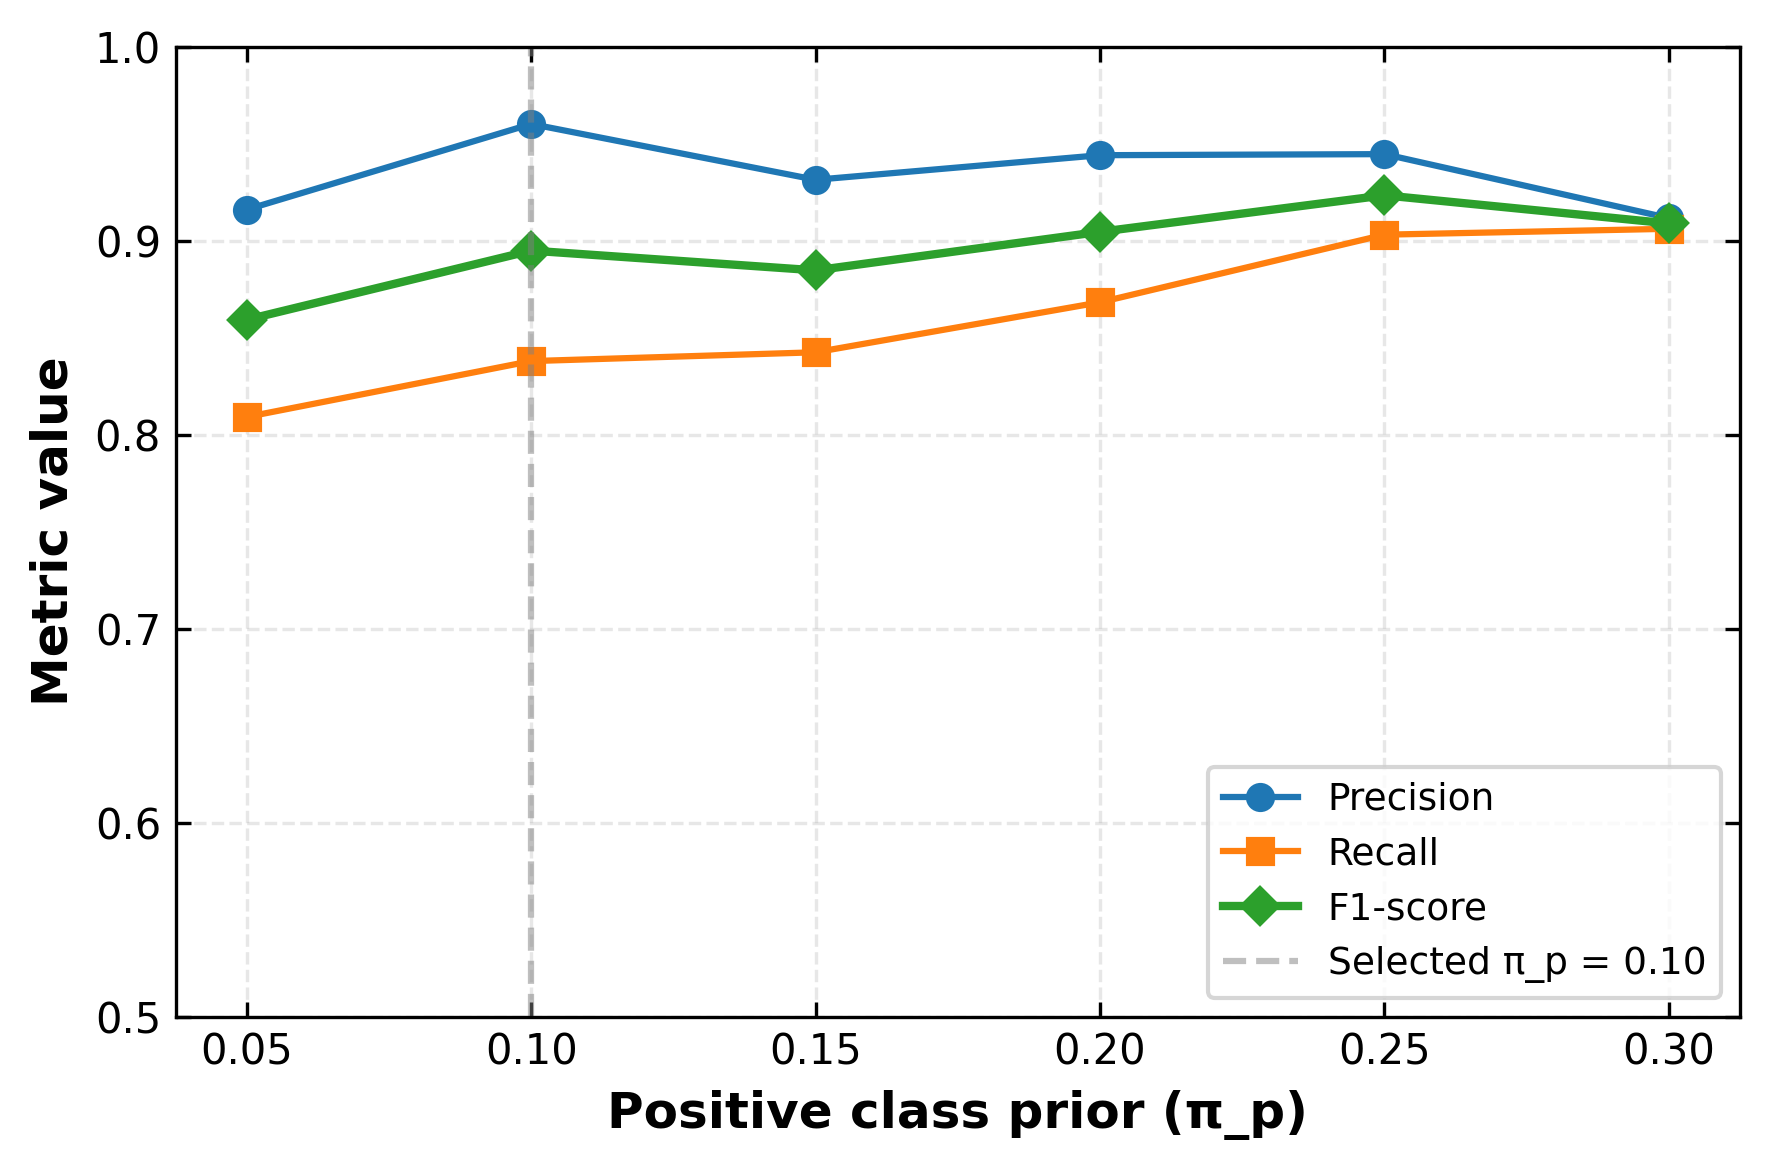

C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


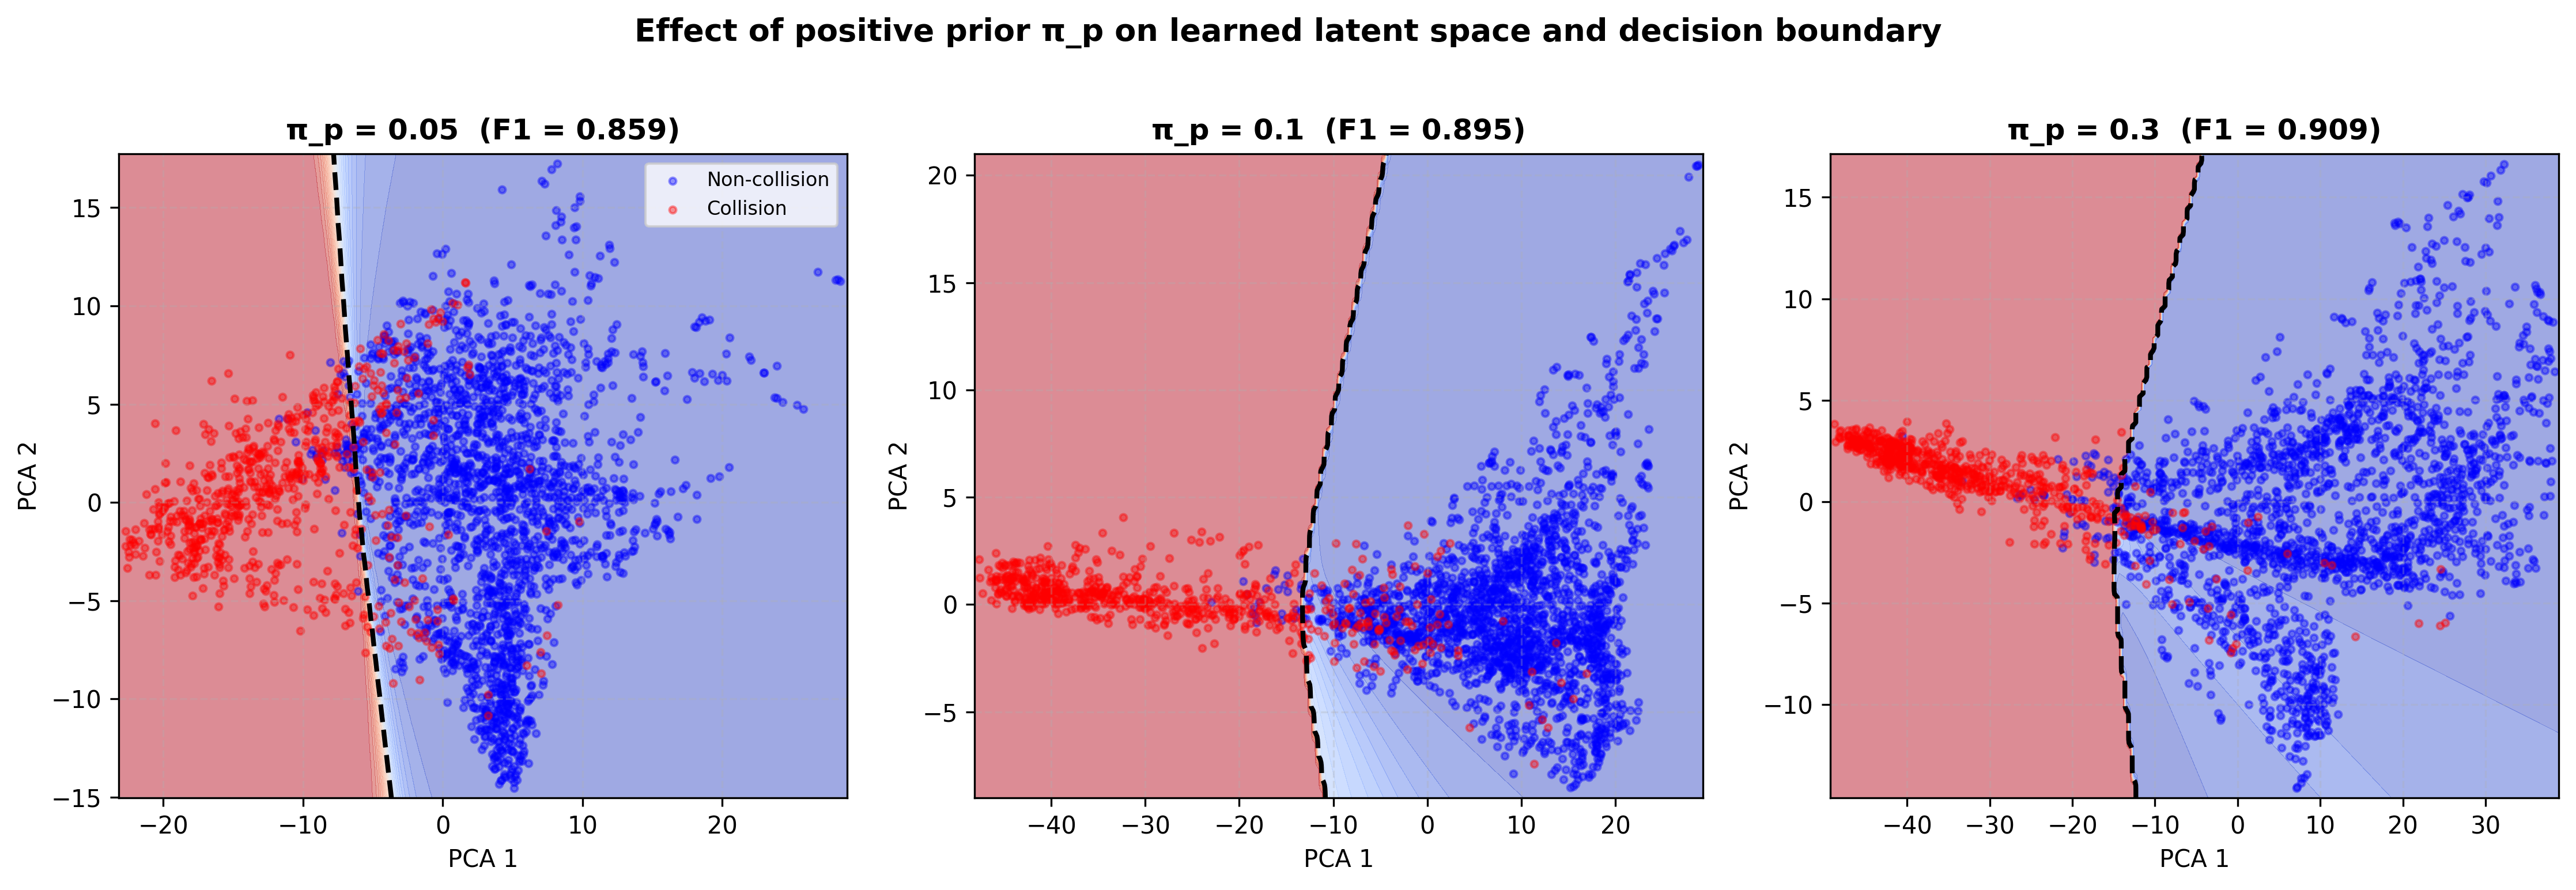

In [78]:
# ============================================================
# 4. Plot metrics vs prior
# ============================================================
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

priors = list(prior_results.keys())
precisions = [prior_results[p]["precision"] for p in priors]
recalls = [prior_results[p]["recall"] for p in priors]
f1s = [prior_results[p]["f1"] for p in priors]

ax.plot(priors, precisions, "-o", label="Precision", markersize=6)
ax.plot(priors, recalls, "-s", label="Recall", markersize=6)
ax.plot(priors, f1s, "-D", label="F1-score", markersize=6, linewidth=2)

ax.axvline(x=0.10, color="gray", linestyle="--", alpha=0.5, label="Selected π_p = 0.10")
ax.set_xlabel("Positive class prior (π_p)", fontsize=12, fontweight="bold")
ax.set_ylabel("Metric value", fontsize=12, fontweight="bold")
ax.set_ylim(0.5, 1.0)
ax.set_xticks(priors)
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.3)
ax.tick_params(direction="in", top=True, right=True)
plt.tight_layout()
plt.show()

# ============================================================
# 5. Latent space comparison (3 representative priors)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=300)

representative_priors = [0.05, 0.10, 0.3]

for idx, prior in enumerate(representative_priors):
    ax = axes[idx]
    Z = prior_latents[prior]["Z"]
    y = prior_latents[prior]["y"]

    # Fit PCA on this prior's latent space
    pca_temp = PCA(n_components=2)
    Z_2d = pca_temp.fit_transform(Z)

    # Build decision surface using this prior's model
    pad = 0.5
    x_min, x_max = Z_2d[:, 0].min() - pad, Z_2d[:, 0].max() + pad
    y_min, y_max = Z_2d[:, 1].min() - pad, Z_2d[:, 1].max() + pad

    nx, ny = 200, 200
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, nx),
        np.linspace(y_min, y_max, ny)
    )
    grid_2d = np.c_[xx.ravel(), yy.ravel()]
    grid_Z = pca_temp.inverse_transform(grid_2d)

    # Load the model for this prior and evaluate the head
    encoder_temp = TemporalEncoder(
        input_dim=5, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1, max_len=500,)
    clf_temp = TemporalRiskTransformer(encoder_temp).to(device)
    clf_temp.load_state_dict(prior_models[prior])
    clf_temp.eval()

    with torch.no_grad():
        z_t = torch.tensor(grid_Z, dtype=torch.float32, device=device)
        logits_grid = clf_temp.head(z_t).squeeze(-1)
        prob_grid = torch.sigmoid(logits_grid).cpu().numpy()

    prob_grid = prob_grid.reshape(xx.shape)

    # Plot
    cs = ax.contourf(xx, yy, prob_grid, levels=30, cmap="coolwarm", alpha=0.5)
    ax.contour(xx, yy, prob_grid, levels=[0.5], linewidths=2,
               linestyles="dashed", colors="black")

    ax.scatter(Z_2d[y == 0, 0], Z_2d[y == 0, 1],
               s=8, alpha=0.4, c="blue", label="Non-collision")
    ax.scatter(Z_2d[y == 1, 0], Z_2d[y == 1, 1],
               s=8, alpha=0.4, c="red", label="Collision")

    f1_val = prior_results[prior]["f1"]
    ax.set_title(f"π_p = {prior}  (F1 = {f1_val:.3f})", fontsize=12, fontweight="bold")
    ax.set_xlabel("PCA 1", fontsize=10)
    ax.set_ylabel("PCA 2", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.3)

    if idx == 0:
        ax.legend(fontsize=8, loc="best")

fig.suptitle("Effect of positive prior π_p on learned latent space and decision boundary",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### finish test

In [208]:
sum=0
print(f"Total data: {len(sup_ds)}")
for i in range(len(sup_ds)):
    if sup_ds[i][1] == 1:
        sum+=1
print(f"Total labeled: {sum}")
print(f"Percentage: {sum/len(sup_ds):.3f}")

Total data: 13734
Total labeled: 3377
Percentage: 0.246


## Optional: Latent Extraction and Visualization (Template)

In [209]:
# This cell provides a template to extract latent representations (z_seq) for analysis.
# You can extend it to do PCA / t-SNE visualization as in your previous notebook.

def extract_latents(model, dataset, max_batches: int = None):
    """Extract pooled latent vectors and labels from the supervised dataset.

    Returns:
        Z: (N, d_model) latent vectors
        labels: (N,) labels in {0,1}
    """
    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=False,
        collate_fn=pad_collate_supervised,
    )
    model.eval()
    latents = []
    labels = []
    seqs = []
    logi = []
    with torch.no_grad():
        for i, (X, y, pad_mask) in enumerate(loader):
            X = X.to(device)
            pad_mask = pad_mask.to(device)
            logits, z_seq = model(X, pad_mask=pad_mask)
            latents.append(z_seq.cpu().numpy())
            labels.append(y.numpy())
            logi.append(torch.sigmoid(logits).cpu().numpy())

            if max_batches is not None and (i + 1) >= max_batches:
                break

    Z = np.vstack(latents)
    labels = np.concatenate(labels)
    logi = np.concatenate(logi)
    return Z, labels, logi

# Example usage (uncomment after training):
# if sup_ds is not None:
#     Z, y_lat = extract_latents(clf_model, sup_ds, max_batches=50)
#     print("Latent shape:", Z.shape)


In [35]:
sup_ds = CurrentRiskPrefixDataset(TXT_PATH, min_len=2, max_len=None)
print(f"Supervised prefix dataset size: {len(sup_ds)} samples")
torch.manual_seed(42)
# Train/validation split
n_total = len(sup_ds)
n_train = int(0.8 * n_total)
n_val = n_total - n_train
train_ds, val_ds = random_split(sup_ds, [n_train, n_val])
flip_pct = 0.1   # 10% label flipping
flip_seed = 123
train_ds = LabelFlipWrapper(train_ds, flip_pct=flip_pct, seed=flip_seed)

Supervised prefix dataset size: 13734 samples


In [210]:
# Example usage (uncomment after training):
print(len(train_ds[0][0]))
if sup_ds is not None:
     Z_train, y_lat_train, logi = extract_latents(clf_model, train_ds, max_batches=None)
     Z_val, y_lat_val, logi = extract_latents(clf_model, val_ds, max_batches=None)
     print("Latent shape:", len(Z_train))

10
Latent shape: 10987


In [39]:
n=22

print(y_lat_train[n])
print(logi[n])

0.0
0.24932449


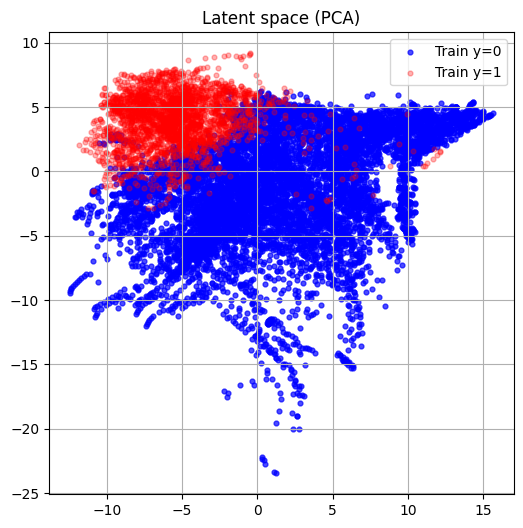

In [211]:
Z_train = np.vstack(Z_train)
y_train = np.array(y_lat_train)

Z_eval = np.vstack(Z_val)
y_eval = np.array(y_lat_val)


pca = PCA(n_components=2, random_state=42)
Z2_train = pca.fit_transform(Z_train)   # fit on train
Z2_eval  = pca.transform(Z_eval)        # project eval into same space

plt.figure(figsize=(6,6))

# train points (contaminated)
plt.scatter(Z2_train[y_train==0, 0], Z2_train[y_train==0, 1], s=12, alpha=0.7, label="Train y=0", marker="o",c="blue")
plt.scatter(Z2_train[y_train==1, 0], Z2_train[y_train==1, 1], s=12, alpha=0.3, label="Train y=1", marker="o",c="red")

# eval points
#plt.scatter(Z2_eval[y_eval==0, 0], Z2_eval[y_eval==0, 1], s=30, alpha=0.9, label="Eval y=0", marker="x")
#plt.scatter(Z2_eval[y_eval==1, 0], Z2_eval[y_eval==1, 1], s=30, alpha=0.9, label="Eval y=1", marker="x")

plt.title("Latent space (PCA)")
plt.legend()
plt.grid(True)
plt.show()

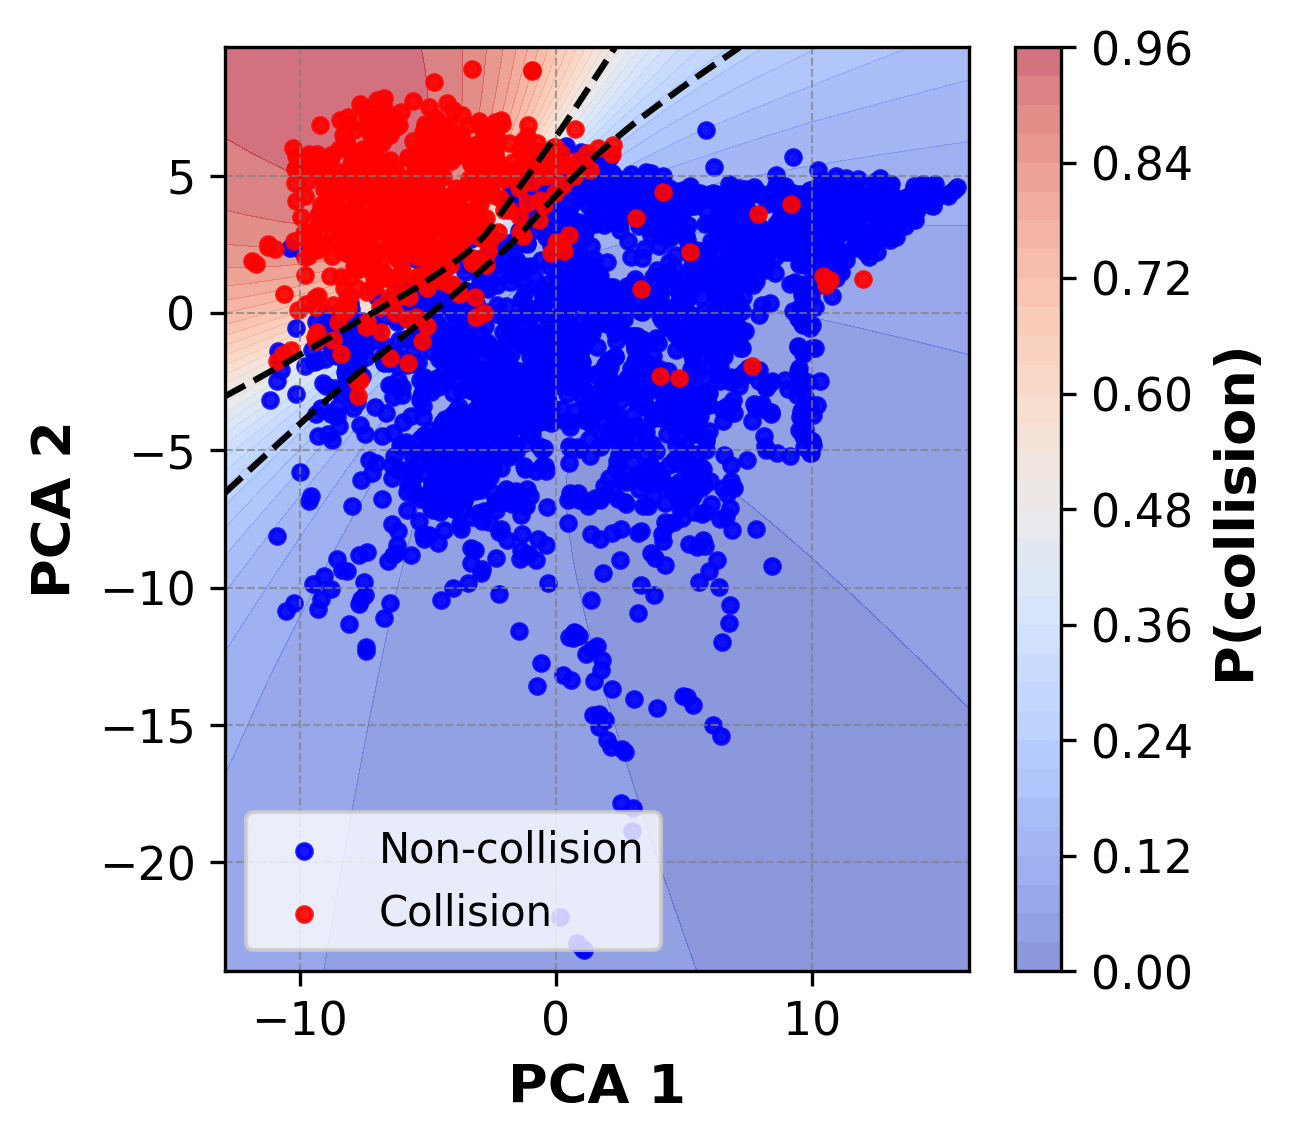

In [212]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch

# 1) PCA to 2D
pca = PCA(n_components=2)
Z2 = pca.fit_transform(Z_train)          # (N,2)

# 2) Build a grid in PCA space
pad = 0.5
x_min, x_max = Z2[:, 0].min() - pad, Z2[:, 0].max() + pad
y_min, y_max = Z2[:, 1].min() - pad, Z2[:, 1].max() + pad

nx = 300
ny = 300
xx, yy = np.meshgrid(np.linspace(x_min, x_max, nx),
                     np.linspace(y_min, y_max, ny))
grid_2d = np.c_[xx.ravel(), yy.ravel()]  # (nx*ny, 2)

# 3) Map grid back to latent space (approx: points on PCA plane in d_model-dim)
grid_Z = pca.inverse_transform(grid_2d)  # (nx*ny, d_model)

# 4) Evaluate your learned classifier HEAD on those latent points
#    (This visualizes the decision function in the PCA plane.)
clf_model.eval()
with torch.no_grad():
    z_t = torch.tensor(grid_Z, dtype=torch.float32, device=device)
    logits_grid = clf_model.head(z_t).squeeze(-1)
    prob_grid = torch.sigmoid(logits_grid).detach().cpu().numpy()

prob_grid = prob_grid.reshape(xx.shape)

# 5) Plot decision surface + samples
plt.figure(figsize=(4, 4), dpi=300)
cs = plt.contourf(xx, yy, prob_grid, levels=30, cmap="coolwarm", alpha=0.6)
cbar = plt.colorbar(cs)
cbar.set_label("P(collision)", fontsize=13, fontweight="bold")

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Also for the colorbar ticks:
cbar.ax.tick_params(labelsize=11)

# Original boundary at p=0.5
plt.contour(xx, yy, prob_grid, levels=[0.5], linewidths=1.5, linestyles="dashed",colors="black")

# Near-collision boundary (shift threshold down, e.g. p=0.3)
plt.contour(xx, yy, prob_grid, levels=[0.26], linewidths=1.5, linestyles="dashed", colors="black")

# Optional: shade the band between the two thresholds
#plt.contourf(xx, yy, prob_grid, levels=[0.3, 0.5], colors=["orange"], alpha=0.15)
plt.grid(axis='y', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
plt.grid(axis='x', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)

# "Boundary" at p=0.5 (logit=0)
#plt.contour(xx, yy, prob_grid, levels=[0.5], linewidths=2)
#plt.scatter(Z2[:, 0], Z2[:, 1], c=y_train,cmap="coolwarm", s=12, alpha=0.9)
#plt.scatter(Z2_train[y_train==0, 0], Z2_train[y_train==0, 1], s=12, alpha=0.9, label="Train y=0",c="blue")
#plt.scatter(Z2_train[y_train==1, 0], Z2_train[y_train==1, 1], s=12, alpha=0.4, label="Train y=1",c="red")

plt.scatter(Z2_eval[y_eval==0, 0], Z2_eval[y_eval==0, 1], s=12, alpha=0.9, label="Non-collision",c="blue")
plt.scatter(Z2_eval[y_eval==1, 0], Z2_eval[y_eval==1, 1], s=12, alpha=0.9, label="Collision", c="red")

plt.xlabel("PCA 1", fontsize=13, fontweight="bold")
plt.ylabel("PCA 2", fontsize=13, fontweight="bold")
#plt.title("Latent space (PCA) with model decision surface (p=0.5 boundary)")
plt.grid(True)
plt.legend()
plt.show()

In [213]:
def compute_prefix_trajectory(X_seq, clf_model, pca, device):
    """
    Compute the latent space trajectory for all prefixes of a sequence.

    X_seq   : torch.Tensor of shape (T, 5) for one sequence
    clf_model: TemporalRiskTransformer with pretrained encoder
    pca     : fitted PCA (MUST be the same one used for the background scatter)
    device  : torch.device

    Returns:
        traj_2d: np.array of shape (T, 2) — PCA-projected latent for each prefix
        probs:   list of length T — P(collision) from the nnPU classifier
    """
    clf_model.eval()
    T = X_seq.shape[0]
    traj_2d = []
    probs = []

    for t in range(1, T + 1):
        # prefix of length t
        X_t = X_seq[:t].unsqueeze(0).to(device)   # (1, t, 5)
        pad_mask = torch.zeros(1, t, dtype=torch.bool, device=device)

        with torch.no_grad():
            logits, z_seq = clf_model(X_t, pad_mask)   # z_seq: (1, d_model)
            prob = torch.sigmoid(logits).item()

        probs.append(prob)
        z = z_seq.cpu().numpy()            # (1, d_model)
        z_2d = pca.transform(z)            # (1, 2)
        traj_2d.append(z_2d[0])            # append the (2,) vector

    return np.array(traj_2d), probs


def plot_prefix_trajectory_on_decision_surface(
    traj_2d, probs, clf_model, pca, Z_2d, y_lat, device, seq_idx=None
):
    """
    Plot a prefix trajectory on top of the nnPU classifier's decision surface.

    traj_2d  : (T, 2) from compute_prefix_trajectory
    probs    : list of T probabilities from the nnPU classifier
    clf_model: TemporalRiskTransformer (for the classification head)
    pca      : fitted PCA (same one used for traj_2d and Z_2d)
    Z_2d     : (N, 2) all samples projected to PCA space (for background scatter)
    y_lat    : (N,) labels for background scatter
    device   : torch.device
    seq_idx  : optional index for title
    """
    # --- Build decision surface from the nnPU classifier head ---
    pad = 0.5
    x_min, x_max = Z_2d[:, 0].min() - pad, Z_2d[:, 0].max() + pad
    y_min, y_max = Z_2d[:, 1].min() - pad, Z_2d[:, 1].max() + pad

    nx, ny = 300, 300
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, nx),
        np.linspace(y_min, y_max, ny)
    )
    grid_2d = np.c_[xx.ravel(), yy.ravel()]  # (nx*ny, 2)
    grid_Z = pca.inverse_transform(grid_2d)   # (nx*ny, d_model)

    clf_model.eval()
    with torch.no_grad():
        z_t = torch.tensor(grid_Z, dtype=torch.float32, device=device)
        logits_grid = clf_model.head(z_t).squeeze(-1)
        prob_grid = torch.sigmoid(logits_grid).cpu().numpy()

    prob_grid = prob_grid.reshape(xx.shape)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(6, 6), dpi=150)

    # Decision surface
    cs = ax.contourf(xx, yy, prob_grid, levels=30, cmap="coolwarm", alpha=0.5)
    cbar = fig.colorbar(cs, ax=ax)
    cbar.set_label("P(collision)", fontsize=12, fontweight="bold")

    # Decision boundary at p=0.5
    ax.contour(xx, yy, prob_grid, levels=[0.5], linewidths=2,
               linestyles="dashed", colors="black")

    # Background scatter (evaluation set)
    ax.scatter(Z_2d[y_lat == 0, 0], Z_2d[y_lat == 0, 1],
               s=12, alpha=0.4, c="blue", label="Non-collision")
    ax.scatter(Z_2d[y_lat == 1, 0], Z_2d[y_lat == 1, 1],
               s=12, alpha=0.4, c="red", label="Collision")

    # Trajectory path with color gradient (early=light, late=dark)
    T = len(traj_2d)
    for i in range(T - 1):
        alpha = 0.3 + 0.7 * (i / (T - 1))  # fade from light to dark
        ax.plot(traj_2d[i:i+2, 0], traj_2d[i:i+2, 1],
                '-', color='black', linewidth=2, alpha=alpha)

    # Mark each prefix point
    ax.scatter(traj_2d[:, 0], traj_2d[:, 1], c=range(T), cmap="Greys",
               s=30, zorder=5, edgecolors="black", linewidths=0.5)

    # Start and end markers
    ax.scatter(traj_2d[0, 0], traj_2d[0, 1], marker="s", s=100,
               c="green", edgecolors="black", linewidths=1.5,
               zorder=6, label=f"Start (t=1, P={probs[0]:.2f})")
    ax.scatter(traj_2d[-1, 0], traj_2d[-1, 1], marker="*", s=200,
               c="yellow", edgecolors="black", linewidths=1.5,
               zorder=6, label=f"End (t={T}, P={probs[-1]:.2f})")

    title = "Prefix trajectory in learned latent space"
    if seq_idx is not None:
        title += f" (seq {seq_idx})"
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("PCA 1", fontsize=12, fontweight="bold")
    ax.set_ylabel("PCA 2", fontsize=12, fontweight="bold")
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

Sequence 1441, true label: 1.0


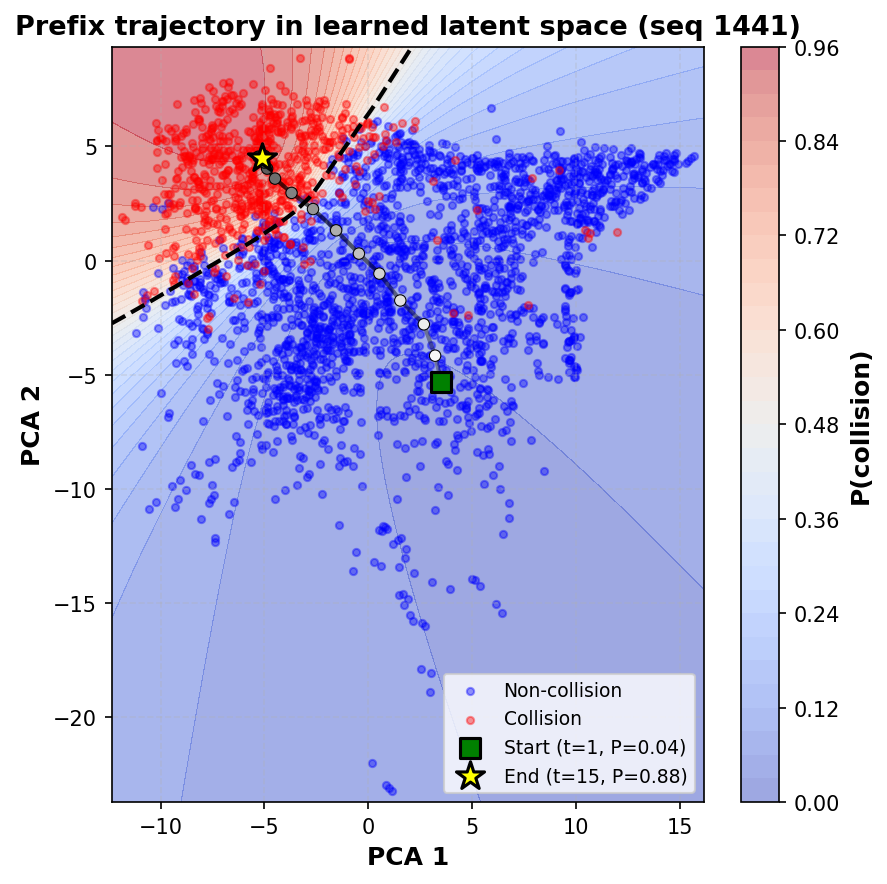

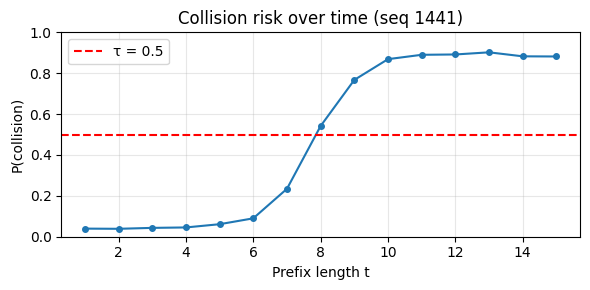

In [232]:
# Choose a collision sequence
seq_idx = 1875  # or whatever index you want
seq_idx = 1679  # Near-miss
seq_idx = 951  # Near-miss
seq_idx = 1203  # Non-collision
seq_idx = 1441  # COllision

X_seq, y_true = sup_ds[seq_idx]
print(f"Sequence {seq_idx}, true label: {y_true}")

# Compute trajectory
traj_2d, probs = compute_prefix_trajectory(X_seq, clf_model, pca, device)

# Plot on decision surface (uses nnPU classifier head, NOT SVM)
plot_prefix_trajectory_on_decision_surface(
    traj_2d, probs, clf_model, pca, Z2_eval, y_eval, device, seq_idx=seq_idx
)

# Also plot P(collision) over time
plt.figure(figsize=(6, 3))
plt.plot(range(1, len(probs) + 1), probs, "-o", markersize=4)
plt.axhline(y=0.5, color="red", linestyle="--", label="τ = 0.5")
plt.xlabel("Prefix length t")
plt.ylabel("P(collision)")
plt.title(f"Collision risk over time (seq {seq_idx})")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### TTA analisis

Found 660 collision sequences

τ = 0.3:
  Detected: 633/660 (95.9%)
  TTA: mean=0.696s, std=0.459s, median=0.676s, range=[0.000s, 1.757s]

τ = 0.4:
  Detected: 622/660 (94.2%)
  TTA: mean=0.660s, std=0.461s, median=0.541s, range=[0.000s, 1.757s]

τ = 0.5:
  Detected: 599/660 (90.8%)
  TTA: mean=0.627s, std=0.455s, median=0.541s, range=[0.000s, 1.757s]

τ = 0.6:
  Detected: 571/660 (86.5%)
  TTA: mean=0.595s, std=0.449s, median=0.541s, range=[0.000s, 1.757s]

τ = 0.7:
  Detected: 515/660 (78.0%)
  TTA: mean=0.561s, std=0.439s, median=0.541s, range=[0.000s, 1.757s]


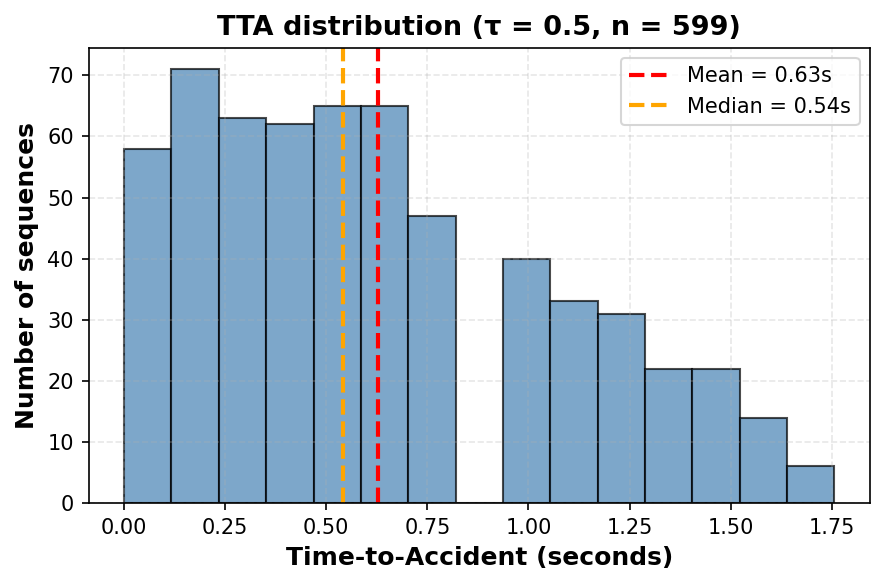

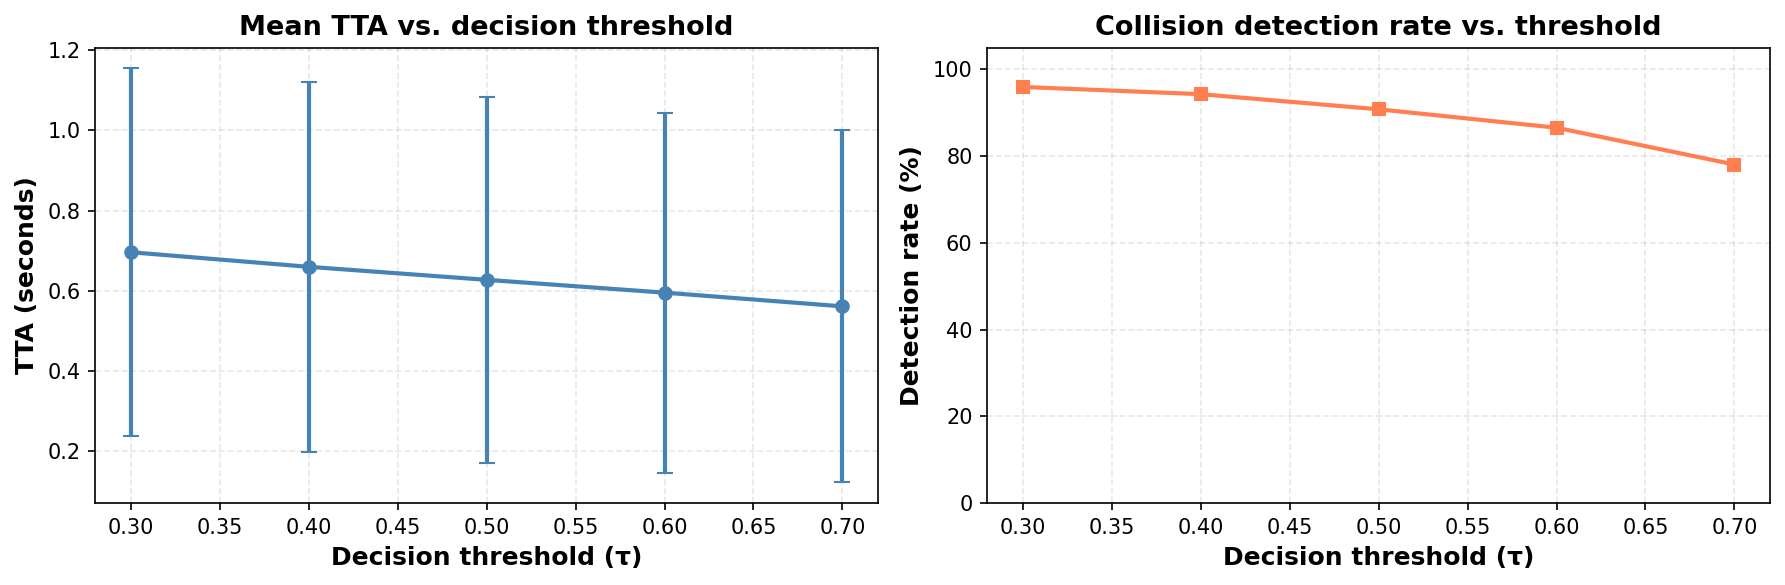


  TABLE FOR PAPER: TTA Analysis Across Decision Thresholds
      τ   Det. Rate    Mean TTA       Std    Median             Range
  --------------------------------------------------------------
    0.3       95.9%      0.696s    0.459    0.676  [0.000, 1.757]
    0.4       94.2%      0.660s    0.461    0.541  [0.000, 1.757]
    0.5       90.8%      0.627s    0.455    0.541  [0.000, 1.757]
    0.6       86.5%      0.595s    0.449    0.541  [0.000, 1.757]
    0.7       78.0%      0.561s    0.439    0.541  [0.000, 1.757]


In [233]:
def compute_tta_for_sequence(X_seq, clf_model, device, threshold=0.5, fps=7.4):
    """
    Compute TTA for a single collision sequence.

    X_seq: tensor of shape (T, 5) — full collision sequence
    Returns: TTA in seconds, or None if threshold never crossed
    """
    clf_model.eval()
    T = X_seq.shape[0]
    f_collision = T - 1  # last frame is the collision frame
    f_first = None

    for t in range(2, T + 1):  # prefixes of length 2, 3, ..., T
        X_t = X_seq[:t].unsqueeze(0).to(device)
        pad_mask = torch.zeros(1, t, dtype=torch.bool, device=device)

        with torch.no_grad():
            logits, _ = clf_model(X_t, pad_mask)
            prob = torch.sigmoid(logits).item()

        if prob >= threshold and f_first is None:
            f_first = t - 1  # frame index (0-based)

    if f_first is None:
        return None  # threshold never crossed — missed detection

    tta = (f_collision - f_first) / fps
    return tta


def tta_analysis(clf_model, dataset, device, thresholds=[0.3, 0.4, 0.5, 0.6, 0.7], fps=7.4):
    """
    Compute TTA distribution across all collision sequences for multiple thresholds.
    """
    # Collect all collision sequences
    collision_indices = []
    for i in range(len(dataset)):
        X, y = dataset[i]
        if isinstance(y, torch.Tensor):
            y = y.item()
        if y == 1:
            collision_indices.append(i)

    print(f"Found {len(collision_indices)} collision sequences")

    results = {}

    for tau in thresholds:
        ttas = []
        missed = 0

        for idx in collision_indices:
            X, y = dataset[idx]
            tta = compute_tta_for_sequence(X, clf_model, device, threshold=tau, fps=fps)

            if tta is not None:
                ttas.append(tta)
            else:
                missed += 1

        ttas = np.array(ttas)

        results[tau] = {
            'ttas': ttas,
            'mean': ttas.mean() if len(ttas) > 0 else 0,
            'std': ttas.std() if len(ttas) > 0 else 0,
            'median': np.median(ttas) if len(ttas) > 0 else 0,
            'min': ttas.min() if len(ttas) > 0 else 0,
            'max': ttas.max() if len(ttas) > 0 else 0,
            'missed': missed,
            'detected': len(ttas),
            'detection_rate': len(ttas) / (len(ttas) + missed)
        }

        print(f"\nτ = {tau}:")
        print(f"  Detected: {results[tau]['detected']}/{len(collision_indices)} "
              f"({results[tau]['detection_rate']*100:.1f}%)")
        print(f"  TTA: mean={results[tau]['mean']:.3f}s, "
              f"std={results[tau]['std']:.3f}s, "
              f"median={results[tau]['median']:.3f}s, "
              f"range=[{results[tau]['min']:.3f}s, {results[tau]['max']:.3f}s]")

    return results


# --- Run the analysis ---
results = tta_analysis(clf_model, val_ds, device)


# --- Plot 1: TTA distribution histogram for τ = 0.5 ---
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ttas_05 = results[0.5]['ttas']
ax.hist(ttas_05, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=results[0.5]['mean'], color='red', linestyle='--', linewidth=2,
           label=f"Mean = {results[0.5]['mean']:.2f}s")
ax.axvline(x=results[0.5]['median'], color='orange', linestyle='--', linewidth=2,
           label=f"Median = {results[0.5]['median']:.2f}s")
ax.set_xlabel("Time-to-Accident (seconds)", fontsize=12, fontweight='bold')
ax.set_ylabel("Number of sequences", fontsize=12, fontweight='bold')
ax.set_title(f"TTA distribution (τ = 0.5, n = {len(ttas_05)})", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


# --- Plot 2: TTA vs threshold ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

thresholds = sorted(results.keys())
means = [results[t]['mean'] for t in thresholds]
stds = [results[t]['std'] for t in thresholds]
det_rates = [results[t]['detection_rate'] * 100 for t in thresholds]

# TTA vs threshold
ax1.errorbar(thresholds, means, yerr=stds, fmt='-o', capsize=4,
             markersize=6, linewidth=2, color='steelblue')
ax1.set_xlabel("Decision threshold (τ)", fontsize=12, fontweight='bold')
ax1.set_ylabel("TTA (seconds)", fontsize=12, fontweight='bold')
ax1.set_title("Mean TTA vs. decision threshold", fontsize=13, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.3)

# Detection rate vs threshold
ax2.plot(thresholds, det_rates, '-s', markersize=6, linewidth=2, color='coral')
ax2.set_xlabel("Decision threshold (τ)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Detection rate (%)", fontsize=12, fontweight='bold')
ax2.set_title("Collision detection rate vs. threshold", fontsize=13, fontweight='bold')
ax2.set_ylim(0, 105)
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


# --- Print summary table for the paper ---
print(f"\n{'='*70}")
print(f"  TABLE FOR PAPER: TTA Analysis Across Decision Thresholds")
print(f"{'='*70}")
print(f"  {'τ':>5}  {'Det. Rate':>10}  {'Mean TTA':>10}  {'Std':>8}  {'Median':>8}  {'Range':>16}")
print(f"  {'-'*62}")
for tau in thresholds:
    r = results[tau]
    print(f"  {tau:>5.1f}  {r['detection_rate']*100:>9.1f}%  {r['mean']:>9.3f}s  "
          f"{r['std']:>7.3f}  {r['median']:>7.3f}  "
          f"[{r['min']:.3f}, {r['max']:.3f}]")

In [68]:
# ============================================================
# 1. Load full sequences with frame labels (NOT prefixes)
# ============================================================
raw_data = load_mix_txt(TXT_PATH)
sequences, frame_labels, seq_ids = group_sequences_with_frame_labels(raw_data)

# Identify collision sequences (any frame has label=1)
collision_indices = [i for i, fl in enumerate(frame_labels) if fl.max() == 1]
non_collision_indices = [i for i, fl in enumerate(frame_labels) if fl.max() == 0]

print(f"Total sequences: {len(sequences)}")
print(f"Collision sequences: {len(collision_indices)}")
print(f"Non-collision sequences: {len(non_collision_indices)}")

# ============================================================
# 2. Compute P(collision) for every prefix of every collision sequence
# ============================================================
def compute_all_prefix_probs(clf_model, sequences, indices, device, min_len=2):
    """
    For each sequence in indices, compute P(collision) at each prefix length.

    Returns:
        prob_matrix: (n_sequences, n_prefix_lengths)
        prefix_lengths: list of prefix lengths [2, 3, ..., T]
    """
    clf_model.eval()

    all_probs = []
    all_seq_lengths = []

    for idx in indices:
        seq = sequences[idx]
        T = len(seq)
        all_seq_lengths.append(T)
        X_full = torch.tensor(seq, dtype=torch.float32)

        probs_for_seq = []

        for t in range(min_len, T + 1):
            X_t = X_full[:t].unsqueeze(0).to(device)  # (1, t, 5)
            pad_mask = torch.zeros(1, t, dtype=torch.bool, device=device)

            with torch.no_grad():
                logits, _ = clf_model(X_t, pad_mask)
                prob = torch.sigmoid(logits).item()

            probs_for_seq.append(prob)

        all_probs.append(probs_for_seq)

    # All sequences should have same T, but handle variable length just in case
    max_prefixes = max(len(p) for p in all_probs)
    prefix_lengths = list(range(min_len, min_len + max_prefixes))

    # Pad with NaN for any shorter sequences
    prob_matrix = np.full((len(indices), max_prefixes), np.nan)
    for i, probs in enumerate(all_probs):
        prob_matrix[i, :len(probs)] = probs

    return prob_matrix, prefix_lengths


# ============================================================
# 3. Cumulative detection rate per prefix length
# ============================================================
def compute_detection_rates(prob_matrix, prefix_lengths,
                            thresholds=[0.3, 0.4, 0.5, 0.6, 0.7]):
    n_seqs = prob_matrix.shape[0]
    results = {}

    for tau in thresholds:
        cumulative_detected = np.zeros(len(prefix_lengths))

        for t_idx in range(len(prefix_lengths)):
            # max prob up to this prefix length (ignoring NaN)
            max_prob = np.nanmax(prob_matrix[:, :t_idx+1], axis=1)
            cumulative_detected[t_idx] = np.sum(max_prob >= tau)

        results[tau] = cumulative_detected / n_seqs * 100

    return results

Total sequences: 981
Collision sequences: 371
Non-collision sequences: 610


Total prefixes: 13734
Should match sup_ds: 13734
Val sequences (unique): 930
Val collision sequences: 346
Val non-collision sequences: 584


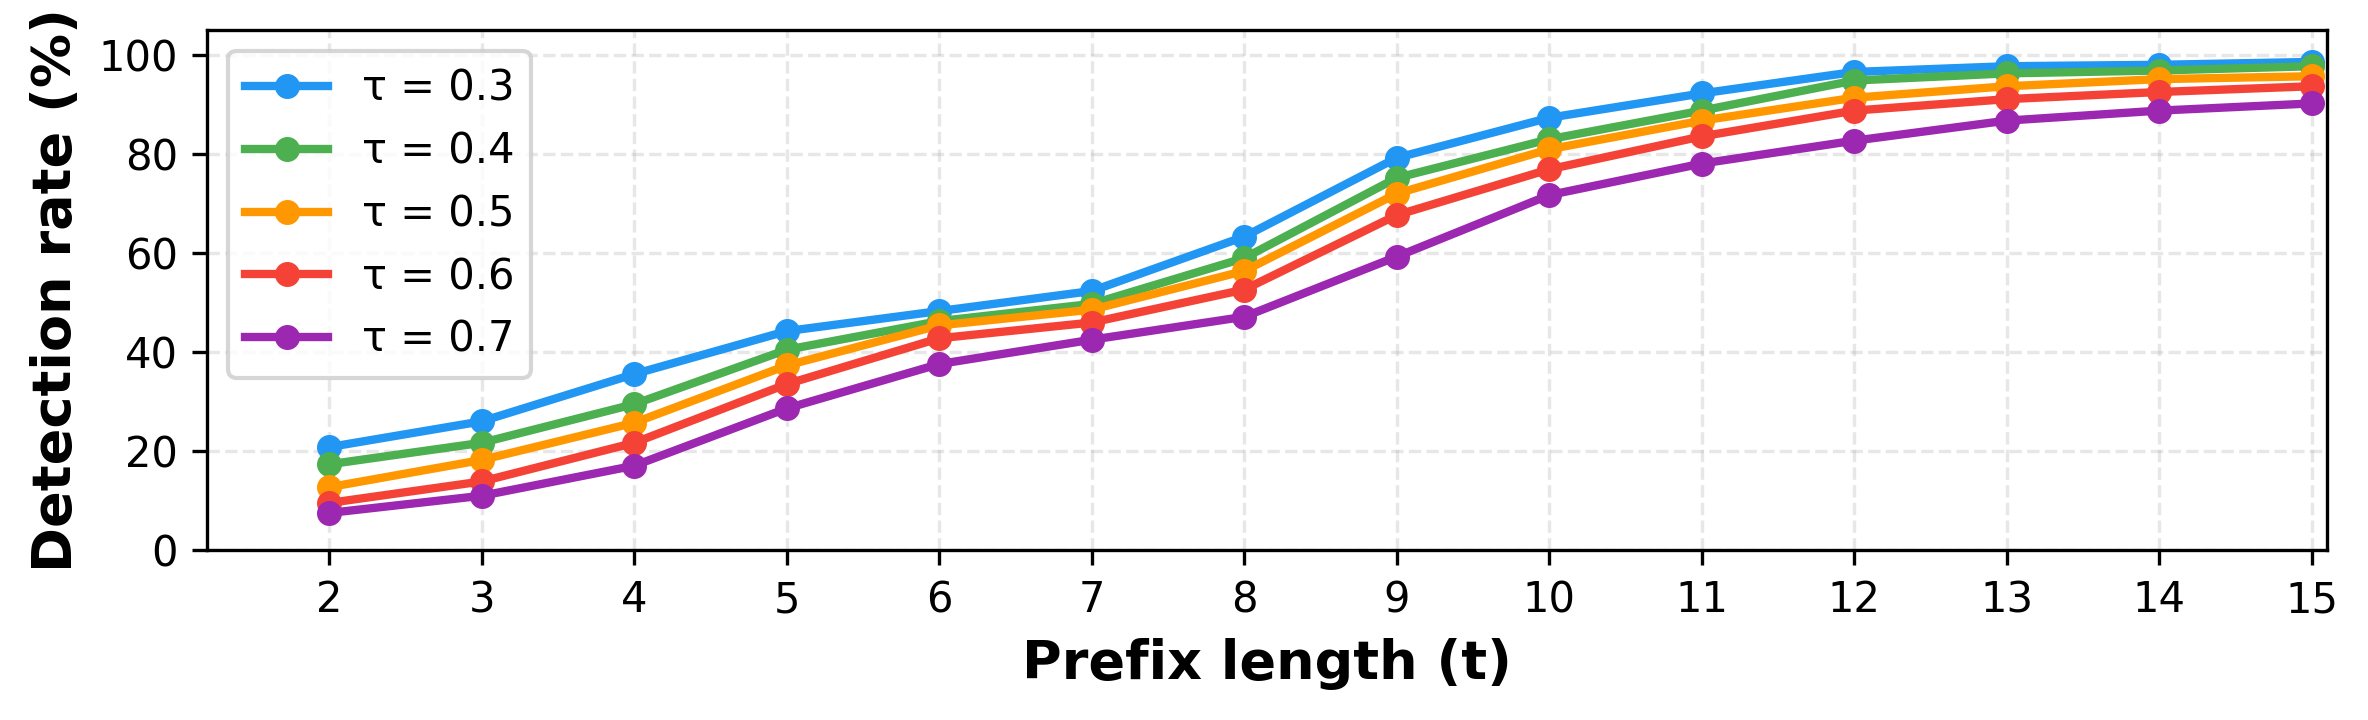

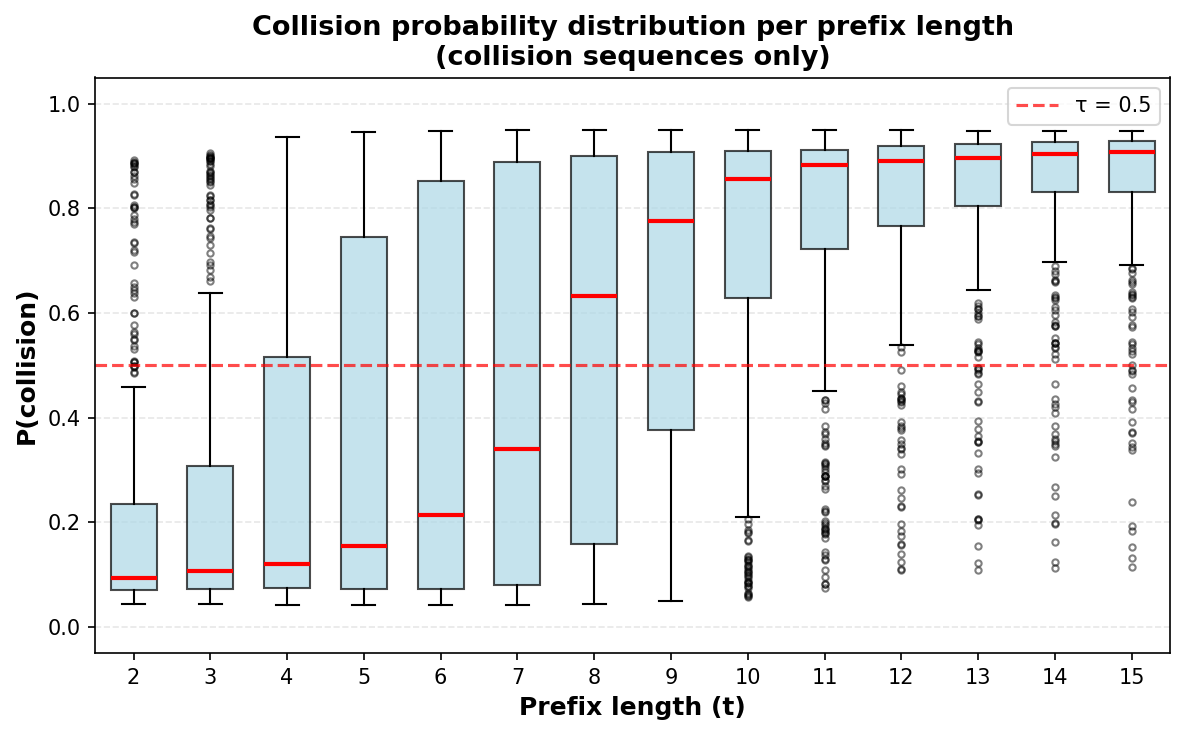

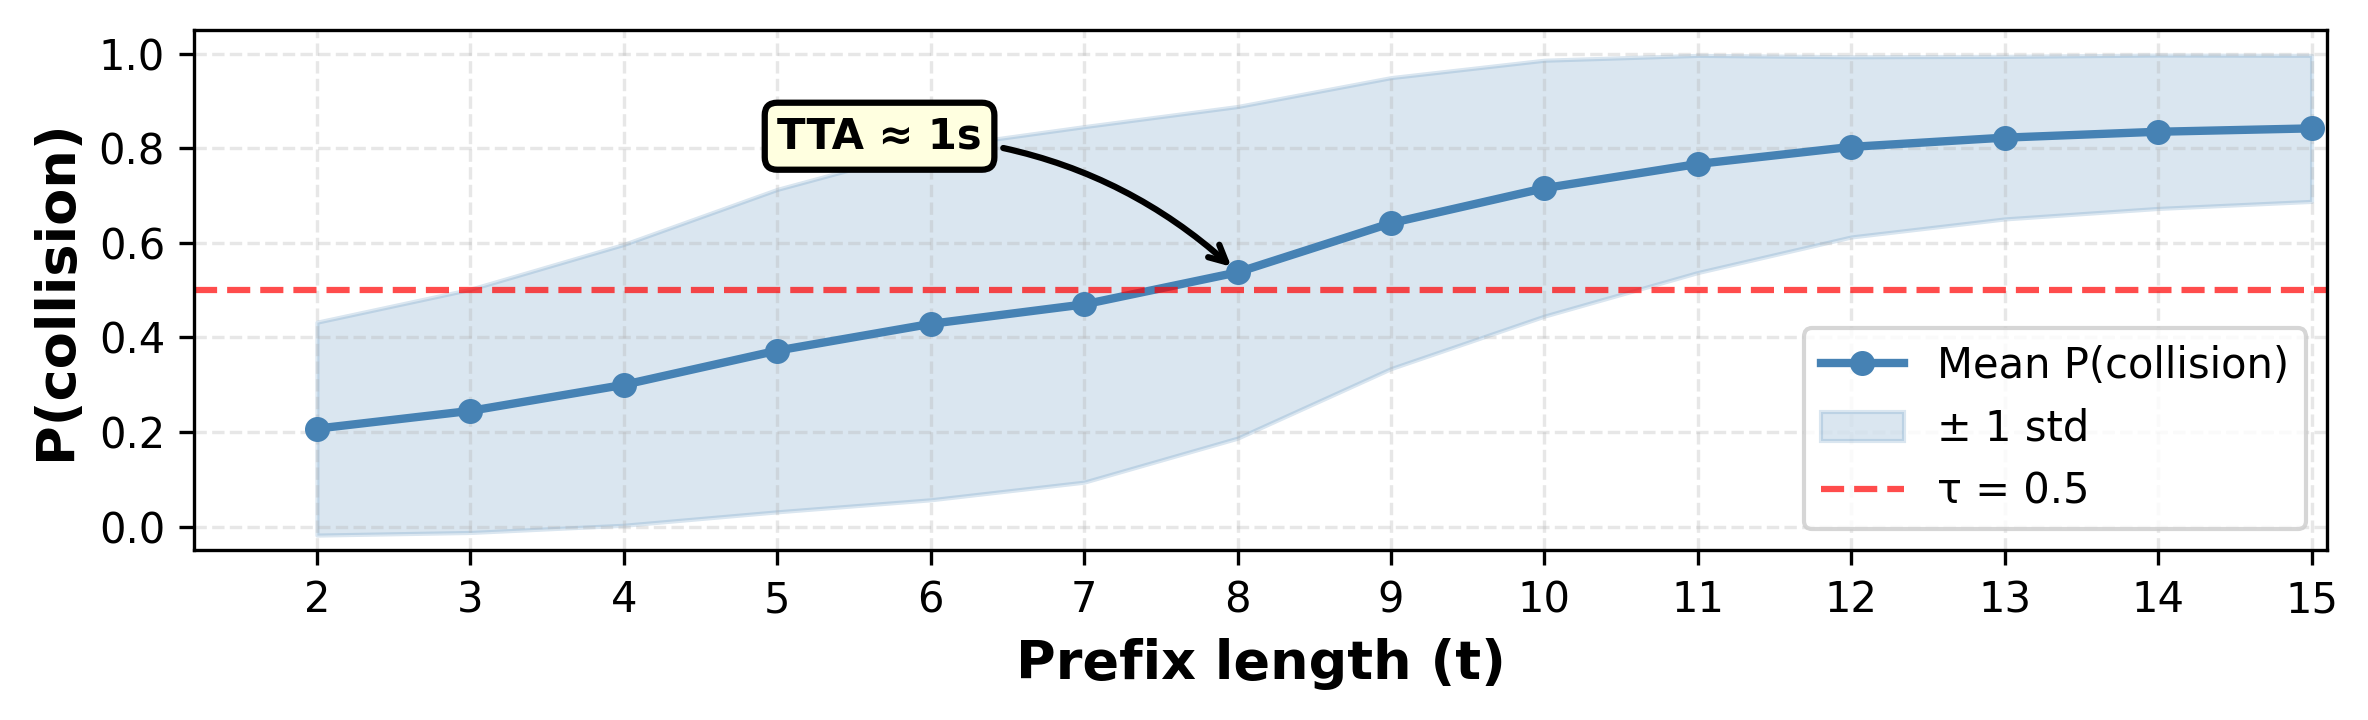


  PER-PREFIX DETECTION SUMMARY
     t   Time(s)    Mean P     Std P   Det@0.3   Det@0.5   Det@0.7    TTA(s)
  --------------------------------------------------------------------
     2     0.14s     0.207     0.225     20.8%     12.7%      7.5%     1.76s
     3     0.27s     0.245     0.257     26.0%     18.2%     11.0%     1.62s
     4     0.41s     0.300     0.297     35.5%     25.7%     17.1%     1.49s
     5     0.54s     0.372     0.341     44.2%     37.3%     28.6%     1.35s
     6     0.68s     0.429     0.372     48.3%     45.4%     37.6%     1.22s
     7     0.81s     0.470     0.376     52.3%     48.6%     42.5%     1.08s
     8     0.95s     0.538     0.351     63.3%     56.4%     47.1%     0.95s
     9     1.08s     0.642     0.308     79.2%     72.0%     59.2%     0.81s
    10     1.22s     0.716     0.271     87.3%     80.9%     71.7%     0.68s
    11     1.35s     0.767     0.230     92.2%     86.7%     78.0%     0.54s
    12     1.49s     0.803     0.191     96.5%    

In [70]:
# ============================================================
# 1. Rebuild the mapping: which prefixes belong to which sequence
# ============================================================
raw_data = load_mix_txt(TXT_PATH)
sequences, frame_labels, seq_ids = group_sequences_with_frame_labels(raw_data)

# Rebuild the prefix-to-sequence mapping (same logic as build_current_risk_prefixes)
prefix_to_seq = []  # prefix_to_seq[i] = index of the original sequence
min_len = 2

for seq_idx, seq in enumerate(sequences):
    T = len(seq)
    n_prefixes = T - min_len + 1  # prefixes of length 2, 3, ..., T
    prefix_to_seq.extend([seq_idx] * n_prefixes)

print(f"Total prefixes: {len(prefix_to_seq)}")
print(f"Should match sup_ds: {len(sup_ds)}")

# ============================================================
# 2. Find which SEQUENCES are in the validation set
# ============================================================
val_prefix_indices = val_ds.indices
val_seq_set = set(prefix_to_seq[i] for i in val_prefix_indices)

# Filter to collision sequences only
val_collision_indices = [s for s in val_seq_set if frame_labels[s].max() == 1]
val_non_collision_indices = [s for s in val_seq_set if frame_labels[s].max() == 0]

print(f"Val sequences (unique): {len(val_seq_set)}")
print(f"Val collision sequences: {len(val_collision_indices)}")
print(f"Val non-collision sequences: {len(val_non_collision_indices)}")

# ============================================================
# 3. Run TTA analysis ONLY on validation collision sequences
# ============================================================
prob_matrix, prefix_lengths = compute_all_prefix_probs(
    clf_model, sequences, val_collision_indices, device
)

fps = 7.4
frame_interval = 1.0 / fps

detection_results = compute_detection_rates(prob_matrix, prefix_lengths)


# ============================================================
# PLOT 1: Cumulative detection rate vs prefix length
# ============================================================
fig, ax = plt.subplots(figsize=(8, 2.5), dpi=300)

colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
for i, tau in enumerate(sorted(detection_results.keys())):
    ax.plot(prefix_lengths, detection_results[tau], '-o',
            markersize=5, linewidth=2, color=colors[i],
            label=f'τ = {tau}')

ax.set_xlabel("Prefix length (t)", fontsize=13, fontweight='bold')
ax.set_ylabel("Detection rate (%)", fontsize=13, fontweight='bold')
#ax.set_title("Collision detection rate vs. observation length",
#             fontsize=13, fontweight='bold')
ax.set_xticks(prefix_lengths)
ax.set_ylim(0, 105)
ax.set_xlim(1.2, 15.1)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# PLOT 2: Box plot of P(collision) per prefix length
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

bp = ax.boxplot(
    [prob_matrix[:, t_idx][~np.isnan(prob_matrix[:, t_idx])]
     for t_idx in range(len(prefix_lengths))],
    positions=prefix_lengths,
    widths=0.6,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', alpha=0.7),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(linewidth=1),
    flierprops=dict(marker='o', markersize=3, alpha=0.5)
)

ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5,
           alpha=0.7, label='τ = 0.5')
ax.set_xlabel("Prefix length (t)", fontsize=12, fontweight='bold')
ax.set_ylabel("P(collision)", fontsize=12, fontweight='bold')
ax.set_title("Collision probability distribution per prefix length\n"
             "(collision sequences only)", fontsize=13, fontweight='bold')
ax.set_xticks(prefix_lengths)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


# ============================================================
# PLOT 3: Mean P(collision) with std band
# ============================================================
fig, ax = plt.subplots(figsize=(8, 2.5), dpi=300)

mean_probs = np.nanmean(prob_matrix, axis=0)
std_probs = np.nanstd(prob_matrix, axis=0)

ax.plot(prefix_lengths, mean_probs, '-o', color='steelblue',
        linewidth=2, markersize=5, label='Mean P(collision)')
ax.fill_between(prefix_lengths,
                mean_probs - std_probs,
                np.minimum(mean_probs + std_probs, 1.0),
                alpha=0.2, color='steelblue', label='± 1 std')
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5,
           alpha=0.7, label='τ = 0.5')

# Find the first prefix length where mean P crosses τ = 0.5
threshold = 0.5
crossing_idx = None
for i, p in enumerate(mean_probs):
    if p >= threshold:
        crossing_idx = i
        break

if crossing_idx is not None:
    crossing_t = prefix_lengths[crossing_idx]
    crossing_p = mean_probs[crossing_idx]

    # TTA = frames remaining * frame_interval
    T_max = prefix_lengths[-1]
    fps = 7.4
    tta = (T_max - crossing_t) / fps

    ax.annotate(
        f'TTA ≈ {1}s',
        xy=(crossing_t, crossing_p),
        xytext=(crossing_t - 3, 0.80),
        fontsize=10,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                  edgecolor='black', linewidth=1.5),
        arrowprops=dict(
            arrowstyle='->',
            color='black',
            linewidth=1.5,
            connectionstyle='arc3,rad=-0.2'
        )
    )

ax.set_xlabel("Prefix length (t)", fontsize=13, fontweight='bold')
ax.set_ylabel("P(collision)", fontsize=13, fontweight='bold')
ax.set_xticks(prefix_lengths)
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(1.2, 15.1)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Summary table
# ============================================================
T_max = prefix_lengths[-1]  # last prefix = full sequence length

print(f"\n{'='*75}")
print(f"  PER-PREFIX DETECTION SUMMARY")
print(f"{'='*75}")
print(f"  {'t':>4}  {'Time(s)':>8}  {'Mean P':>8}  {'Std P':>8}  "
      f"{'Det@0.3':>8}  {'Det@0.5':>8}  {'Det@0.7':>8}  {'TTA(s)':>8}")
print(f"  {'-'*68}")

for t_idx, t in enumerate(prefix_lengths):
    time_from_start = (t - 1) * frame_interval
    frames_remaining = T_max - t
    tta = frames_remaining * frame_interval

    print(f"  {t:>4}  {time_from_start:>7.2f}s  {mean_probs[t_idx]:>8.3f}  "
          f"{std_probs[t_idx]:>8.3f}  "
          f"{detection_results[0.3][t_idx]:>7.1f}%  "
          f"{detection_results[0.5][t_idx]:>7.1f}%  "
          f"{detection_results[0.7][t_idx]:>7.1f}%  "
          f"{tta:>7.2f}s")


### Component ablation

In [ ]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score
# ============================================================
# ABLATION 1: Without Stage 1 pretraining (random encoder init)
# ============================================================
print("="*60)
print("  ABLATION 1: Without Stage 1 pretraining")
print("="*60)

encoder_no_pretrain = TemporalEncoder(
    input_dim=5, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1, max_len=500,)
# DO NOT load pretrained weights — encoder stays random
clf_no_pretrain = TemporalRiskTransformer(encoder_no_pretrain).to(device)

optimizer_a1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, clf_no_pretrain.parameters()),
    lr=1e-4, weight_decay=1e-4
)
early_stopper_a1 = EarlyStopping(patience=8, min_delta=1e-3, mode="max")

for epoch in range(1, 201):
    clf_no_pretrain.train()
    epoch_loss = 0.0
    for X, y, pad_mask in train_loader:
        X, y, pad_mask = X.to(device), y.to(device), pad_mask.to(device)
        logits, _ = clf_no_pretrain(X, pad_mask=pad_mask)
        loss = nnpu_loss(logits, y, prior=0.10)
        optimizer_a1.zero_grad()
        loss.backward()
        optimizer_a1.step()
        epoch_loss += loss.item()

    acc, auc, recall, f1 = evaluate_classifier(clf_no_pretrain, val_loader)
    if epoch % 10 == 0:
        print(f"  Epoch {epoch}: Loss={epoch_loss/len(train_loader):.4f}, Val F1={f1:.4f}")

    if early_stopper_a1.step(f1, clf_no_pretrain):
        print(f"  Early stopping at epoch {epoch}")
        break

early_stopper_a1.restore_best_weights(clf_no_pretrain)
acc, auc, r_a1, f1_a1 = evaluate_classifier(clf_no_pretrain, val_loader)

# Get precision manually
clf_no_pretrain.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for X, y, pad_mask in val_loader:
        X, pad_mask = X.to(device), pad_mask.to(device)
        logits, _ = clf_no_pretrain(X, pad_mask=pad_mask)
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(y.numpy())
y_true = np.concatenate(all_labels).astype(int)
y_pred = (np.concatenate(all_probs) >= 0.5).astype(int)
p_a1 = precision_score(y_true, y_pred, zero_division=0)

print(f"\n  ABLATION 1 RESULT: P={p_a1:.4f}, R={r_a1:.4f}, F1={f1_a1:.4f}")


# ============================================================
# ABLATION 2: Without attention pooling (mean pooling)
# ============================================================
print("\n" + "="*60)
print("  ABLATION 2: Without attention pooling (mean pooling)")
print("="*60)

class TemporalRiskTransformerMeanPool(nn.Module):
    """Same as TemporalRiskTransformer but uses mean pooling instead of attention."""
    def __init__(self, encoder, d_hidden=64, dropout=0.1):
        super().__init__()
        self.encoder = encoder
        d_model = encoder.d_model
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, 1),
        )

    def forward(self, x, pad_mask=None):
        h = self.encoder(x, pad_mask=pad_mask)  # (B, T, d_model)

        # Mean pooling (mask out padded positions)
        if pad_mask is not None:
            mask_float = (~pad_mask).float().unsqueeze(-1)  # (B, T, 1)
            z_seq = (h * mask_float).sum(dim=1) / mask_float.sum(dim=1).clamp(min=1)
        else:
            z_seq = h.mean(dim=1)

        logits = self.head(z_seq).squeeze(-1)
        return logits, z_seq

encoder_meanpool = TemporalEncoder(
    input_dim=5, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1, max_len=500,)
encoder_meanpool.load_state_dict(torch.load("pretrained_encoder.pt"))
clf_meanpool = TemporalRiskTransformerMeanPool(encoder_meanpool).to(device)

optimizer_a2 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, clf_meanpool.parameters()),
    lr=1e-4, weight_decay=1e-4
)
early_stopper_a2 = EarlyStopping(patience=8, min_delta=1e-3, mode="max")

for epoch in range(1, 201):
    clf_meanpool.train()
    epoch_loss = 0.0
    for X, y, pad_mask in train_loader:
        X, y, pad_mask = X.to(device), y.to(device), pad_mask.to(device)
        logits, _ = clf_meanpool(X, pad_mask=pad_mask)
        loss = nnpu_loss(logits, y, prior=0.10)
        optimizer_a2.zero_grad()
        loss.backward()
        optimizer_a2.step()
        epoch_loss += loss.item()

    acc, auc, recall, f1 = evaluate_classifier(clf_meanpool, val_loader)
    if epoch % 10 == 0:
        print(f"  Epoch {epoch}: Loss={epoch_loss/len(train_loader):.4f}, Val F1={f1:.4f}")

    if early_stopper_a2.step(f1, clf_meanpool):
        print(f"  Early stopping at epoch {epoch}")
        break

early_stopper_a2.restore_best_weights(clf_meanpool)
acc, auc, r_a2, f1_a2 = evaluate_classifier(clf_meanpool, val_loader)

clf_meanpool.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for X, y, pad_mask in val_loader:
        X, pad_mask = X.to(device), pad_mask.to(device)
        logits, _ = clf_meanpool(X, pad_mask=pad_mask)
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(y.numpy())
y_true = np.concatenate(all_labels).astype(int)
y_pred = (np.concatenate(all_probs) >= 0.5).astype(int)
p_a2 = precision_score(y_true, y_pred, zero_division=0)

print(f"\n  ABLATION 2 RESULT: P={p_a2:.4f}, R={r_a2:.4f}, F1={f1_a2:.4f}")


# ============================================================
# ABLATION 3: Without sin/cos yaw encoding (raw ψ)
# ============================================================
print("\n" + "="*60)
print("  ABLATION 3: Without sin/cos yaw (raw ψ, 4-dim input)")
print("="*60)

# Need to rebuild dataset with raw yaw instead of sin/cos
# Modify group_sequences_with_frame_labels to return [d, θ, ψ, v]

raw_data = load_mix_txt(TXT_PATH)

def group_sequences_raw_yaw(data):
    """Same as group_sequences_with_frame_labels but returns [d, θ, ψ, v] (4 features)."""
    seq_col = data[:, 7].astype(int)
    time_col = data[:, 0]
    unique_ids = np.unique(seq_col)

    sequences = []
    frame_labels = []
    seq_ids = []

    for sid in unique_ids:
        mask = (seq_col == sid)
        seq_data = data[mask]
        order = np.argsort(seq_data[:, 0])
        seq_data = seq_data[order]

        # Original features: [distance, angle, sin_yaw, cos_yaw, speed]
        # columns: 2=distance, 3=angle, 4=sin_yaw, 5=cos_yaw, 6=speed
        # Reconstruct raw yaw from sin/cos
        sin_yaw = seq_data[:, 4]
        cos_yaw = seq_data[:, 5]
        raw_yaw = np.arctan2(sin_yaw, cos_yaw)

        # New features: [distance, angle, raw_yaw, speed]
        features = np.column_stack([
            seq_data[:, 2],  # distance
            seq_data[:, 3],  # angle
            raw_yaw,         # raw yaw (instead of sin/cos)
            seq_data[:, 6],  # speed
        ])

        labels = seq_data[:, 8].astype(int) if seq_data.shape[1] > 8 else np.zeros(len(seq_data))

        sequences.append(features)
        frame_labels.append(labels)
        seq_ids.append(sid)

    return sequences, frame_labels, seq_ids

# Check your data columns — you may need to adjust the column indices above
# Let me provide a safer approach using the existing dataset

# Actually, the safest approach: modify the existing sequences
sequences_orig, frame_labels_orig, _ = group_sequences_with_frame_labels(raw_data)

sequences_raw_yaw = []
for seq in sequences_orig:
    # seq shape: (T, 5) = [distance, angle, sin_yaw, cos_yaw, speed]
    raw_yaw = np.arctan2(seq[:, 2], seq[:, 3])  # atan2(sin, cos)
    new_seq = np.column_stack([
        seq[:, 0],   # distance
        seq[:, 1],   # angle
        raw_yaw,     # raw yaw
        seq[:, 4],   # speed
    ])
    sequences_raw_yaw.append(new_seq)

# Build prefix dataset manually
prefix_seqs_a3, prefix_labels_a3 = build_current_risk_prefixes(
    sequences_raw_yaw, frame_labels_orig, min_len=2
)

# Create a simple dataset class
class SimpleDataset(torch.utils.data.Dataset):
    def __init__(self, seqs, labels):
        self.seqs = [torch.tensor(s, dtype=torch.float32) for s in seqs]
        self.labels = torch.tensor(labels, dtype=torch.float32)
    def __len__(self):
        return len(self.seqs)
    def __getitem__(self, idx):
        return self.seqs[idx], self.labels[idx]

ds_a3 = SimpleDataset(prefix_seqs_a3, prefix_labels_a3)

torch.manual_seed(42)
n_total_a3 = len(ds_a3)
n_train_a3 = int(0.8 * n_total_a3)
n_val_a3 = n_total_a3 - n_train_a3
train_ds_a3, val_ds_a3 = torch.utils.data.random_split(ds_a3, [n_train_a3, n_val_a3])

train_loader_a3 = DataLoader(train_ds_a3, batch_size=32, shuffle=True, collate_fn=pad_collate_supervised)
val_loader_a3 = DataLoader(val_ds_a3, batch_size=64, shuffle=False, collate_fn=pad_collate_supervised)

# Stage 1: pretrain with 4-dim input
encoder_a3 = TemporalEncoder(
    input_dim=4, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1, max_len=500,)
ae_a3 = TemporalAutoencoder(encoder_a3).to(device)
ae_opt_a3 = torch.optim.AdamW(ae_a3.parameters(), lr=1e-3, weight_decay=1e-4)

# Need unsupervised dataset too
class SimpleUnsupDataset(torch.utils.data.Dataset):
    def __init__(self, seqs):
        self.seqs = [torch.tensor(s, dtype=torch.float32) for s in seqs]
    def __len__(self):
        return len(self.seqs)
    def __getitem__(self, idx):
        return self.seqs[idx]

unsup_ds_a3 = SimpleUnsupDataset(sequences_raw_yaw)
unsup_loader_a3 = DataLoader(unsup_ds_a3, batch_size=32, shuffle=True, collate_fn=pad_collate_unsupervised)

print("  Stage 1 pretraining (4-dim input)...")
for epoch in range(1, 31):
    ae_a3.train()
    total_loss = 0
    for X, pad_mask in unsup_loader_a3:
        X, pad_mask = X.to(device), pad_mask.to(device)
        X_hat = ae_a3(X, pad_mask=pad_mask)
        loss = F.mse_loss(X_hat, X)
        ae_opt_a3.zero_grad()
        loss.backward()
        ae_opt_a3.step()
        total_loss += loss.item()
    if epoch % 10 == 0:
        print(f"    Epoch {epoch}: MSE={total_loss/len(unsup_loader_a3):.4f}")

# Stage 2
clf_a3 = TemporalRiskTransformer(encoder_a3).to(device)
optimizer_a3 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, clf_a3.parameters()),
    lr=1e-4, weight_decay=1e-4
)
early_stopper_a3 = EarlyStopping(patience=8, min_delta=1e-3, mode="max")

print("  Stage 2 nnPU fine-tuning...")
for epoch in range(1, 201):
    clf_a3.train()
    epoch_loss = 0.0
    for X, y, pad_mask in train_loader_a3:
        X, y, pad_mask = X.to(device), y.to(device), pad_mask.to(device)
        logits, _ = clf_a3(X, pad_mask=pad_mask)
        loss = nnpu_loss(logits, y, prior=0.10)
        optimizer_a3.zero_grad()
        loss.backward()
        optimizer_a3.step()
        epoch_loss += loss.item()

    acc, auc, recall, f1 = evaluate_classifier(clf_a3, val_loader_a3)
    if epoch % 10 == 0:
        print(f"    Epoch {epoch}: Loss={epoch_loss/len(train_loader_a3):.4f}, Val F1={f1:.4f}")

    if early_stopper_a3.step(f1, clf_a3):
        print(f"    Early stopping at epoch {epoch}")
        break

early_stopper_a3.restore_best_weights(clf_a3)
acc, auc, r_a3, f1_a3 = evaluate_classifier(clf_a3, val_loader_a3)

clf_a3.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for X, y, pad_mask in val_loader_a3:
        X, pad_mask = X.to(device), pad_mask.to(device)
        logits, _ = clf_a3(X, pad_mask=pad_mask)
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(y.numpy())
y_true = np.concatenate(all_labels).astype(int)
y_pred = (np.concatenate(all_probs) >= 0.5).astype(int)
p_a3 = precision_score(y_true, y_pred, zero_division=0)

print(f"\n  ABLATION 3 RESULT: P={p_a3:.4f}, R={r_a3:.4f}, F1={f1_a3:.4f}")


# ============================================================
# ABLATION 4: Without speed feature (4-dim input)
# ============================================================
print("\n" + "="*60)
print("  ABLATION 4: Without speed feature")
print("="*60)

sequences_no_speed = []
for seq in sequences_orig:
    # seq: (T, 5) = [distance, angle, sin_yaw, cos_yaw, speed]
    # Remove speed (column 4)
    new_seq = seq[:, :4]  # [distance, angle, sin_yaw, cos_yaw]
    sequences_no_speed.append(new_seq)

prefix_seqs_a4, prefix_labels_a4 = build_current_risk_prefixes(
    sequences_no_speed, frame_labels_orig, min_len=2
)

ds_a4 = SimpleDataset(prefix_seqs_a4, prefix_labels_a4)
torch.manual_seed(42)
n_train_a4 = int(0.8 * len(ds_a4))
train_ds_a4, val_ds_a4 = torch.utils.data.random_split(ds_a4, [n_train_a4, len(ds_a4) - n_train_a4])

train_loader_a4 = DataLoader(train_ds_a4, batch_size=32, shuffle=True, collate_fn=pad_collate_supervised)
val_loader_a4 = DataLoader(val_ds_a4, batch_size=64, shuffle=False, collate_fn=pad_collate_supervised)

# Stage 1
encoder_a4 = TemporalEncoder(
    input_dim=4, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1, max_len=500,)
ae_a4 = TemporalAutoencoder(encoder_a4).to(device)
ae_opt_a4 = torch.optim.AdamW(ae_a4.parameters(), lr=1e-3, weight_decay=1e-4)

unsup_ds_a4 = SimpleUnsupDataset(sequences_no_speed)
unsup_loader_a4 = DataLoader(unsup_ds_a4, batch_size=32, shuffle=True, collate_fn=pad_collate_unsupervised)

print("  Stage 1 pretraining (no speed)...")
for epoch in range(1, 31):
    ae_a4.train()
    total_loss = 0
    for X, pad_mask in unsup_loader_a4:
        X, pad_mask = X.to(device), pad_mask.to(device)
        X_hat = ae_a4(X, pad_mask=pad_mask)
        loss = F.mse_loss(X_hat, X)
        ae_opt_a4.zero_grad()
        loss.backward()
        ae_opt_a4.step()
        total_loss += loss.item()
    if epoch % 10 == 0:
        print(f"    Epoch {epoch}: MSE={total_loss/len(unsup_loader_a4):.4f}")

# Stage 2
clf_a4 = TemporalRiskTransformer(encoder_a4).to(device)
optimizer_a4 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, clf_a4.parameters()),
    lr=1e-4, weight_decay=1e-4
)
early_stopper_a4 = EarlyStopping(patience=8, min_delta=1e-3, mode="max")

print("  Stage 2 nnPU fine-tuning...")
for epoch in range(1, 201):
    clf_a4.train()
    epoch_loss = 0.0
    for X, y, pad_mask in train_loader_a4:
        X, y, pad_mask = X.to(device), y.to(device), pad_mask.to(device)
        logits, _ = clf_a4(X, pad_mask=pad_mask)
        loss = nnpu_loss(logits, y, prior=0.10)
        optimizer_a4.zero_grad()
        loss.backward()
        optimizer_a4.step()
        epoch_loss += loss.item()

    acc, auc, recall, f1 = evaluate_classifier(clf_a4, val_loader_a4)
    if epoch % 10 == 0:
        print(f"    Epoch {epoch}: Loss={epoch_loss/len(train_loader_a4):.4f}, Val F1={f1:.4f}")

    if early_stopper_a4.step(f1, clf_a4):
        print(f"    Early stopping at epoch {epoch}")
        break

early_stopper_a4.restore_best_weights(clf_a4)
acc, auc, r_a4, f1_a4 = evaluate_classifier(clf_a4, val_loader_a4)

clf_a4.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for X, y, pad_mask in val_loader_a4:
        X, pad_mask = X.to(device), pad_mask.to(device)
        logits, _ = clf_a4(X, pad_mask=pad_mask)
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(y.numpy())
y_true = np.concatenate(all_labels).astype(int)
y_pred = (np.concatenate(all_probs) >= 0.5).astype(int)
p_a4 = precision_score(y_true, y_pred, zero_division=0)

print(f"\n  ABLATION 4 RESULT: P={p_a4:.4f}, R={r_a4:.4f}, F1={f1_a4:.4f}")


# ============================================================
# SUMMARY TABLE
# ============================================================
print(f"\n{'='*65}")
print(f"  COMPONENT ABLATION SUMMARY")
print(f"{'='*65}")
print(f"  {'Variant':<35} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print(f"  {'-'*55}")
print(f"  {'Full model (T-nnPU)':.<35} {'0.94':>10} {'0.90':>8} {'0.92':>8}")
print(f"  {'w/o Stage 1 pretraining':<35} {p_a1:>10.4f} {r_a1:>8.4f} {f1_a1:>8.4f}")
print(f"  {'w/o attention pooling (mean)':<35} {p_a2:>10.4f} {r_a2:>8.4f} {f1_a2:>8.4f}")
print(f"  {'w/o sin/cos yaw (raw ψ)':<35} {p_a3:>10.4f} {r_a3:>8.4f} {f1_a3:>8.4f}")
print(f"  {'w/o speed feature':<35} {p_a4:>10.4f} {r_a4:>8.4f} {f1_a4:>8.4f}")




  ABLATION 1: Without Stage 1 pretraining


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  Epoch 10: Loss=0.0898, Val F1=0.8377
  Epoch 20: Loss=0.0804, Val F1=0.8649


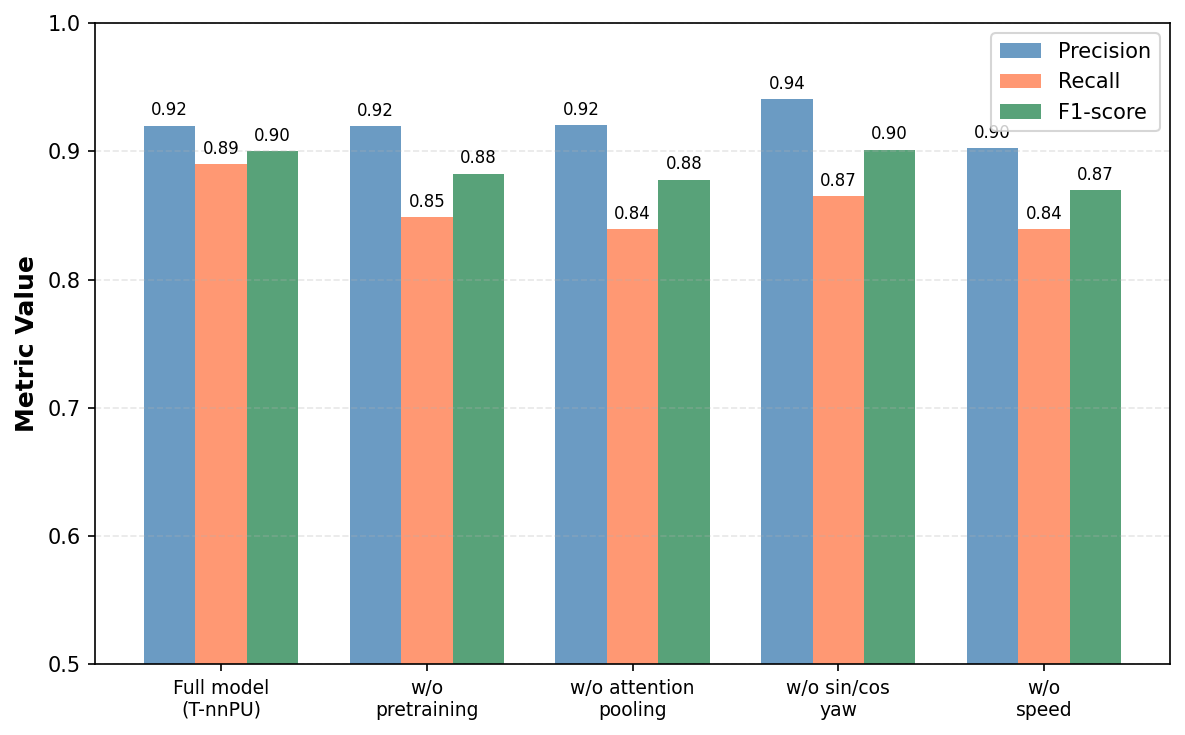

In [306]:
# ============================================================
# BAR CHART
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

variants = ['Full model\n(T-nnPU)', 'w/o\npretraining', 'w/o attention\npooling', 'w/o sin/cos\nyaw', 'w/o\nspeed']
f1_scores = [0.90, f1_a1, f1_a2, f1_a3, f1_a4]
precisions = [0.92, p_a1, p_a2, p_a3, p_a4]
recalls = [0.89, r_a1, r_a2, r_a3, r_a4]

x = np.arange(len(variants))
width = 0.25

bars1 = ax.bar(x - width, precisions, width, label='Precision', color='steelblue', alpha=0.8)
bars2 = ax.bar(x, recalls, width, label='Recall', color='coral', alpha=0.8)
bars3 = ax.bar(x + width, f1_scores, width, label='F1-score', color='seagreen', alpha=0.8)

ax.set_ylabel('Metric Value', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(variants, fontsize=9)
ax.set_ylim(0.5, 1.0)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### Model capacity analisys

In [64]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
# ============================================================
# EXPERIMENT 1: Model dimension scaling
# ============================================================
print("="*60)
print("  MODEL DIMENSION SCALING")
print("="*60)

configs = [
    {"d_model": 32,  "nhead": 2, "dim_ff": 64,  "label": "d=32"},
    {"d_model": 64,  "nhead": 4, "dim_ff": 128, "label": "d=64 (ours)"},
    {"d_model": 128, "nhead": 4, "dim_ff": 256, "label": "d=128"},
    {"d_model": 256, "nhead": 8, "dim_ff": 512, "label": "d=256"},
]

dim_results = {}

for cfg in configs:
    print(f"\n{'─'*50}")
    print(f"  Training: {cfg['label']}")
    print(f"{'─'*50}")

    # --- Stage 1: Pretrain ---
    encoder_dim = TemporalEncoder(
        input_dim=5, d_model=cfg["d_model"], nhead=cfg["nhead"],
        num_layers=2, dim_feedforward=cfg["dim_ff"], dropout=0.1, max_len=500
    )
    ae_dim = TemporalAutoencoder(encoder_dim).to(device)
    ae_opt = torch.optim.AdamW(ae_dim.parameters(), lr=1e-3, weight_decay=1e-4)

    print("  Stage 1 pretraining...")
    for epoch in range(1, 31):
        ae_dim.train()
        total_loss = 0
        for X, pad_mask in unsup_loader:
            X, pad_mask = X.to(device), pad_mask.to(device)
            X_hat = ae_dim(X, pad_mask=pad_mask)
            loss = F.mse_loss(X_hat, X)
            ae_opt.zero_grad()
            loss.backward()
            ae_opt.step()
            total_loss += loss.item()
        if epoch % 10 == 0:
            print(f"    Epoch {epoch}: MSE={total_loss/len(unsup_loader):.4f}")

    # --- Stage 2: nnPU fine-tuning ---
    clf_dim = TemporalRiskTransformer(encoder_dim, d_hidden=cfg["d_model"]).to(device)
    clf_opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, clf_dim.parameters()),
        lr=1e-4, weight_decay=1e-4
    )
    early_stopper = EarlyStopping(patience=8, min_delta=1e-3, mode="max")

    print("  Stage 2 nnPU fine-tuning...")
    for epoch in range(1, 201):
        clf_dim.train()
        epoch_loss = 0.0
        for X, y, pad_mask in train_loader:
            X, y, pad_mask = X.to(device), y.to(device), pad_mask.to(device)
            logits, _ = clf_dim(X, pad_mask=pad_mask)
            loss = nnpu_loss(logits, y, prior=0.10)
            clf_opt.zero_grad()
            loss.backward()
            clf_opt.step()
            epoch_loss += loss.item()

        acc, auc, recall, f1 = evaluate_classifier(clf_dim, val_loader)
        if epoch % 10 == 0:
            print(f"    Epoch {epoch}: Loss={epoch_loss/len(train_loader):.4f}, Val F1={f1:.4f}")

        if early_stopper.step(f1, clf_dim):
            print(f"    Early stopping at epoch {epoch}")
            break

    early_stopper.restore_best_weights(clf_dim)

    # --- Evaluate ---
    clf_dim.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X, y, pad_mask in val_loader:
            X, pad_mask = X.to(device), pad_mask.to(device)
            logits, _ = clf_dim(X, pad_mask=pad_mask)
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(y.numpy())

    y_true = np.concatenate(all_labels).astype(int)
    y_pred = (np.concatenate(all_probs) >= 0.5).astype(int)

    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1_val = f1_score(y_true, y_pred, zero_division=0)

    # Count parameters
    n_params = sum(p.numel() for p in clf_dim.parameters())

    dim_results[cfg["label"]] = {
        "precision": p, "recall": r, "f1": f1_val, "params": n_params
    }

    print(f"\n  {cfg['label']}: P={p:.4f}, R={r:.4f}, F1={f1_val:.4f}, Params={n_params:,}")


# ============================================================
# EXPERIMENT 2: Reconstruction head complexity
# ============================================================
print(f"\n{'='*60}")
print("  RECONSTRUCTION HEAD COMPLEXITY")
print("='*60")

class TemporalAutoencoderMLP(nn.Module):
    """Autoencoder with MLP reconstruction head instead of linear."""
    def __init__(self, encoder, hidden_dim=32):
        super().__init__()
        self.encoder = encoder
        self.out_proj = nn.Sequential(
            nn.Linear(encoder.d_model, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, encoder.input_dim)
        )

    def forward(self, x, pad_mask=None):
        h = self.encoder(x, pad_mask=pad_mask)
        x_hat = self.out_proj(h)
        return x_hat

recon_configs = [
    {"type": "linear", "label": "Linear (ours)"},
    {"type": "mlp_32", "label": "MLP (64→32→5)"},
    {"type": "mlp_64", "label": "MLP (64→64→5)"},
]

recon_results = {}

for cfg in recon_configs:
    print(f"\n{'─'*50}")
    print(f"  Training: {cfg['label']}")
    print(f"{'─'*50}")

    # Fresh encoder
    encoder_rec = TemporalEncoder(
        input_dim=5, d_model=64, nhead=4, num_layers=2,
        dim_feedforward=128, dropout=0.1, max_len=500
    )

    # Build autoencoder based on config
    if cfg["type"] == "linear":
        ae_rec = TemporalAutoencoder(encoder_rec).to(device)
    elif cfg["type"] == "mlp_32":
        ae_rec = TemporalAutoencoderMLP(encoder_rec, hidden_dim=32).to(device)
    elif cfg["type"] == "mlp_64":
        ae_rec = TemporalAutoencoderMLP(encoder_rec, hidden_dim=64).to(device)

    ae_opt = torch.optim.AdamW(ae_rec.parameters(), lr=1e-3, weight_decay=1e-4)

    # Stage 1
    print("  Stage 1 pretraining...")
    final_mse = 0
    for epoch in range(1, 31):
        ae_rec.train()
        total_loss = 0
        for X, pad_mask in unsup_loader:
            X, pad_mask = X.to(device), pad_mask.to(device)
            X_hat = ae_rec(X, pad_mask=pad_mask)
            loss = F.mse_loss(X_hat, X)
            ae_opt.zero_grad()
            loss.backward()
            ae_opt.step()
            total_loss += loss.item()
        final_mse = total_loss / len(unsup_loader)
        if epoch % 10 == 0:
            print(f"    Epoch {epoch}: MSE={final_mse:.4f}")

    # Stage 2: use the pretrained encoder
    clf_rec = TemporalRiskTransformer(encoder_rec).to(device)
    clf_opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, clf_rec.parameters()),
        lr=1e-4, weight_decay=1e-4
    )
    early_stopper = EarlyStopping(patience=8, min_delta=1e-3, mode="max")

    print("  Stage 2 nnPU fine-tuning...")
    for epoch in range(1, 201):
        clf_rec.train()
        epoch_loss = 0.0
        for X, y, pad_mask in train_loader:
            X, y, pad_mask = X.to(device), y.to(device), pad_mask.to(device)
            logits, _ = clf_rec(X, pad_mask=pad_mask)
            loss = nnpu_loss(logits, y, prior=0.10)
            clf_opt.zero_grad()
            loss.backward()
            clf_opt.step()
            epoch_loss += loss.item()

        acc, auc, recall, f1 = evaluate_classifier(clf_rec, val_loader)
        if epoch % 10 == 0:
            print(f"    Epoch {epoch}: Loss={epoch_loss/len(train_loader):.4f}, Val F1={f1:.4f}")

        if early_stopper.step(f1, clf_rec):
            print(f"    Early stopping at epoch {epoch}")
            break

    early_stopper.restore_best_weights(clf_rec)

    # Evaluate
    clf_rec.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X, y, pad_mask in val_loader:
            X, pad_mask = X.to(device), pad_mask.to(device)
            logits, _ = clf_rec(X, pad_mask=pad_mask)
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(y.numpy())

    y_true = np.concatenate(all_labels).astype(int)
    y_pred = (np.concatenate(all_probs) >= 0.5).astype(int)

    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1_val = f1_score(y_true, y_pred, zero_division=0)

    recon_results[cfg["label"]] = {
        "precision": p, "recall": r, "f1": f1_val, "final_mse": final_mse
    }

    print(f"\n  {cfg['label']}: P={p:.4f}, R={r:.4f}, F1={f1_val:.4f}, MSE={final_mse:.4f}")

  MODEL DIMENSION SCALING

──────────────────────────────────────────────────
  Training: d=32
──────────────────────────────────────────────────
  Stage 1 pretraining...


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


    Epoch 10: MSE=0.0430
    Epoch 20: MSE=0.0151
    Epoch 30: MSE=0.0077
  Stage 2 nnPU fine-tuning...
    Epoch 10: Loss=0.1014, Val F1=0.8088
    Epoch 20: Loss=0.0911, Val F1=0.8442
    Early stopping at epoch 25

  d=32: P=0.9033, R=0.8212, F1=0.8603, Params=18,466

──────────────────────────────────────────────────
  Training: d=64 (ours)
──────────────────────────────────────────────────
  Stage 1 pretraining...


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


    Epoch 10: MSE=0.0190
    Epoch 20: MSE=0.0070
    Epoch 30: MSE=0.0036
  Stage 2 nnPU fine-tuning...
    Epoch 10: Loss=0.0868, Val F1=0.8569
    Epoch 20: Loss=0.0813, Val F1=0.8792
    Epoch 30: Loss=0.0728, Val F1=0.8968
    Epoch 40: Loss=0.0695, Val F1=0.8736
    Early stopping at epoch 46

  d=64 (ours): P=0.9307, R=0.8955, F1=0.9127, Params=71,746

──────────────────────────────────────────────────
  Training: d=128
──────────────────────────────────────────────────


...

  Stage 1 pretraining...
    Epoch 10: MSE=0.0210
    Epoch 20: MSE=0.0078
    Epoch 30: MSE=0.0045
  Stage 2 nnPU fine-tuning...
    Epoch 10: Loss=0.0925, Val F1=0.8545
    Epoch 20: Loss=0.0838, Val F1=0.8615
    Epoch 30: Loss=0.0774, Val F1=0.8689
    Epoch 40: Loss=0.0732, Val F1=0.8733
    Early stopping at epoch 41

  Linear (ours): P=0.9242, R=0.8500, F1=0.8856, MSE=0.0045

──────────────────────────────────────────────────
  Training: MLP (64→32→5)
──────────────────────────────────────────────────
  Stage 1 pretraining...


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


    Epoch 10: MSE=0.0175
    Epoch 20: MSE=0.0047
    Epoch 30: MSE=0.0023
  Stage 2 nnPU fine-tuning...
    Epoch 10: Loss=0.0907, Val F1=0.8599
    Epoch 20: Loss=0.0799, Val F1=0.8631
    Early stopping at epoch 29

  MLP (64→32→5): P=0.9148, R=0.8788, F1=0.8964, MSE=0.0023

──────────────────────────────────────────────────
  Training: MLP (64→64→5)
──────────────────────────────────────────────────
  Stage 1 pretraining...


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


    Epoch 10: MSE=0.0130
    Epoch 20: MSE=0.0031
    Epoch 30: MSE=0.0015
  Stage 2 nnPU fine-tuning...
    Epoch 10: Loss=0.0832, Val F1=0.8804
    Epoch 20: Loss=0.0780, Val F1=0.8891
    Early stopping at epoch 29

  MLP (64→64→5): P=0.9015, R=0.9015, F1=0.9015, MSE=0.0015



  MODEL DIMENSION SCALING SUMMARY
  Config                   Params  Precision   Recall       F1
  -------------------------------------------------------
  d=32                     18,466     0.9033   0.8212   0.8603
  d=64 (ours)              71,746     0.9307   0.8955   0.9127
  d=128                   282,754     0.9482   0.8606   0.9023
  d=256                 1,122,562     0.9319   0.8500   0.8891

  RECONSTRUCTION HEAD COMPLEXITY SUMMARY
  Config                     Final MSE  Precision   Recall       F1
  ------------------------------------------------------------
  Linear (ours)                 0.0045     0.9242   0.8500   0.8856
  MLP (64→32→5)                 0.0023     0.9148   0.8788   0.8964
  MLP (64→64→5)                 0.0015     0.9015   0.9015   0.9015


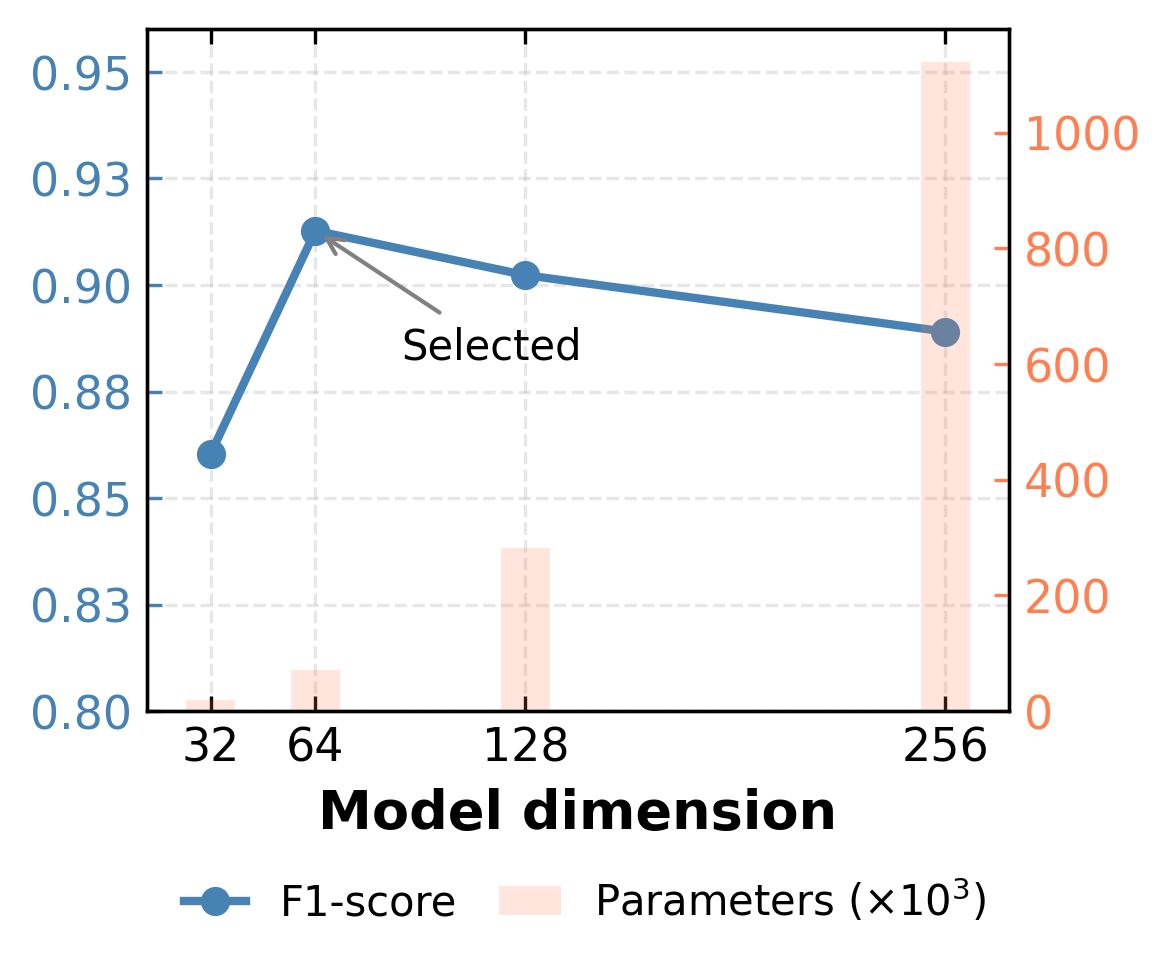

In [85]:
import matplotlib.ticker as mticker
# ============================================================
# SUMMARY TABLES
# ============================================================
print(f"\n{'='*65}")
print(f"  MODEL DIMENSION SCALING SUMMARY")
print(f"{'='*65}")
print(f"  {'Config':<20} {'Params':>10} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print(f"  {'-'*55}")
for label, r in dim_results.items():
    print(f"  {label:<20} {r['params']:>10,} {r['precision']:>10.4f} {r['recall']:>8.4f} {r['f1']:>8.4f}")

print(f"\n{'='*65}")
print(f"  RECONSTRUCTION HEAD COMPLEXITY SUMMARY")
print(f"{'='*65}")
print(f"  {'Config':<25} {'Final MSE':>10} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print(f"  {'-'*60}")
for label, r in recon_results.items():
    print(f"  {label:<25} {r['final_mse']:>10.4f} {r['precision']:>10.4f} {r['recall']:>8.4f} {r['f1']:>8.4f}")


# ============================================================
# PLOT: Model dimension vs F1 with parameter count
# ============================================================
fig, ax1 = plt.subplots(figsize=(4, 3), dpi=300)

d_labels = list(dim_results.keys())
d_f1 = [dim_results[l]["f1"] for l in d_labels]
d_params = [dim_results[l]["params"] for l in d_labels]
d_models = [32, 64, 128, 256]

# F1-score line
line1, = ax1.plot(d_models, d_f1, '-o', color='steelblue', linewidth=2, markersize=6, label='F1-score')
ax1.set_xlabel("Model dimension", fontsize=13, fontweight='bold')
ax1.set_xticks(d_models)
ax1.set_ylim(0.80, 0.96)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax1.tick_params(axis='y', labelsize=11, direction='in', colors='steelblue')
ax1.tick_params(axis='x', labelsize=11, direction='in', top=True)
ax1.grid(True, linestyle='--', alpha=0.3)

# No y-axis label — color does the job
ax1.set_ylabel("")

# Selected annotation
ax1.annotate('Selected', xy=(64, d_f1[1]), xytext=(90, d_f1[1] - 0.03),
             fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'))

# Secondary axis
ax2 = ax1.twinx()
bars = ax2.bar(d_models, [p / 1e3 for p in d_params], width=15, alpha=0.2, color='coral', label='Parameters (×$10^3$)')
ax2.set_ylabel("")
ax2.tick_params(axis='y', labelsize=11, direction='in', colors='coral')

# Combined legend at bottom
fig.legend(
    handles=[line1, bars],
    labels=['F1-score', 'Parameters (×$10^3$)'],
    prop={'size': 10},
    loc='upper center',
    bbox_to_anchor=(0.5, 0.05),
    ncol=2,
    handlelength=1.5,
    columnspacing=1.0,
    frameon=False
)

plt.subplots_adjust(bottom=0.6)
ax.spines[['top', 'right']].set_visible(True)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
ax.set_axisbelow(True)  # keeps grid behind the bars

plt.tight_layout()


plt.show()

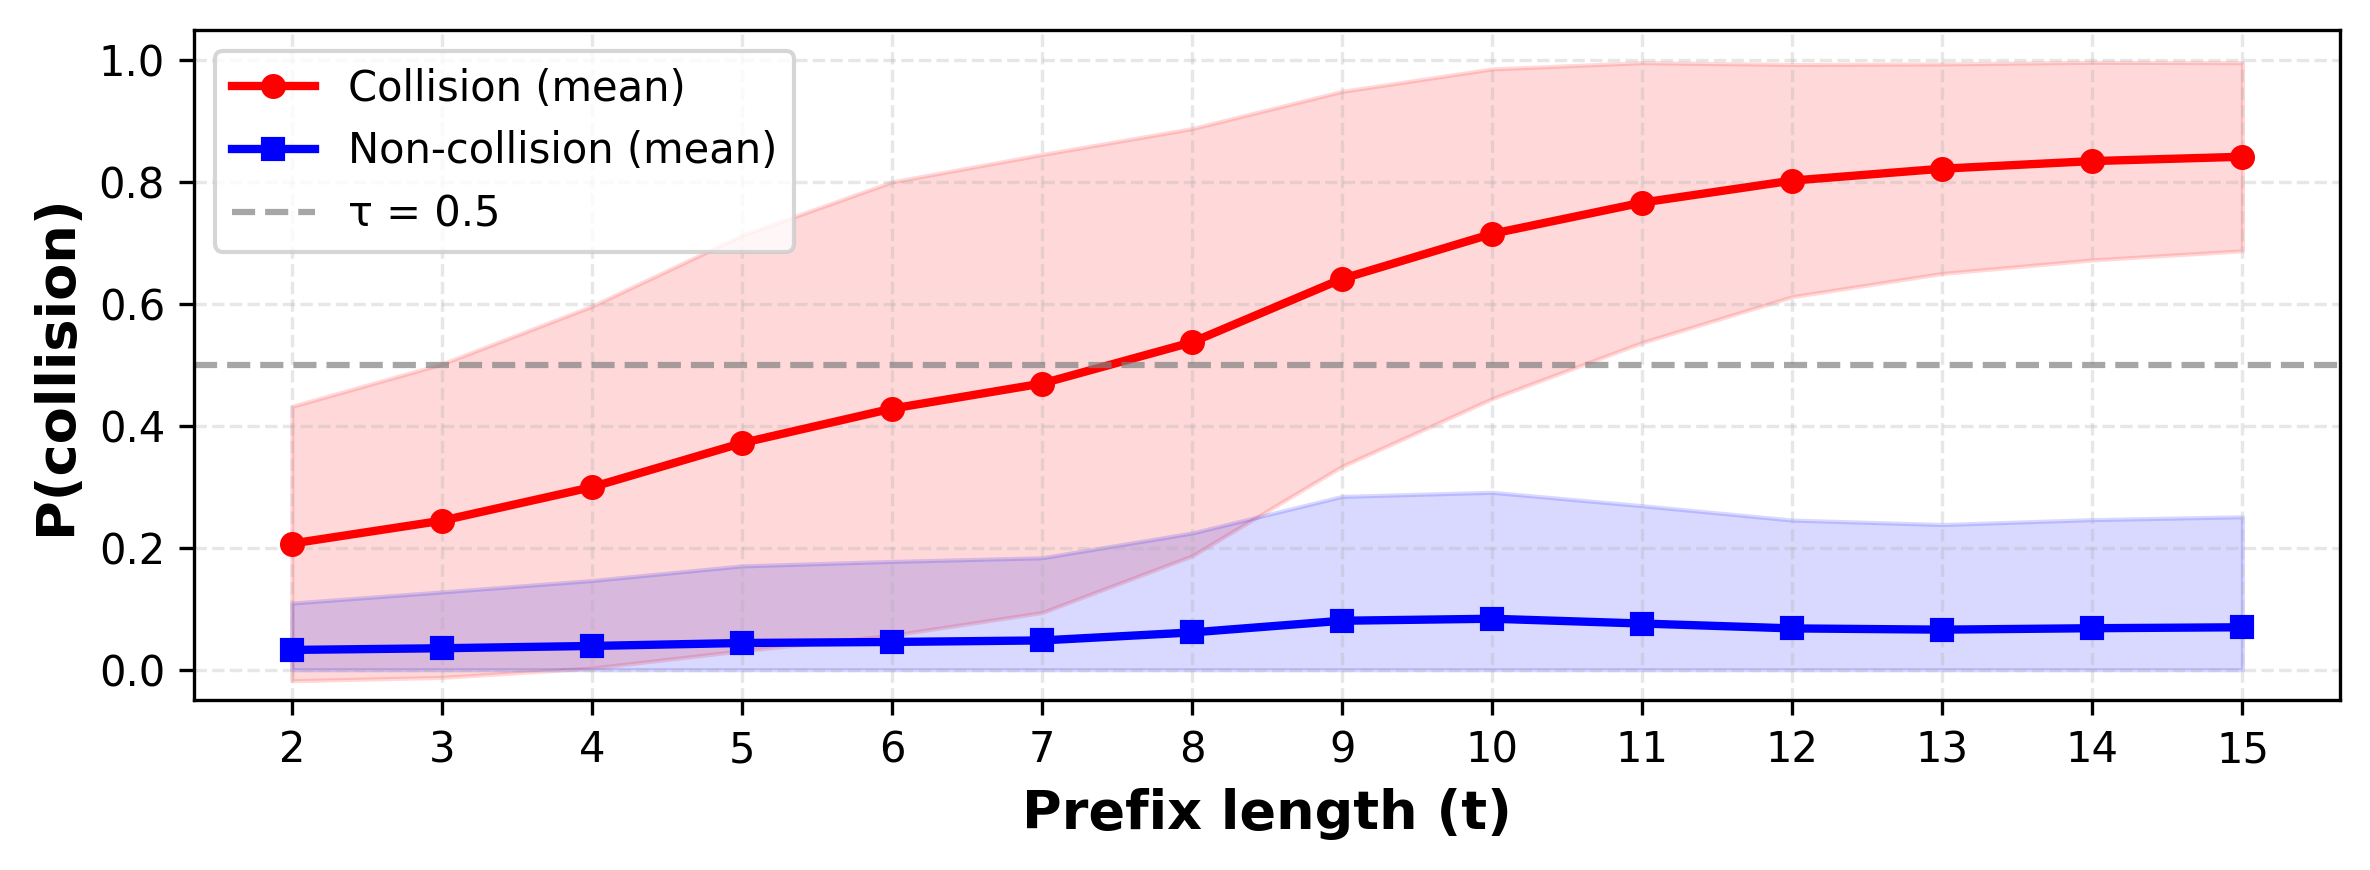


  FALSE ALARM ANALYSIS (non-collision sequences)
     t    Mean P     Std P    FA@0.3    FA@0.5    FA@0.7
  --------------------------------------------------
     2     0.032     0.077      0.8%      0.5%      0.5%
     3     0.035     0.092      0.8%      0.8%      0.8%
     4     0.039     0.107      1.1%      1.1%      1.1%
     5     0.044     0.127      1.6%      1.6%      1.6%
     6     0.046     0.132      2.0%      1.8%      1.8%
     7     0.048     0.136      2.1%      2.0%      2.0%
     8     0.061     0.163      3.3%      2.8%      2.8%
     9     0.080     0.204      4.6%      4.6%      4.6%
    10     0.084     0.208      4.8%      4.8%      4.8%
    11     0.076     0.193      4.3%      4.1%      4.1%
    12     0.068     0.178      3.4%      3.4%      3.4%
    13     0.066     0.173      3.4%      3.3%      3.3%
    14     0.068     0.178      3.6%      3.4%      3.4%
    15     0.070     0.181      3.6%      3.6%      3.6%


In [88]:
# ============================================================
# Compute P(collision) for all NON-COLLISION sequences
# ============================================================
non_collision_indices = [i for i, fl in enumerate(frame_labels)
                         if fl.max() == 0]

prob_matrix_nc, prefix_lengths_nc = compute_all_prefix_probs(
    clf_model, sequences, non_collision_indices, device
)

fps = 7.4
frame_interval = 1.0 / fps

mean_probs_nc = np.nanmean(prob_matrix_nc, axis=0)
std_probs_nc = np.nanstd(prob_matrix_nc, axis=0)

# False alarm rate: % of non-collision sequences exceeding threshold at each t
false_alarm_rates = {}
for tau in [0.3, 0.4, 0.5, 0.6, 0.7]:
    far = np.array([
        np.nanmean(prob_matrix_nc[:, t_idx] >= tau) * 100
        for t_idx in range(len(prefix_lengths_nc))
    ])
    false_alarm_rates[tau] = far

# ============================================================
# PLOT: Combined collision vs non-collision probability evolution
# ============================================================
fig, ax = plt.subplots(figsize=(8, 3), dpi=300)

# Collision sequences (from your earlier analysis)
ax.plot(prefix_lengths, mean_probs, '-o', color='red', linewidth=2,
        markersize=5, label='Collision (mean)')
ax.fill_between(prefix_lengths,
                mean_probs - std_probs,
                np.minimum(mean_probs + std_probs, 1.0),
                alpha=0.15, color='red')

# Non-collision sequences
ax.plot(prefix_lengths_nc, mean_probs_nc, '-s', color='blue', linewidth=2,
        markersize=5, label='Non-collision (mean)')
ax.fill_between(prefix_lengths_nc,
                np.maximum(mean_probs_nc - std_probs_nc, 0.0),
                mean_probs_nc + std_probs_nc,
                alpha=0.15, color='blue')

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5,
           alpha=0.7, label='τ = 0.5')

ax.set_xlabel("Prefix length (t)", fontsize=13, fontweight='bold')
ax.set_ylabel("P(collision)", fontsize=13, fontweight='bold')
ax.set_xticks(prefix_lengths)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Print false alarm summary
# ============================================================
print(f"\n{'='*65}")
print(f"  FALSE ALARM ANALYSIS (non-collision sequences)")
print(f"{'='*65}")
print(f"  {'t':>4}  {'Mean P':>8}  {'Std P':>8}  "
      f"{'FA@0.3':>8}  {'FA@0.5':>8}  {'FA@0.7':>8}")
print(f"  {'-'*50}")
for t_idx, t in enumerate(prefix_lengths_nc):
    print(f"  {t:>4}  {mean_probs_nc[t_idx]:>8.3f}  {std_probs_nc[t_idx]:>8.3f}  "
          f"{false_alarm_rates[0.3][t_idx]:>7.1f}%  "
          f"{false_alarm_rates[0.5][t_idx]:>7.1f}%  "
          f"{false_alarm_rates[0.7][t_idx]:>7.1f}%")

In [112]:
import time
import torch
import numpy as np

# ============================================================
# INFERENCE LATENCY ANALYSIS
# ============================================================

clf_model.eval()

# Count parameters
total_params = sum(p.numel() for p in clf_model.parameters())
trainable_params = sum(p.numel() for p in clf_model.parameters() if p.requires_grad)
encoder_params = sum(p.numel() for p in clf_model.encoder.parameters())
head_params = total_params - encoder_params

print(f"{'='*50}")
print(f"  MODEL PARAMETERS")
print(f"{'='*50}")
print(f"  Encoder:      {encoder_params:>10,}")
print(f"  Head:         {head_params:>10,}")
print(f"  Total:        {total_params:>10,}")
print(f"  Trainable:    {trainable_params:>10,}")

# ============================================================
# Measure inference time for different prefix lengths
# ============================================================
n_warmup = 50
n_runs = 500

prefix_lengths_test = [2, 5, 8, 10, 15]
timing_results = {}

for T in prefix_lengths_test:
    # Create dummy input
    X = torch.randn(1, T, 5).to(device)
    pad_mask = torch.zeros(1, T, dtype=torch.bool, device=device)

    # Warmup (important for GPU)
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = clf_model(X, pad_mask=pad_mask)

    # Synchronize GPU before timing
    if device.type == 'cuda':
        torch.cuda.synchronize()

    # Timed runs
    times = []
    for _ in range(n_runs):
        if device.type == 'cuda':
            torch.cuda.synchronize()
        start = time.perf_counter()

        with torch.no_grad():
            _ = clf_model(X, pad_mask=pad_mask)

        if device.type == 'cuda':
            torch.cuda.synchronize()
        end = time.perf_counter()
        times.append((end - start) * 1000)  # ms

    mean_ms = np.mean(times)
    std_ms = np.std(times)
    fps = 1000.0 / mean_ms

    timing_results[T] = {
        "mean_ms": mean_ms,
        "std_ms": std_ms,
        "fps": fps
    }

# ============================================================
# Also measure batch inference (typical deployment)
# ============================================================
X_batch = torch.randn(32, 15, 5).to(device)
pad_mask_batch = torch.zeros(32, 15, dtype=torch.bool, device=device)

with torch.no_grad():
    for _ in range(n_warmup):
        _ = clf_model(X_batch, pad_mask=pad_mask_batch)

if device.type == 'cuda':
    torch.cuda.synchronize()

batch_times = []
for _ in range(n_runs):
    if device.type == 'cuda':
        torch.cuda.synchronize()
    start = time.perf_counter()
    with torch.no_grad():
        _ = clf_model(X_batch, pad_mask=pad_mask_batch)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    end = time.perf_counter()
    batch_times.append((end - start) * 1000)

batch_mean = np.mean(batch_times)
batch_fps = 32 * 1000.0 / batch_mean

# ============================================================
# Get hardware info
# ============================================================
if device.type == 'cuda':
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    hw_info = f"{gpu_name} ({gpu_mem:.1f} GB)"
else:
    hw_info = "CPU"

# ============================================================
# PRINT RESULTS
# ============================================================
print(f"\n{'='*60}")
print(f"  INFERENCE LATENCY (device: {hw_info})")
print(f"{'='*60}")
print(f"  {'Prefix (t)':>12}  {'Latency (ms)':>15}  {'FPS':>10}")
print(f"  {'─'*45}")
for T in prefix_lengths_test:
    r = timing_results[T]
    print(f"  {T:>12}  {r['mean_ms']:>10.3f} ± {r['std_ms']:.3f}  {r['fps']:>10.0f}")

print(f"\n  Batch (32 × t=15): {batch_mean:.3f} ms → {batch_fps:.0f} seq/s")

# Add this to your timing code
median_ms = np.median(times)
p95_ms = np.percentile(times, 95)


# Compare with real-time requirement
sensor_fps = 7.4
frame_budget_ms = 1000.0 / sensor_fps
max_latency = timing_results[15]["mean_ms"]
print(f"\n  Sensor rate: {sensor_fps} Hz → frame budget: {frame_budget_ms:.1f} ms")
print(f"  Max inference latency (t=15): {max_latency:.3f} ms")
print(f"  Real-time feasible: {'YES' if max_latency < frame_budget_ms else 'NO'} "
      f"({max_latency/frame_budget_ms*100:.1f}% of budget)")
print(f"  Median: {median_ms:.3f} ms")
print(f"  95th percentile: {p95_ms:.3f} ms")

  MODEL PARAMETERS
  Encoder:          67,328
  Head:              4,418
  Total:            71,746
  Trainable:        71,746

  INFERENCE LATENCY (device: NVIDIA RTX A400 (4.3 GB))
    Prefix (t)     Latency (ms)         FPS
  ─────────────────────────────────────────────
             2       1.645 ± 1.011         608
             5       1.386 ± 0.781         722
             8       1.625 ± 0.772         615
            10       1.612 ± 0.788         620
            15       1.790 ± 1.613         559

  Batch (32 × t=15): 1.559 ms → 20524 seq/s

  Sensor rate: 7.4 Hz → frame budget: 135.1 ms
  Max inference latency (t=15): 1.790 ms
  Real-time feasible: YES (1.3% of budget)
  Median: 1.414 ms
  95th percentile: 3.627 ms


In [117]:
class PrefixDataset(Dataset):
    """Lightweight dataset wrapping pre-built prefix lists."""
    def __init__(self, prefix_seqs, prefix_labels):
        self.seqs   = [torch.tensor(s, dtype=torch.float32) for s in prefix_seqs]
        self.labels = torch.tensor(prefix_labels, dtype=torch.float32)
    def __len__(self):
        return len(self.seqs)
    def __getitem__(self, idx):
        return self.seqs[idx], self.labels[idx]

def build_current_risk_prefixes(sequences, frame_labels, min_len=2):
    """Build causal prefixes from sequences with their last-frame label."""
    all_prefixes = []
    all_labels = []
    for seq, fl in zip(sequences, frame_labels):
        T = len(seq)
        for t in range(min_len, T + 1):
            prefix = seq[:t]
            label = fl[t - 1]  # label of the last frame in the prefix
            all_prefixes.append(prefix)
            all_labels.append(float(label))
    return all_prefixes, all_labels

In [118]:
import numpy as np
import torch
from sklearn.metrics import precision_score, recall_score, f1_score
import copy

# ============================================================
# LOAD DATA
# ============================================================
raw_data = load_mix_txt(TXT_PATH)
sequences, frame_labels, seq_ids = group_sequences_with_frame_labels(raw_data)

# ============================================================
# EXPERIMENT A: SPEED-BASED OOD SPLIT
# ============================================================
print(f"\n{'='*60}")
print(f"  EXPERIMENT A: SPEED-BASED OOD GENERALIZATION")
print(f"{'='*60}")

# Compute max speed for each sequence (speed is feature index 4)
max_speeds = []
for seq in sequences:
    max_speeds.append(seq[:, 4].max())  # speed is 5th feature (index 4)
max_speeds = np.array(max_speeds)

# Split by median speed
speed_median = np.median(max_speeds)
slow_indices = np.where(max_speeds <= speed_median)[0]
fast_indices = np.where(max_speeds > speed_median)[0]

print(f"  Speed median: {speed_median:.2f}")
print(f"  Slow sequences (v <= {speed_median:.2f}): {len(slow_indices)}")
print(f"  Fast sequences (v > {speed_median:.2f}): {len(fast_indices)}")

# Check collision distribution in each split
slow_col = sum(frame_labels[i].max() == 1 for i in slow_indices)
fast_col = sum(frame_labels[i].max() == 1 for i in fast_indices)
print(f"  Slow: {slow_col} collision, {len(slow_indices)-slow_col} safe")
print(f"  Fast: {fast_col} collision, {len(fast_indices)-fast_col} safe")


def train_and_evaluate_ood(train_indices, test_indices, sequences,
                            frame_labels, device, experiment_name):
    """Train on one subset, test on another."""

    # Build prefixes for train and test
    train_seqs = [sequences[i] for i in train_indices]
    train_labels = [frame_labels[i] for i in train_indices]
    test_seqs = [sequences[i] for i in test_indices]
    test_labels = [frame_labels[i] for i in test_indices]

    tr_prefixes, tr_lbls = build_current_risk_prefixes(train_seqs, train_labels, min_len=2)
    te_prefixes, te_lbls = build_current_risk_prefixes(test_seqs, test_labels, min_len=2)

    train_ds = PrefixDataset(tr_prefixes, tr_lbls)
    test_ds = PrefixDataset(te_prefixes, te_lbls)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,
                              collate_fn=pad_collate_supervised)
    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False,
                             collate_fn=pad_collate_supervised)

    print(f"\n  {experiment_name}")
    print(f"  Train prefixes: {len(train_ds)}, Test prefixes: {len(test_ds)}")

    # Fresh model with pretrained encoder
    encoder_ood = TemporalEncoder(
        input_dim=5, d_model=64, nhead=4, num_layers=2,
        dim_feedforward=128, dropout=0.1, max_len=500
    )
    encoder_ood.load_state_dict(torch.load("pretrained_encoder_good.pt",
                                            map_location=device))
    clf_ood = TemporalRiskTransformer(encoder_ood).to(device)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, clf_ood.parameters()),
        lr=1e-4, weight_decay=1e-4
    )
    early_stopper = EarlyStopping(patience=8, min_delta=1e-3, mode="max")

    # Train
    for epoch in range(1, 201):
        clf_ood.train()
        for X, y, pad_mask in train_loader:
            X, y, pad_mask = X.to(device), y.to(device), pad_mask.to(device)
            logits, _ = clf_ood(X, pad_mask=pad_mask)
            loss = nnpu_loss(logits, y, prior=0.10)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        acc, auc, recall, f1 = evaluate_classifier(clf_ood, test_loader)
        if early_stopper.step(f1, clf_ood):
            print(f"  Early stopping at epoch {epoch}, best F1={early_stopper.best:.4f}")
            break

    early_stopper.restore_best_weights(clf_ood)

    # Final evaluation
    clf_ood.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X, y, pad_mask in test_loader:
            X, pad_mask = X.to(device), pad_mask.to(device)
            logits, _ = clf_ood(X, pad_mask=pad_mask)
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(y.numpy())

    y_true = np.concatenate(all_labels).astype(int)
    y_pred = (np.concatenate(all_probs) >= 0.5).astype(int)

    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1_val = f1_score(y_true, y_pred, zero_division=0)

    print(f"  Results: P={p:.4f}, R={r:.4f}, F1={f1_val:.4f}")
    return p, r, f1_val


# Train on slow → test on fast
p1, r1, f1_1 = train_and_evaluate_ood(
    slow_indices, fast_indices, sequences, frame_labels, device,
    "Train: SLOW → Test: FAST")

# Train on fast → test on slow
p2, r2, f1_2 = train_and_evaluate_ood(
    fast_indices, slow_indices, sequences, frame_labels, device,
    "Train: FAST → Test: SLOW")

# Reference: train on all (80/20 random split)
print(f"\n  Reference (80/20 random split): F1 ≈ 0.92")


# ============================================================
# EXPERIMENT B: SENSOR NOISE ROBUSTNESS AT TEST TIME
# ============================================================
print(f"\n{'='*60}")
print(f"  EXPERIMENT B: SENSOR NOISE INJECTION AT TEST TIME")
print(f"{'='*60}")

# Use the existing trained model (clf_model) and validation data
noise_levels_snr = [0.0, 0.01, 0.05, 0.10, 0.20, 0.30]

noise_results_sensor = {}

for noise_std in noise_levels_snr:
    clf_model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for X, y, pad_mask in val_loader:
            X = X.to(device)
            pad_mask = pad_mask.to(device)

            # Add Gaussian noise to input features
            if noise_std > 0:
                noise = torch.randn_like(X) * noise_std
                X_noisy = X + noise
            else:
                X_noisy = X

            logits, _ = clf_model(X_noisy, pad_mask=pad_mask)
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(y.numpy())

    y_true = np.concatenate(all_labels).astype(int)
    y_pred = (np.concatenate(all_probs) >= 0.5).astype(int)

    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1_val = f1_score(y_true, y_pred, zero_division=0)

    noise_results_sensor[noise_std] = {"precision": p, "recall": r, "f1": f1_val}
    print(f"  σ_noise = {noise_std:.2f}: P={p:.4f}, R={r:.4f}, F1={f1_val:.4f}")


# ============================================================
# SUMMARY
# ============================================================
print(f"\n{'='*60}")
print(f"  OOD GENERALIZATION SUMMARY")
print(f"{'='*60}")

print(f"\n  A) Speed-based OOD:")
print(f"     Train SLOW → Test FAST:  F1 = {f1_1:.4f}")
print(f"     Train FAST → Test SLOW:  F1 = {f1_2:.4f}")
print(f"     Reference (random split): F1 ≈ 0.92")

print(f"\n  B) Sensor noise injection:")
print(f"     {'σ_noise':>10}  {'F1':>8}  {'Δ from clean':>14}")
print(f"     {'─'*35}")
f1_clean = noise_results_sensor[0.0]["f1"]
for sigma in noise_levels_snr:
    f1_n = noise_results_sensor[sigma]["f1"]
    delta = f1_n - f1_clean
    print(f"     {sigma:>10.2f}  {f1_n:>8.4f}  {delta:>+13.4f}")


  EXPERIMENT A: SPEED-BASED OOD GENERALIZATION
  Speed median: 4.54
  Slow sequences (v <= 4.54): 491
  Fast sequences (v > 4.54): 490
  Slow: 188 collision, 303 safe
  Fast: 183 collision, 307 safe

  Train: SLOW → Test: FAST
  Train prefixes: 6874, Test prefixes: 6860


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
C:\Users\l_daryel\AppData\Local\Temp\ipykernel_34012\1634727422.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend 

  Early stopping at epoch 22, best F1=0.7672
  Results: P=0.7869, R=0.7484, F1=0.7672

  Train: FAST → Test: SLOW
  Train prefixes: 6860, Test prefixes: 6874


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
C:\Users\l_daryel\AppData\Local\Temp\ipykernel_34012\1634727422.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend 

  Early stopping at epoch 11, best F1=0.5366
  Results: P=0.4843, R=0.6015, F1=0.5366

  Reference (80/20 random split): F1 ≈ 0.92

  EXPERIMENT B: SENSOR NOISE INJECTION AT TEST TIME
  σ_noise = 0.00: P=0.9116, R=0.9061, F1=0.9088
  σ_noise = 0.01: P=0.9101, R=0.9045, F1=0.9073
  σ_noise = 0.05: P=0.8844, R=0.9045, F1=0.8944
  σ_noise = 0.10: P=0.8336, R=0.8955, F1=0.8634
  σ_noise = 0.20: P=0.7679, R=0.8773, F1=0.8190
  σ_noise = 0.30: P=0.6891, R=0.7924, F1=0.7371

  OOD GENERALIZATION SUMMARY

  A) Speed-based OOD:
     Train SLOW → Test FAST:  F1 = 0.7672
     Train FAST → Test SLOW:  F1 = 0.5366
     Reference (random split): F1 ≈ 0.92

  B) Sensor noise injection:
        σ_noise        F1    Δ from clean
     ───────────────────────────────────
           0.00    0.9088        +0.0000
           0.01    0.9073        -0.0015
           0.05    0.8944        -0.0144
           0.10    0.8634        -0.0454
           0.20    0.8190        -0.0899
           0.30    0.7371       

In [55]:
import matplotlib.pyplot as plt

def plot_prf_heatmap(mat, title=None, save_path=None):
    row_labels = ["No Collision", "Collision"]
    col_labels = ["Precision", "Recall", "F1-score"]

    fig, ax = plt.subplots(figsize=(5.0, 3.2), dpi=120)

    im = ax.imshow(
        mat,
        cmap="YlGnBu",   # <<< EXACT MATCH
        vmin=0.0,
        vmax=1.0,
        aspect="auto"
    )

    # Axis ticks and labels
    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_xticklabels(col_labels)
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels, rotation=90, va="center")

    # Annotate values
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(
                j, i, f"{mat[i, j]:.2f}",
                ha="center", va="center",
                color="white" if mat[i, j] > 0.7 else "black",
                fontsize=10
            )

    # Colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

    if title:
        ax.set_title(title)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

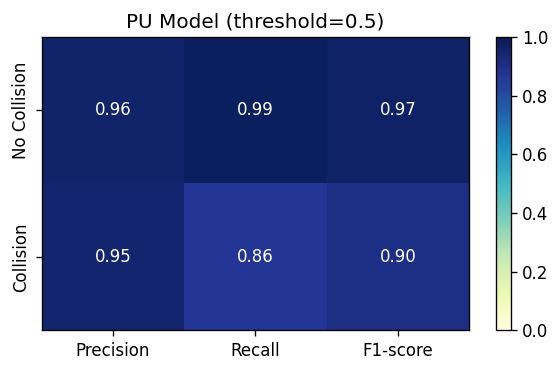

'\nmat_svm_hard = per_class_prf(y_lat.astype(int), svm_res["svm_hard"]["y_pred"])\nplot_prf_heatmap(mat_svm_hard, title="SVM Hard")\ny_pred_svm_prob = (svm_res["svm_prob"]["y_prob"] >= 0.5).astype(int)\nmat_svm_prob = per_class_prf(y_lat.astype(int), y_pred_svm_prob)\nplot_prf_heatmap(mat_svm_prob, title="SVM Prob (threshold=0.75)")\n'

In [56]:
mat_pu = per_class_prf(pu_res["y_true"], pu_res["y_pred"])
plot_prf_heatmap(mat_pu, title="PU Model (threshold=0.5)")
'''
mat_svm_hard = per_class_prf(y_lat.astype(int), svm_res["svm_hard"]["y_pred"])
plot_prf_heatmap(mat_svm_hard, title="SVM Hard")
y_pred_svm_prob = (svm_res["svm_prob"]["y_prob"] >= 0.5).astype(int)
mat_svm_prob = per_class_prf(y_lat.astype(int), y_pred_svm_prob)
plot_prf_heatmap(mat_svm_prob, title="SVM Prob (threshold=0.75)")
'''

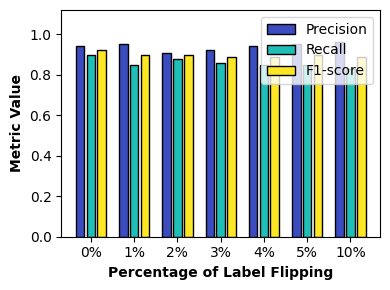

In [252]:
# Fill these with YOUR results (positive class / "Collision")
# Example numbers below are placeholders
results = {
    0:  {"precision": 0.94, "recall": 0.9, "f1": 0.92},
    1:  {"precision": 0.95, "recall": 0.85, "f1": 0.90},
    2:  {"precision": 0.91, "recall": 0.88, "f1": 0.90},
    3:  {"precision": 0.92, "recall": 0.86, "f1": 0.89},
    4:  {"precision": 0.94, "recall": 0.85, "f1": 0.89},
    5:  {"precision": 0.95, "recall": 0.85, "f1": 0.90},
    10: {"precision": 0.96, "recall": 0.83, "f1": 0.89},
}

noise_levels = sorted(results.keys())

precision = [results[n]["precision"] for n in noise_levels]
recall    = [results[n]["recall"]    for n in noise_levels]
f1        = [results[n]["f1"]        for n in noise_levels]

x = np.arange(len(noise_levels))

# ↓ these two control spacing INSIDE each group
bar_width = 0.2
offset    = 0.25   # offset > width ⇒ visible gap between bars

COLOR_PREC = "#3b4cc0"
COLOR_REC  = "#1fbfb8"
COLOR_F1   = "#fde725"

plt.figure(figsize=(4, 3))

plt.bar(x - offset, precision, width=bar_width,
        label="Precision", color=COLOR_PREC, edgecolor="black")
plt.bar(x, recall, width=bar_width,
        label="Recall", color=COLOR_REC, edgecolor="black")
plt.bar(x + offset, f1, width=bar_width,
        label="F1-score", color=COLOR_F1, edgecolor="black")

plt.xticks(x, [f"{n}%" for n in noise_levels])
plt.yticks([0,0.2,0.4,0.6,0.8,1])
plt.ylim(0, 1.12)


plt.xlabel("Percentage of Label Flipping", fontweight='bold')
plt.ylabel("Metric Value", fontweight='bold')
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

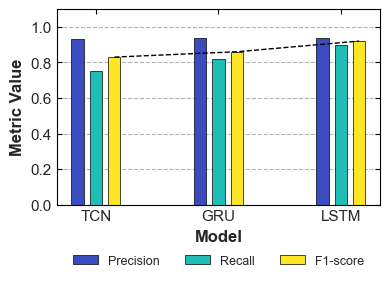

In [90]:
# Fill these with YOUR results (positive class / "Collision")
# Example numbers below are placeholders
results = {
    0:  {"precision": 0.93, "recall": 0.75, "f1": 0.83},
    1:  {"precision": 0.94, "recall": 0.82, "f1": 0.86},
    2:  {"precision": 0.94, "recall": 0.90, "f1": 0.92},
}

noise_levels = sorted(results.keys())

precision = [results[n]["precision"] for n in noise_levels]
recall    = [results[n]["recall"]    for n in noise_levels]
f1        = [results[n]["f1"]        for n in noise_levels]

x = np.arange(len(noise_levels))

# ↓ these two control spacing INSIDE each group
bar_width = 0.1
offset    = 0.15   # offset > width ⇒ visible gap between bars

COLOR_PREC = "#3b4cc0"
COLOR_REC  = "#1fbfb8"
COLOR_F1   = "#fde725"

plt.figure(figsize=(4, 3))

# 1. Draw the Bars
plt.bar(x - offset, precision, width=bar_width, label="Precision", color=COLOR_PREC, edgecolor="black", linewidth=0.5)
plt.bar(x, recall, width=bar_width, label="Recall", color=COLOR_REC, edgecolor="black", linewidth=0.5)
plt.bar(x + offset, f1, width=bar_width, label="F1-score", color=COLOR_F1, edgecolor="black", linewidth=0.5)

# 2. Add the Trend Line for F1-score
# We use 'x + offset' because that is the horizontal center of the F1 bars
plt.plot(x + offset, f1, color="black", markersize=4,
         linewidth=1, label="_nolegend_", linestyle='--')

# --- BOUNDING BOX AND TICKS ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')


ax.tick_params(direction='in', top=True, right=True,left=True, color='black')

# --- GRID (Horizontal Only) ---
ax.grid(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='gray')
ax.xaxis.grid(False)

# Labels and Ticks
plt.xticks(x, ["TCN", "GRU", "LSTM"])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.ylim(0, 1.1) # Increased to fit the legend and trend line

plt.xlabel("Model", fontweight='bold')
plt.ylabel("Metric Value", fontweight='bold')

# Updated Legend to include the Trend Line
plt.legend(
    prop={'size': 9},
    loc='upper center',
    bbox_to_anchor=(0.5, -0.2),
    ncol=3, # Adjusted to 2 columns so it fits nicely
    frameon=False
)

plt.tight_layout()
plt.show()

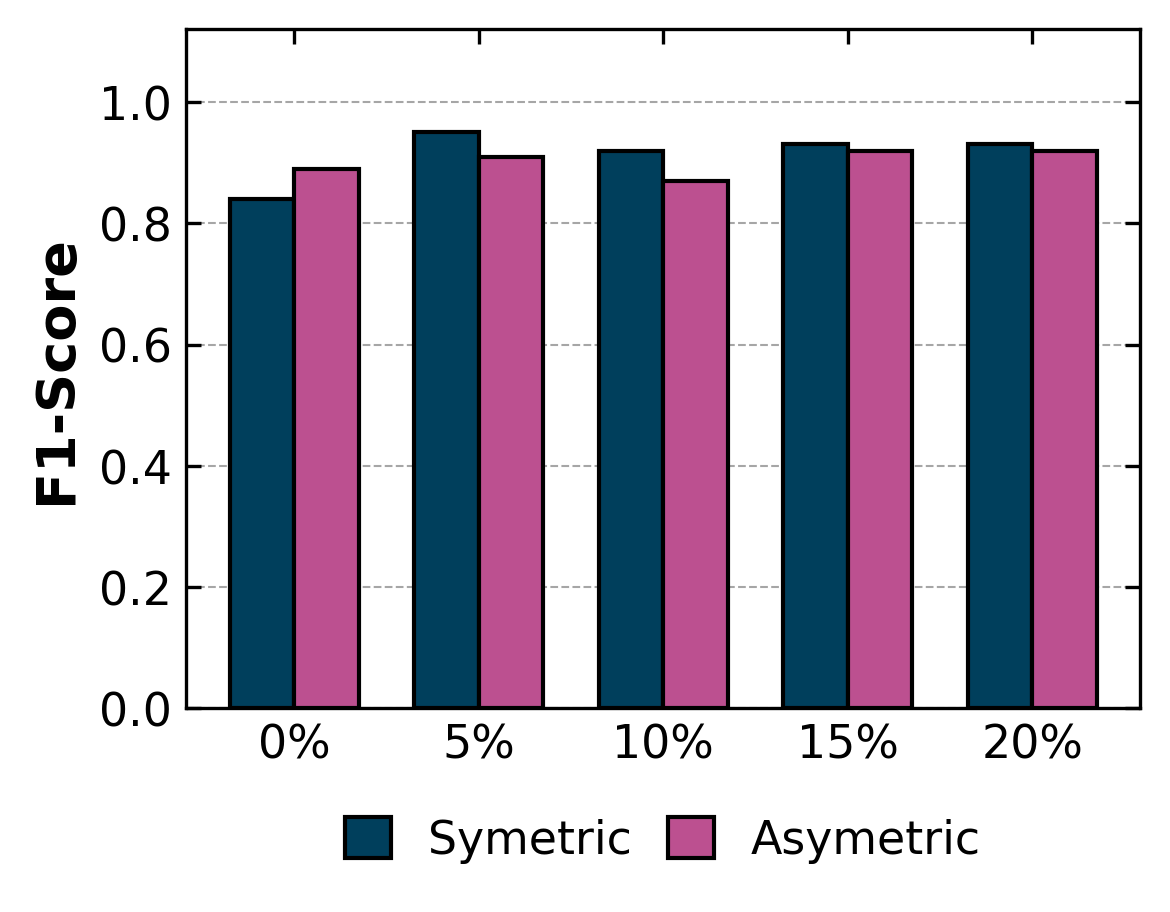

In [13]:
# Fill these with YOUR results (positive class / "Collision")
# Example numbers below are placeholders
results = {
    0: {"TF-WBCE": 0.895, "TF-Focal": 0.906, "TF-nnPU": 0.902,},
    5: {"TF-WBCE": 0.895, "TF-Focal": 0.906, "TF-nnPU": 0.902,},
    10: {"TF-WBCE": 0.895, "TF-Focal": 0.906, "TF-nnPU": 0.902,},
    15: {"TF-WBCE": 0.895, "TF-Focal": 0.906, "TF-nnPU": 0.902,},
    20: {"TF-WBCE": 0.895, "TF-Focal": 0.906, "TF-nnPU": 0.902,},
}
  TF-WBCE          0.895  0.903  0.881  0.836  0.797
  TF-Focal         0.906  0.904  0.863  0.805  0.731
  TF-nnPU          0.902  0.879  0.869  0.873  0.816
noise_levels = sorted(results.keys())
wbce = [results[n]["TF-WBCE"] for n in noise_levels]
focal    = [results[n]["TF-Focal"]    for n in noise_levels]
nnpu        = [results[n]["TF-nnPU"]        for n in noise_levels]

x = np.arange(len(noise_levels))

bar_width = 0.35
offset    = 0.35

COLOR_PREC = "#003f5c"  # strong blue
COLOR_REC  = "#58508d"  # strong green
COLOR_F1   =  "#bc5090" # strong red

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

bars1 = ax.bar(x - offset/2, precision, width=bar_width,
               label="Symetric", color=COLOR_PREC, edgecolor="black")

bars3 = ax.bar(x + offset/2,  f1,       width=bar_width,
               label="Asymetric",  color=COLOR_F1,   edgecolor="black")

ax.set_xticks(x)
ax.set_xticklabels(["0%", "5%","10%", "15%", "20%"])
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_ylim(0, 1.12)

ax.set_ylabel("F1-Score", fontsize=13, fontweight='bold')
ax.tick_params(axis='both', direction='in', top=True, right=True, labelsize=11)

x_positions = x  # your existing x = np.arange(len(noise_levels))

# Draw trend lines connecting the top of each bar across models
x_positions = x  # your existing x = np.arange(len(noise_levels))

# ── Value annotations on top of each bar ─────────────────────────────────────


ax.legend(
    prop={'size': 11},
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
    handlelength   = 1,
    handleheight   = 1,
    columnspacing  = 0.8,
    labelspacing   = 0.3,
    frameon=False
)
plt.subplots_adjust(bottom=0.6)
ax.spines[['top', 'right']].set_visible(True)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
ax.set_axisbelow(True)  # keeps grid behind the bars


plt.tight_layout()
plt.show()

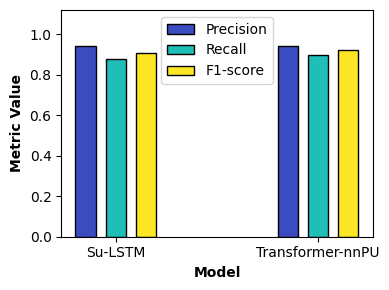

In [299]:
# Fill these with YOUR results (positive class / "Collision")
# Example numbers below are placeholders
results = {
    0:  {"precision": 0.94, "recall": 0.88, "f1": 0.91},
    1:  {"precision": 0.94, "recall": 0.90, "f1": 0.92},
}

noise_levels = sorted(results.keys())

precision = [results[n]["precision"] for n in noise_levels]
recall    = [results[n]["recall"]    for n in noise_levels]
f1        = [results[n]["f1"]        for n in noise_levels]

x = np.arange(len(noise_levels))

# ↓ these two control spacing INSIDE each group
bar_width = 0.1
offset    = 0.15   # offset > width ⇒ visible gap between bars

COLOR_PREC = "#3b4cc0"
COLOR_REC  = "#1fbfb8"
COLOR_F1   = "#fde725"

plt.figure(figsize=(4, 3))

plt.bar(x - offset, precision, width=bar_width,
        label="Precision", color=COLOR_PREC, edgecolor="black")
plt.bar(x, recall, width=bar_width,
        label="Recall", color=COLOR_REC, edgecolor="black")
plt.bar(x + offset, f1, width=bar_width,
        label="F1-score", color=COLOR_F1, edgecolor="black")

plt.xticks(x, ["Su-LSTM", "Transformer-nnPU"])
plt.yticks([0,0.2,0.4,0.6,0.8,1])
plt.ylim(0, 1.12)


plt.xlabel("Model", fontweight='bold')
plt.ylabel("Metric Value", fontweight='bold')
plt.legend(loc="upper center")
plt.grid(False)

plt.tight_layout()
plt.show()

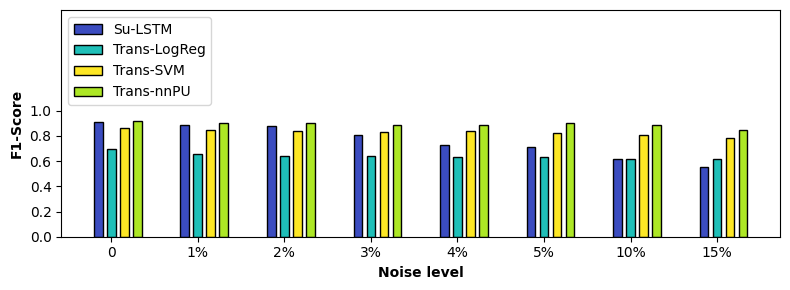

In [7]:
# Fill these with YOUR results (positive class / "Collision")
# Example numbers below are placeholders
results = {
    0:  {"Su-LSTM": 0.91, "LogReg": 0.70, "SVM": 0.86, "nnPU":0.92},
    1:  {"Su-LSTM": 0.89, "LogReg": 0.66, "SVM": 0.85, "nnPU":0.90},
    2:  {"Su-LSTM": 0.88, "LogReg": 0.64, "SVM": 0.84, "nnPU":0.90},
    3:  {"Su-LSTM": 0.81, "LogReg": 0.64, "SVM": 0.83, "nnPU":0.89},
    4:  {"Su-LSTM": 0.73, "LogReg": 0.63, "SVM": 0.84, "nnPU":0.89},
    5:  {"Su-LSTM": 0.71, "LogReg": 0.63, "SVM": 0.82, "nnPU":0.90},
    10:  {"Su-LSTM": 0.62, "LogReg": 0.62, "SVM": 0.81, "nnPU":0.89},
    15:  {"Su-LSTM": 0.55, "LogReg": 0.62, "SVM": 0.78, "nnPU":0.85}
}

noise_levels = sorted(results.keys())

LSTM = [results[n]["Su-LSTM"] for n in noise_levels]
LogReg    = [results[n]["LogReg"]    for n in noise_levels]
SVM        = [results[n]["SVM"]        for n in noise_levels]
nnPU        = [results[n]["nnPU"]        for n in noise_levels]

x = np.arange(len(noise_levels))

# ↓ these two control spacing INSIDE each group
bar_width = 0.1
offset    = 0.15   # offset > width ⇒ visible gap between bars

COLOR_LSTM = "#3b4cc0"
COLOR_LogReg  = "#1fbfb8"
COLOR_SVM   = "#fde725"
COLOR_nnPU   = "#ade725"

plt.figure(figsize=(8, 3))

plt.bar(x - offset, LSTM, width=bar_width,
        label="Su-LSTM", color=COLOR_LSTM, edgecolor="black")
plt.bar(x, LogReg, width=bar_width,
        label="Trans-LogReg", color=COLOR_LogReg, edgecolor="black")
plt.bar(x + offset, SVM, width=bar_width,
        label="Trans-SVM", color=COLOR_SVM, edgecolor="black")
plt.bar(x + 2*offset, nnPU, width=bar_width,
        label="Trans-nnPU", color=COLOR_nnPU, edgecolor="black")

plt.xticks(x, ["0", "1%", "2%", "3%", "4%", "5%", "10%", "15%"])
plt.yticks([0,0.2,0.4,0.6,0.8,1])
plt.ylim(0, 1.8)


plt.xlabel("Noise level", fontweight='bold')
plt.ylabel("F1-Score", fontweight='bold')
plt.legend()
plt.legend(loc="upper left")
plt.grid(False)

plt.tight_layout()
plt.show()

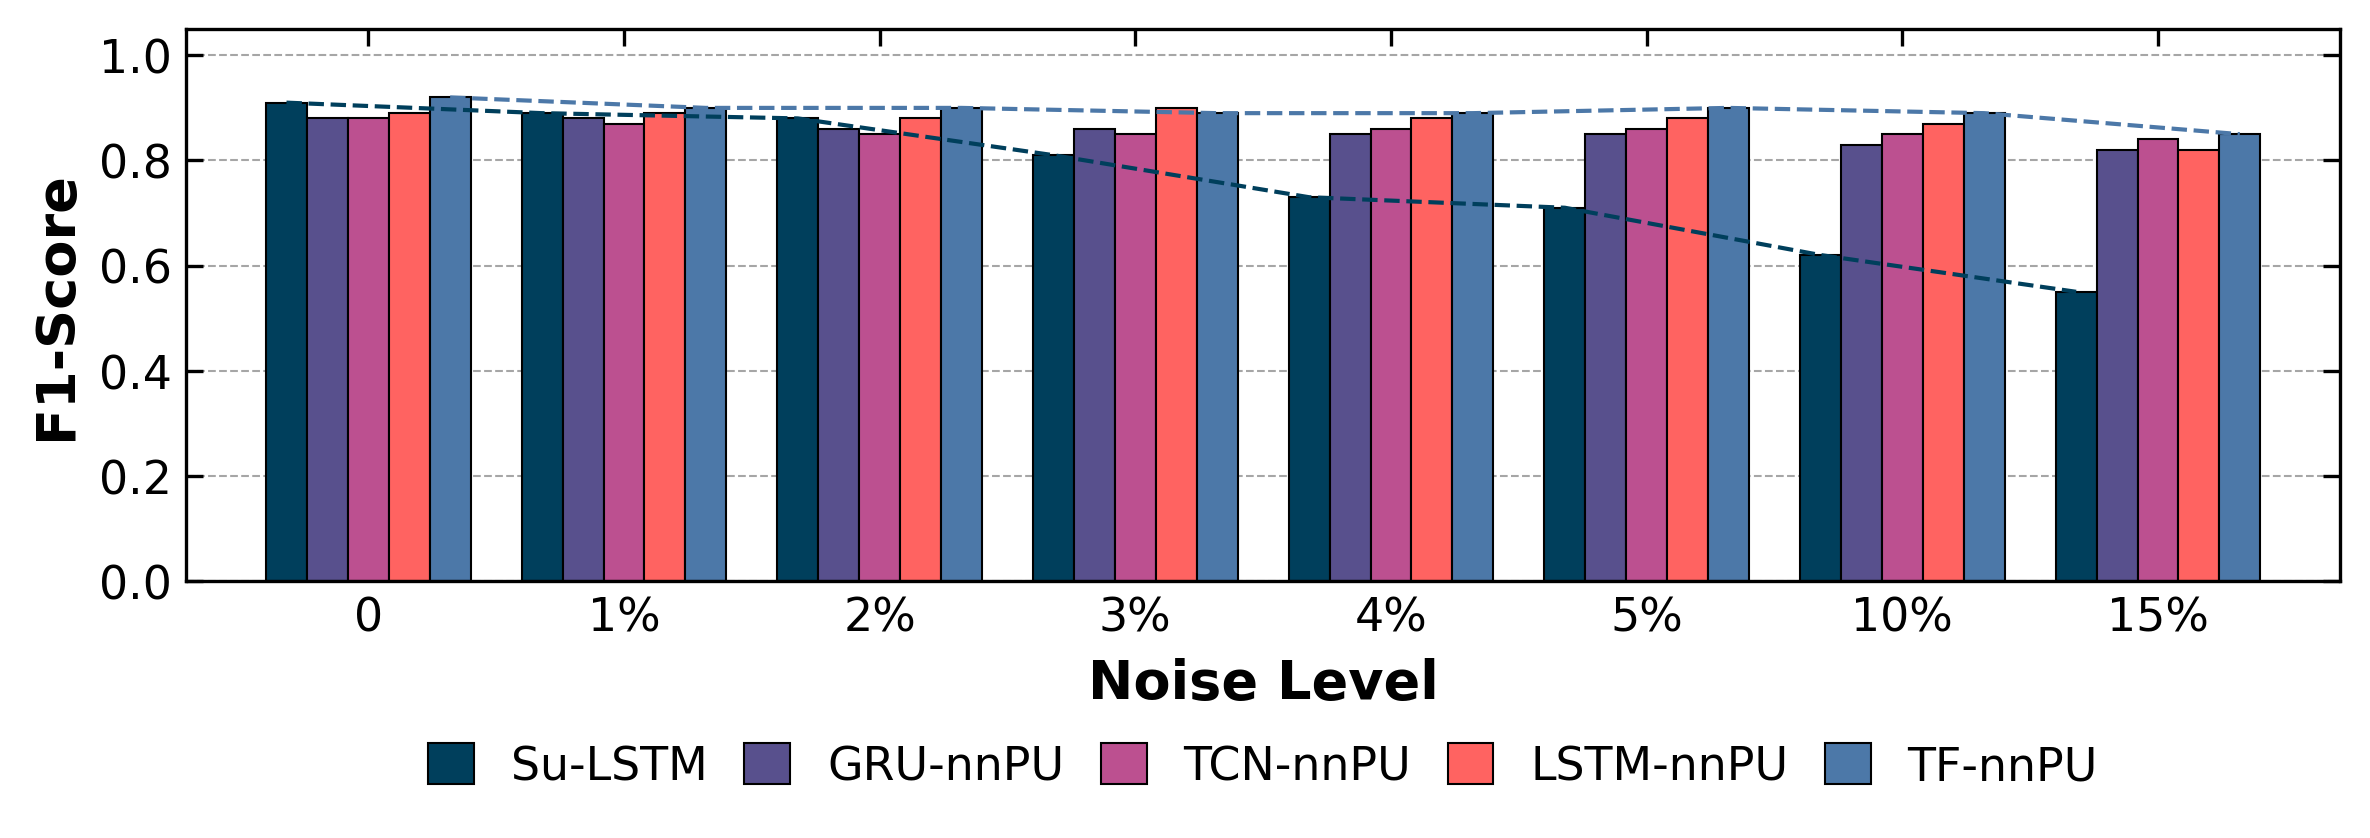

In [274]:
results = {
    0:  {"Su-LSTM": 0.91, "GRU-nnPU": 0.88, "TCN-nnPU": 0.88, "LSTM-nnPU": 0.89, "T-nnPU": 0.92},
    1:  {"Su-LSTM": 0.89, "GRU-nnPU": 0.88, "TCN-nnPU": 0.87, "LSTM-nnPU": 0.89, "T-nnPU": 0.90},
    2:  {"Su-LSTM": 0.88, "GRU-nnPU": 0.86, "TCN-nnPU": 0.85, "LSTM-nnPU": 0.88, "T-nnPU": 0.90},
    3:  {"Su-LSTM": 0.81, "GRU-nnPU": 0.86, "TCN-nnPU": 0.85, "LSTM-nnPU": 0.90, "T-nnPU": 0.89},
    4:  {"Su-LSTM": 0.73, "GRU-nnPU": 0.85, "TCN-nnPU": 0.86, "LSTM-nnPU": 0.88, "T-nnPU": 0.89},
    5:  {"Su-LSTM": 0.71, "GRU-nnPU": 0.85, "TCN-nnPU": 0.86, "LSTM-nnPU": 0.88, "T-nnPU": 0.90},
    10: {"Su-LSTM": 0.62, "GRU-nnPU": 0.83, "TCN-nnPU": 0.85, "LSTM-nnPU": 0.87, "T-nnPU": 0.89},
    15: {"Su-LSTM": 0.55, "GRU-nnPU": 0.82, "TCN-nnPU": 0.84, "LSTM-nnPU": 0.82, "T-nnPU": 0.85},
}

noise_levels = sorted(results.keys())

LSTM     = [results[n]["Su-LSTM"]   for n in noise_levels]
GRUnnPU  = [results[n]["GRU-nnPU"]  for n in noise_levels]
TCNnnPU  = [results[n]["TCN-nnPU"]  for n in noise_levels]
LSTMnnPU = [results[n]["LSTM-nnPU"] for n in noise_levels]
TnnPU    = [results[n]["T-nnPU"]    for n in noise_levels]

x = np.arange(len(noise_levels))

# Narrower bars and centered offsets
bar_width = 0.16
offsets = np.array([-2, -1, 0, 1, 2]) * bar_width

COLOR_LSTM    = "#003f5c"
COLOR_GRUnnPU = "#58508d"
COLOR_TCNnnPU = "#bc5090"
COLOR_LSTMnnPU= "#ff6361"
COLOR_TnnPU   = "#4C78A8"

fig, ax = plt.subplots(figsize=(8, 3), dpi=300)

# Bars
ax.bar(x + offsets[0], LSTM,     width=bar_width, label="Su-LSTM",
       color=COLOR_LSTM, edgecolor="black", linewidth=0.5)
ax.bar(x + offsets[1], GRUnnPU,  width=bar_width, label="GRU-nnPU",
       color=COLOR_GRUnnPU, edgecolor="black", linewidth=0.5)
ax.bar(x + offsets[2], TCNnnPU,  width=bar_width, label="TCN-nnPU",
       color=COLOR_TCNnnPU, edgecolor="black", linewidth=0.5)
ax.bar(x + offsets[3], LSTMnnPU, width=bar_width, label="LSTM-nnPU",
       color=COLOR_LSTMnnPU, edgecolor="black", linewidth=0.5)
ax.bar(x + offsets[4], TnnPU,    width=bar_width, label="TF-nnPU",
       color=COLOR_TnnPU, edgecolor="black", linewidth=0.5)

# Trend lines: thinner, no markers to reduce clutter
ax.plot(x + offsets[0], LSTM,     color=COLOR_LSTM,    linewidth=1.0, linestyle='--', zorder=5)
ax.plot(x + offsets[4], TnnPU,    color=COLOR_TnnPU,   linewidth=1.0, linestyle='--', zorder=5)

# Axes
ax.set_xticks(x)
ax.set_xticklabels(["0", "1%", "2%", "3%", "4%", "5%", "10%", "15%"])
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_ylim(0, 1.05)

ax.set_xlabel("Noise Level", fontsize=13, fontweight='bold')
ax.set_ylabel("F1-Score", fontsize=13, fontweight='bold')
ax.tick_params(axis='both', direction='in', top=True, right=True, labelsize=11)


# Add a bit of horizontal breathing room
ax.margins(x=0.04)

# Grid and spines
ax.spines[['top', 'right', 'left']].set_visible(True)
ax.grid(axis='y', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
ax.grid(axis='x', visible=False)
ax.set_axisbelow(True)

# Legend
ax.legend(
    prop={'size': 11},
    loc='upper center',
    bbox_to_anchor=(0.5, -0.22),
    ncol=5,
    handlelength   = 1,
    handleheight   = 1,
    columnspacing  = 0.8,
    labelspacing   = 0.3,
    frameon=False
)
# ── Show full frame (box) ───────────────────────────────────────────────
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_linewidth(0.8)
    ax.spines[spine].set_color('black')

# ── Tick marks (IMPORTANT) ──────────────────────────────────────────────
ax.tick_params(
    axis='both',
    which='both',
    direction='in',     # ticks go inward (IEEE style)
    top=True,
    right=True,
    left=True,
    length=4,           # length of tick lines
    width=0.8
)

plt.tight_layout()
plt.show()

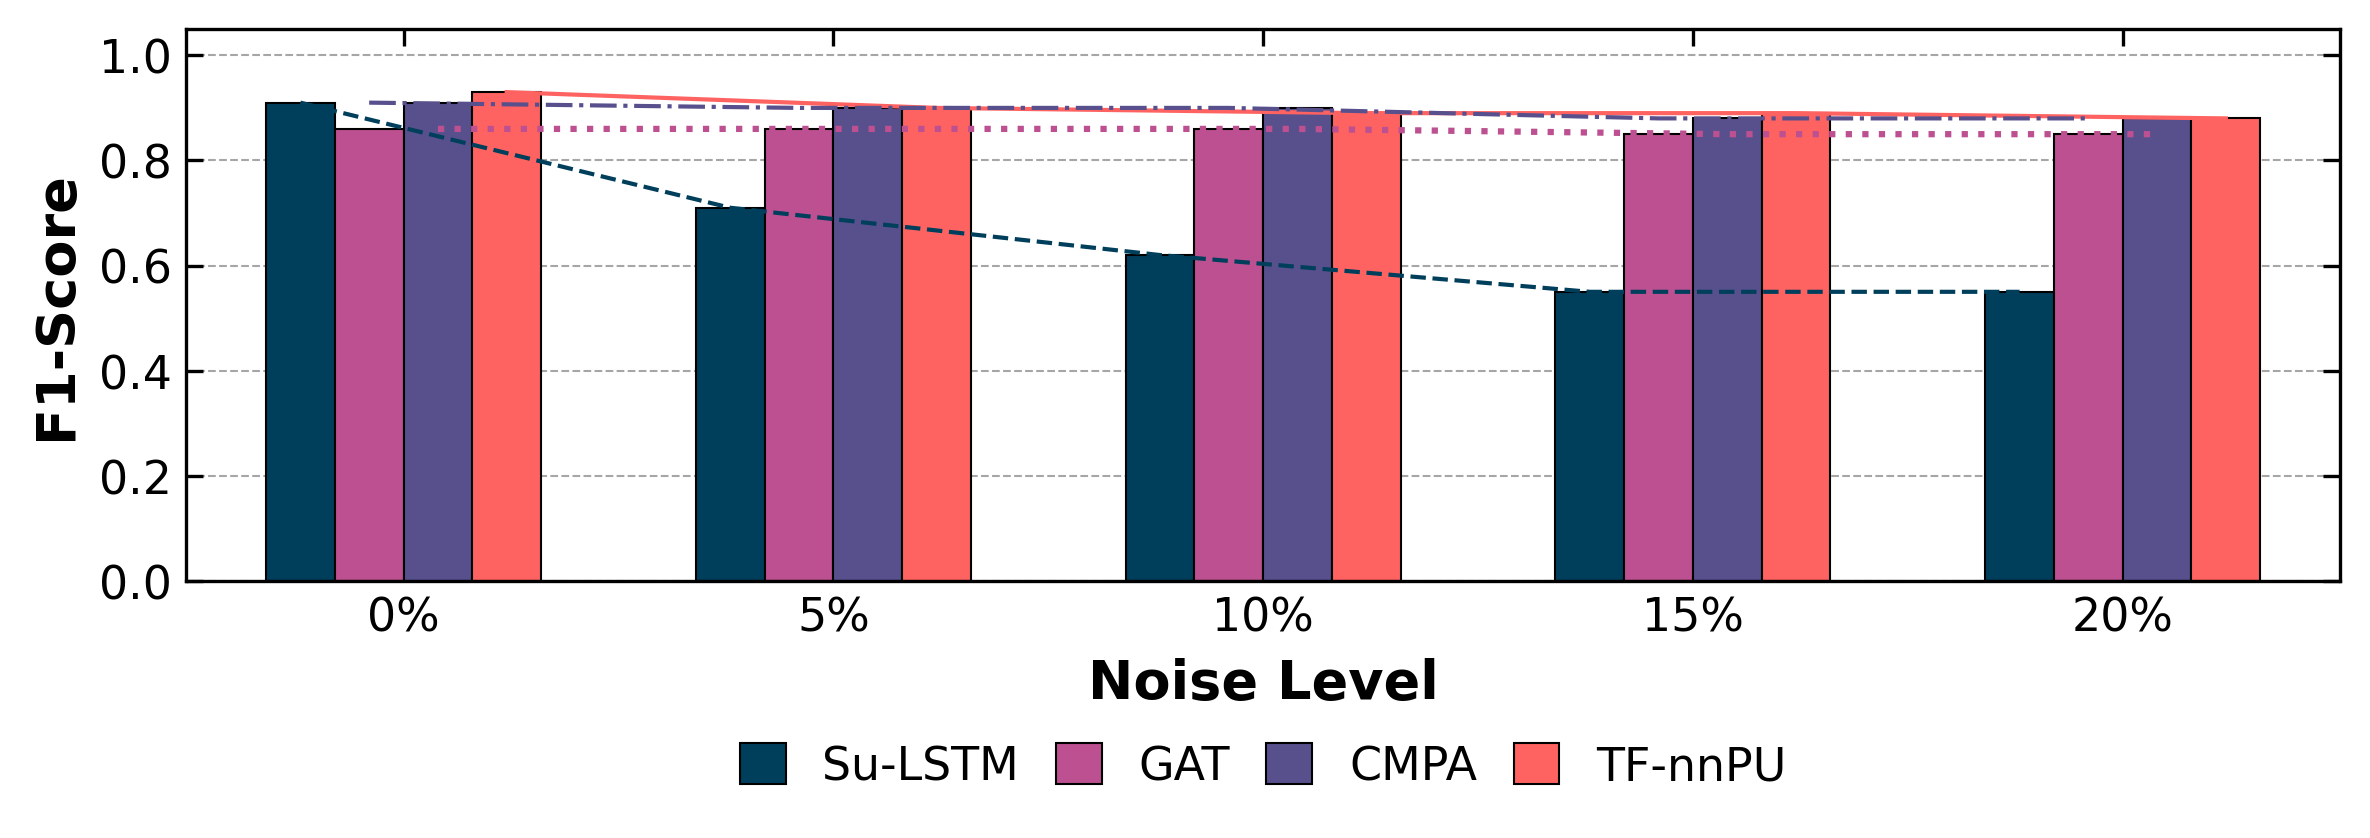

In [51]:
results = {
    0:  {"Su-LSTM": 0.91,  "GAT": 0.86, "CMPA": 0.91, "TF-nnPU": 0.93},
    5:  {"Su-LSTM": 0.71,  "GAT": 0.86, "CMPA": 0.90, "TF-nnPU": 0.90},
    10: {"Su-LSTM": 0.62,  "GAT": 0.86, "CMPA": 0.90, "TF-nnPU": 0.89},
    15: {"Su-LSTM": 0.55,  "GAT": 0.85, "CMPA": 0.88, "TF-nnPU": 0.89},
    20: {"Su-LSTM": 0.55,  "GAT": 0.85, "CMPA": 0.88, "TF-nnPU": 0.88},
}

noise_levels = sorted(results.keys())

LSTM     = [results[n]["Su-LSTM"]   for n in noise_levels]
CMPA  = [results[n]["CMPA"]  for n in noise_levels]
GAT  = [results[n]["GAT"]  for n in noise_levels]
TnnPU    = [results[n]["TF-nnPU"]    for n in noise_levels]

x = np.arange(len(noise_levels))

# Narrower bars and centered offsets
bar_width = 0.16
offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * bar_width

COLOR_LSTM    = "#003f5c"
COLOR_CMPA = "#58508d"
COLOR_GAT = "#bc5090"
COLOR_TnnPU= "#ff6361"

fig, ax = plt.subplots(figsize=(8, 3), dpi=300)

# Bars
ax.bar(x + offsets[0], LSTM,     width=bar_width, label="Su-LSTM",
       color=COLOR_LSTM, edgecolor="black", linewidth=0.5)
ax.bar(x + offsets[1], GAT,  width=bar_width, label="GAT",
       color=COLOR_GAT, edgecolor="black", linewidth=0.5)
ax.bar(x + offsets[2], CMPA,  width=bar_width, label="CMPA",
       color=COLOR_CMPA, edgecolor="black", linewidth=0.5)
ax.bar(x + offsets[3], TnnPU,    width=bar_width, label="TF-nnPU",
       color=COLOR_TnnPU, edgecolor="black", linewidth=0.5)

# Trend lines: thinner, no markers to reduce clutter
ax.plot(x + offsets[0], LSTM,     color=COLOR_LSTM,    linewidth=1.0, linestyle='--', zorder=5)
ax.plot(x + offsets[3], TnnPU,    color=COLOR_TnnPU,   linewidth=1.0, linestyle='-', zorder=5)
ax.plot(x + offsets[1], CMPA,     color=COLOR_CMPA,    linewidth=1.0, linestyle='-.', zorder=5)
ax.plot(x + offsets[2], GAT,    color=COLOR_GAT,   linewidth=1.5, linestyle=':', zorder=5)

# Axes
ax.set_xticks(x)
ax.set_xticklabels(["0%","5%", "10%", "15%", "20%"])
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_ylim(0, 1.05)

ax.set_xlabel("Noise Level", fontsize=13, fontweight='bold')
ax.set_ylabel("F1-Score", fontsize=13, fontweight='bold')
ax.tick_params(axis='both', direction='in', top=True, right=True, labelsize=11)


# Add a bit of horizontal breathing room
ax.margins(x=0.04)

# Grid and spines
ax.spines[['top', 'right', 'left']].set_visible(True)
ax.grid(axis='y', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
ax.grid(axis='x', visible=False)
ax.set_axisbelow(True)

# Legend
ax.legend(
    prop={'size': 11},
    loc='upper center',
    bbox_to_anchor=(0.5, -0.22),
    ncol=5,
    handlelength   = 1,
    handleheight   = 1,
    columnspacing  = 0.8,
    labelspacing   = 0.3,
    frameon=False
)
# ── Show full frame (box) ───────────────────────────────────────────────
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_linewidth(0.8)
    ax.spines[spine].set_color('black')

# ── Tick marks (IMPORTANT) ──────────────────────────────────────────────
ax.tick_params(
    axis='both',
    which='both',
    direction='in',     # ticks go inward (IEEE style)
    top=True,
    right=True,
    left=True,
    length=4,           # length of tick lines
    width=0.8
)

plt.tight_layout()
plt.show()

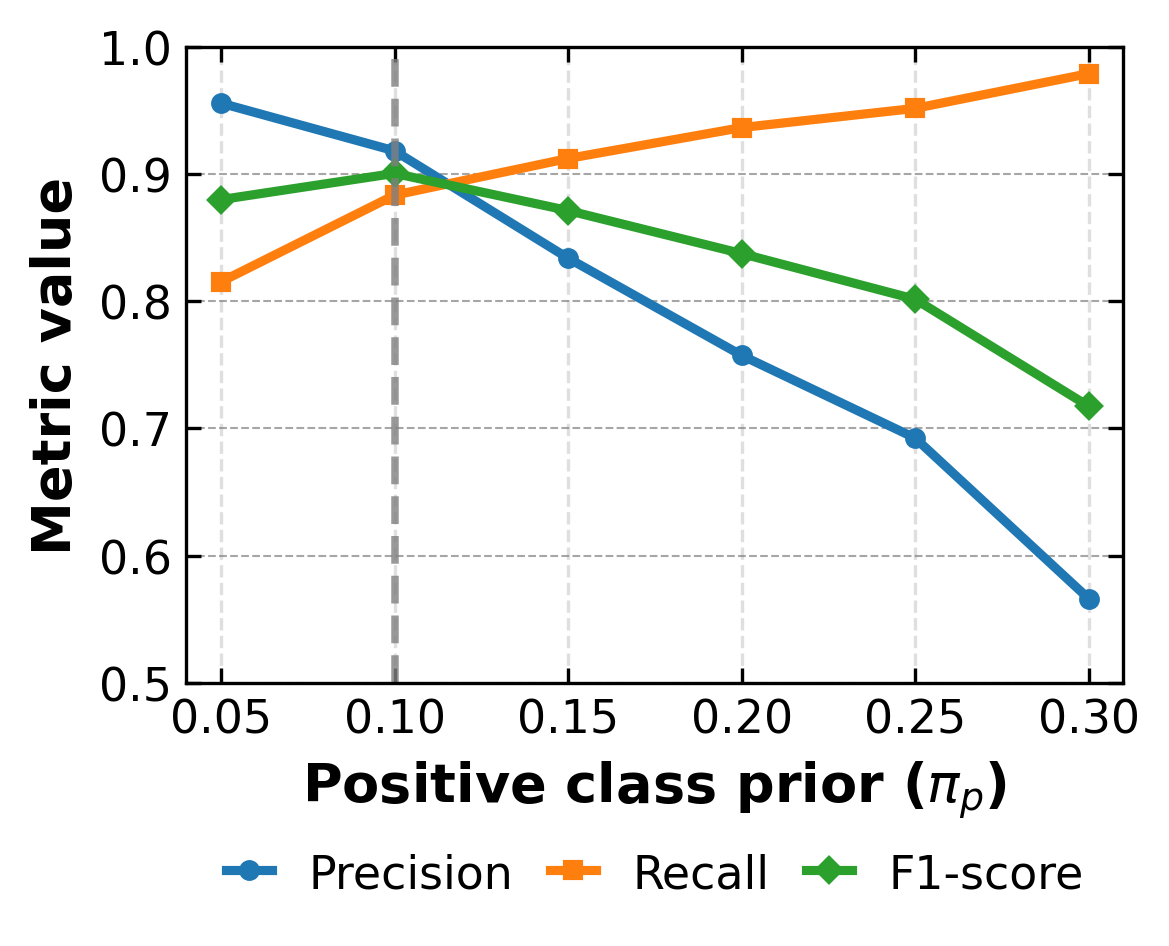

In [298]:
# Data
pi_p = np.array([0.05, 0.10, 0.15, 0.20, 0.25, 0.30])
precision = np.array([0.9556, 0.9181, 0.8338, 0.7574, 0.6924, 0.5662])
recall = np.array([0.8152, 0.8833, 0.9121, 0.9364, 0.9515, 0.9788])
f1_score = np.array([0.8798, 0.9004, 0.8712, 0.8374, 0.8015, 0.7174])

selected_pi = 0.10

# Figure
fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

# Curves
ax.plot(
    pi_p, precision,
    marker='o',
    linewidth=2.2,
    markersize=4,
    label='Precision'
)

ax.plot(
    pi_p, recall,
    marker='s',
    linewidth=2.2,
    markersize=4,
    label='Recall'
)

ax.plot(
    pi_p, f1_score,
    marker='D',
    linewidth=2.2,
    markersize=4,
    label='F1-score'
)

# Selected prior vertical line
ax.axvline(
    selected_pi,
    linestyle='--',
    linewidth=1.8,
    color='gray',
    alpha=0.8,
)

# Labels
ax.set_xlabel(r'Positive class prior ($\pi_p$)', fontsize=13, fontweight='bold')
ax.set_ylabel('Metric value', fontsize=13, fontweight='bold')

# Axes limits and ticks
ax.set_xlim(0.04, 0.31)
ax.set_ylim(0.50, 1.00)
ax.set_xticks(pi_p)
ax.set_yticks(np.arange(0.5, 1.01, 0.1))

# Grid and style
ax.grid(True, linestyle='--', linewidth=0.8, alpha=0.4)
ax.tick_params(axis='both', labelsize=11, direction='in', top=True, right=True)

#for spine in ax.spines.values():
#    spine.set_linewidth(1)

ax.legend(
    prop={'size': 11},
    loc='upper center',
    bbox_to_anchor=(0.5, -0.2),
    ncol=3,
    handlelength   = 1,
    handleheight   = 1,
    columnspacing  = 0.8,
    labelspacing   = 0.3,
    frameon=False
)
plt.subplots_adjust(bottom=0.6)
ax.spines[['top', 'right']].set_visible(True)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
ax.set_axisbelow(True)  # keeps grid behind the bars

plt.tight_layout()


plt.show()

C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
C:\Users\l_daryel\AppData\Local\Temp\ipykernel_12320\1345900873.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend 

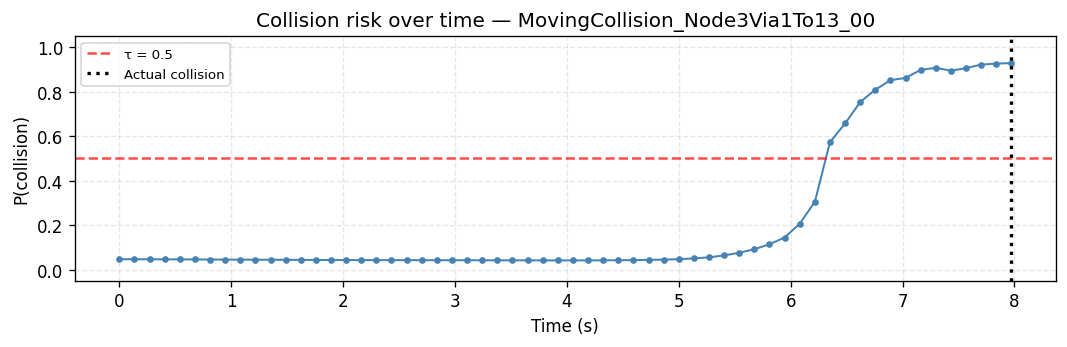

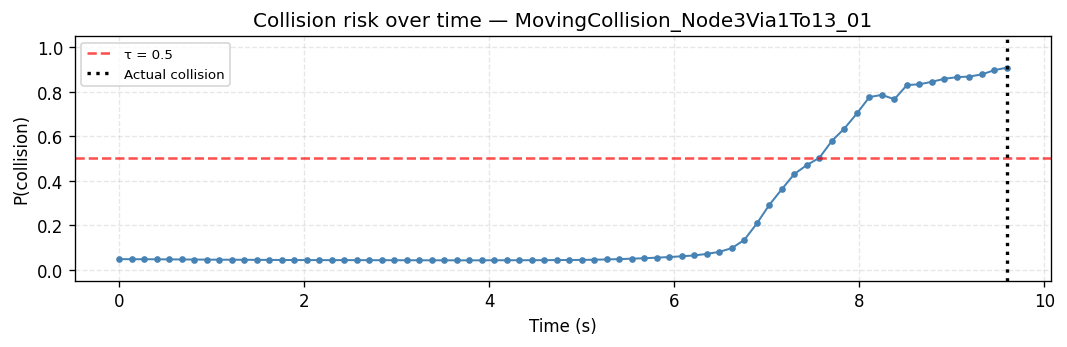

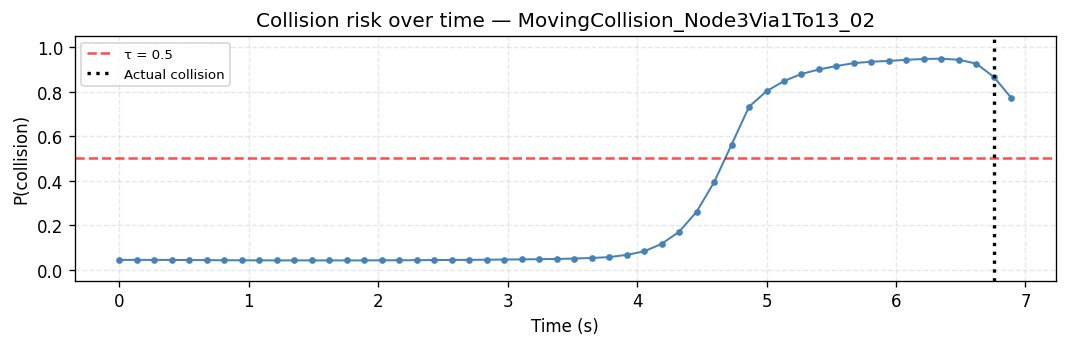

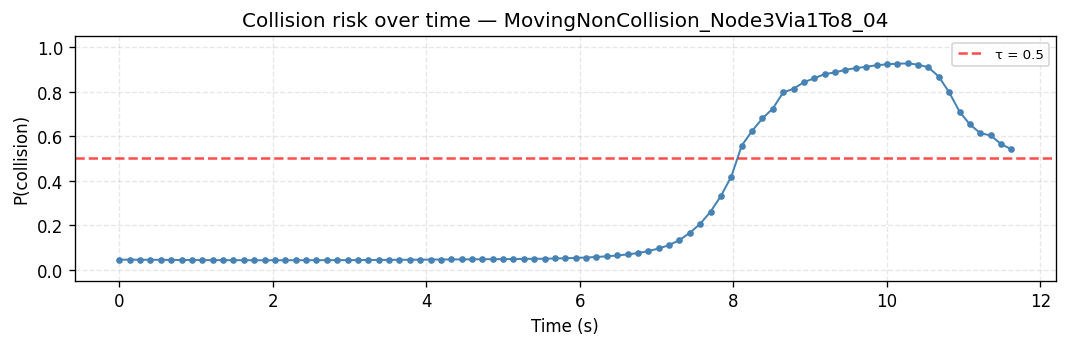

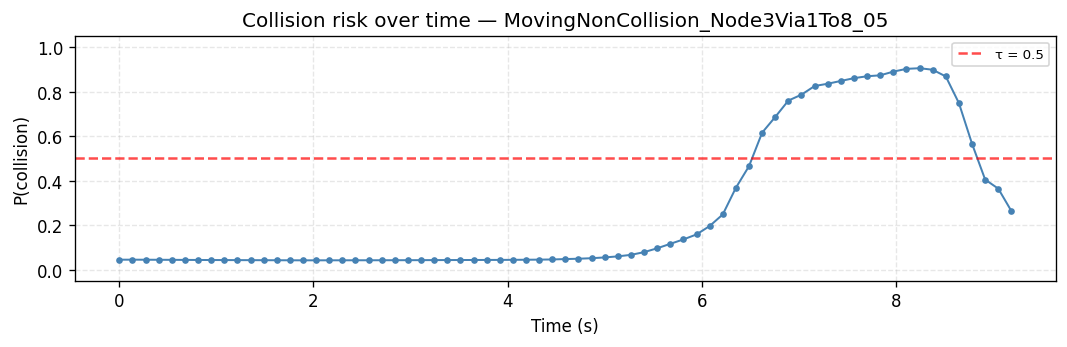

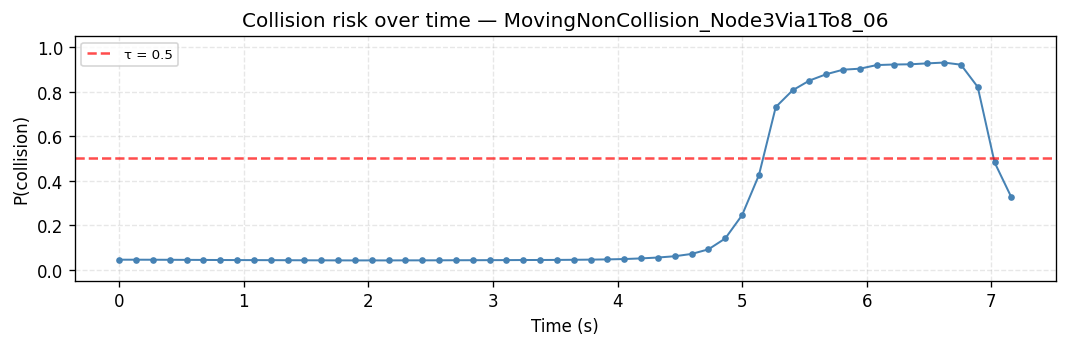

In [18]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Reload the trained model (works whether clf_model is still in memory
# from training above, or this cell is run fresh in a new session)
# ------------------------------------------------------------------
encoder_eval = TemporalEncoder(
    input_dim=5, d_model=64, nhead=4, num_layers=2,
    dim_feedforward=128, dropout=0.1, max_len=500,
)
eval_model = TemporalRiskTransformer(encoder_eval).to(device)
eval_model.load_state_dict(torch.load("stage2_trained_model.pt", map_location=device))
eval_model.eval()

# ------------------------------------------------------------------
# Bounded sliding-window inference — the model was ONLY ever trained on
# 15-frame sequences (verified: every sequence in safe_col_mix.txt is
# exactly 15 frames). Your physical scenarios run 70-330+ frames, so we
# cap the look-back window to stay in-distribution instead of feeding
# an ever-growing prefix.
# ------------------------------------------------------------------
WINDOW = 15
fps = 7.4

def running_risk(X_seq, model, device, window=WINDOW):
    T = X_seq.shape[0]
    probs = []
    for t in range(1, T + 1):
        lo = max(0, t - window)
        X_t = X_seq[lo:t].unsqueeze(0).to(device)
        pad_mask = torch.zeros(1, X_t.shape[1], dtype=torch.bool, device=device)
        with torch.no_grad():
            logits, _ = model(X_t, pad_mask)
            probs.append(torch.sigmoid(logits).item())
    return probs

# ------------------------------------------------------------------
# Load each physical scenario (7.4fps resampled) + its collision ground truth
# ------------------------------------------------------------------
journal_dir = r"C:\Users\l_daryel\Desktop\Journal 1 physical test"
physical_dir = os.path.join(journal_dir, "features_txt_7p4fps")

scenario_names = [
    "MovingCollision_Node3Via1To13_00",
    "MovingCollision_Node3Via1To13_01",
    "MovingCollision_Node3Via1To13_02",
    "MovingNonCollision_Node3Via1To8_04",
    "MovingNonCollision_Node3Via1To8_05",
    "MovingNonCollision_Node3Via1To8_06",
]

for scenario_name in scenario_names:
    txt_path = os.path.join(physical_dir, f"{scenario_name}.txt")
    if not os.path.exists(txt_path):
        print(f"skip {scenario_name}: {txt_path} not found")
        continue

    arr = np.loadtxt(txt_path)
    if arr.ndim == 1:
        arr = arr[None, :]
    X_seq = torch.tensor(arr[:, 1:6], dtype=torch.float32)  # distance, angle, sin_yaw, cos_yaw, speed

    probs = running_risk(X_seq, eval_model, device)
    t_axis = np.arange(len(probs)) / fps

    # ground-truth collision marker, translated to the 7.4fps re-indexed frame number
    t_collision = None
    meta_path = os.path.join(journal_dir, scenario_name, "metadata.json")
    map_path = os.path.join(physical_dir, f"{scenario_name}_frame_map.csv")
    if os.path.exists(meta_path) and os.path.exists(map_path):
        with open(meta_path) as fh:
            meta = json.load(fh)
        col_frame_idx = meta.get("collision_first_post_event_frame_index")
        if meta.get("scenario_collision") == 1 and col_frame_idx is not None:
            map_df = pd.read_csv(map_path)
            match = map_df[map_df["frame_idx"] >= col_frame_idx]
            if not match.empty:
                t_collision = match["new_frame_idx"].iloc[0] / fps

    fig, ax = plt.subplots(figsize=(9, 3), dpi=120)
    ax.plot(t_axis, probs, "-o", markersize=3, linewidth=1.2, color="steelblue")
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.7, label="τ = 0.5")
    if t_collision is not None:
        ax.axvline(t_collision, color="black", linestyle=":", linewidth=2, label="Actual collision")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("P(collision)")
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"Collision risk over time — {scenario_name}")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

In [56]:
import numpy as np
import pandas as pd
import json
import os
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# ------------------------------------------------------------------
# Build frame-level ground truth for each scenario, using metadata.json's
# confirmed collision frame (translated to 7.4fps re-indexed frame numbers,
# same mapping used for the "Actual collision" line in the risk plots)
# ------------------------------------------------------------------
def build_ground_truth(scenario_name):
    txt_path = os.path.join(physical_dir, f"{scenario_name}.txt")
    arr = np.loadtxt(txt_path)
    if arr.ndim == 1:
        arr = arr[None, :]
    T = arr.shape[0]
    y_true = np.zeros(T, dtype=int)

    meta_path = os.path.join(journal_dir, scenario_name, "metadata.json")
    map_path = os.path.join(physical_dir, f"{scenario_name}_frame_map.csv")
    if os.path.exists(meta_path) and os.path.exists(map_path):
        with open(meta_path) as fh:
            meta = json.load(fh)
        col_frame_idx = meta.get("collision_first_post_event_frame_index")
        if meta.get("scenario_collision") == 1 and col_frame_idx is not None:
            map_df = pd.read_csv(map_path)
            match = map_df[map_df["frame_idx"] >= col_frame_idx]
            if not match.empty:
                onset = int(match["new_frame_idx"].iloc[0])
                y_true[onset:] = 1  # post-collision frames

    return arr, y_true


# ------------------------------------------------------------------
# Run the model over every scenario, collect (y_true, y_prob) pooled across all frames
# ------------------------------------------------------------------
all_y_true = []
all_y_prob = []
per_scenario = {}

for scenario_name in scenario_names:
    txt_path = os.path.join(physical_dir, f"{scenario_name}.txt")
    if not os.path.exists(txt_path):
        continue

    arr, y_true = build_ground_truth(scenario_name)
    X_seq = torch.tensor(arr[:, 1:6], dtype=torch.float32)
    probs = np.array(running_risk(X_seq, eval_model, device))

    per_scenario[scenario_name] = {"y_true": y_true, "y_prob": probs}
    all_y_true.append(y_true)
    all_y_prob.append(probs)

all_y_true = np.concatenate(all_y_true)
all_y_prob = np.concatenate(all_y_prob)

In [57]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Reuses `per_scenario` built in the previous cell (y_true / y_prob per scenario, frame-aligned)

final_y_true = []
final_y_pred = []

print(f"{'Scenario':<38} {'Final P(collision)':>18}  {'Predicted':>10}  {'True':>6}  {'Match':>6}")
print("-" * 84)

for scenario_name, d in per_scenario.items():
    final_prob = d["y_prob"][-1]           # model's risk at the scenario's last recorded frame
    final_true = int(d["y_true"][-1])      # ground truth: was the last frame actually post-collision?
    final_pred = int(final_prob >= 0.5)

    final_y_true.append(final_true)
    final_y_pred.append(final_pred)

    match = "OK" if final_pred == final_true else "WRONG"
    print(f"{scenario_name:<38} {final_prob:>18.4f}  {final_pred:>10}  {final_true:>6}  {match:>6}")

final_y_true = np.array(final_y_true)
final_y_pred = np.array(final_y_pred)

p = precision_score(final_y_true, final_y_pred, zero_division=0)
r = recall_score(final_y_true, final_y_pred, zero_division=0)
f1 = f1_score(final_y_true, final_y_pred, zero_division=0)
tn, fp, fn, tp = confusion_matrix(final_y_true, final_y_pred, labels=[0, 1]).ravel()

print(f"\nSequence-level (n={len(final_y_true)} scenarios): Precision={p:.4f}, Recall={r:.4f}, F1={f1:.4f}")
print(f"TP={tp}  FP={fp}  FN={fn}  TN={tn}")

Scenario                               Final P(collision)   Predicted    True   Match
------------------------------------------------------------------------------------
MovingCollision_Node3Via1To13_00                   0.9281           1       1      OK
MovingCollision_Node3Via1To13_01                   0.9078           1       1      OK
MovingCollision_Node3Via1To13_02                   0.7712           1       1      OK
MovingNonCollision_Node3Via1To8_04                 0.5403           1       0   WRONG
MovingNonCollision_Node3Via1To8_05                 0.2630           0       0      OK
MovingNonCollision_Node3Via1To8_06                 0.3246           0       0      OK

Sequence-level (n=6 scenarios): Precision=0.7500, Recall=1.0000, F1=0.8571
TP=3  FP=1  FN=0  TN=2


# Reviewer 1 — Comment 5: Hyperparameter Sensitivity

This section **only adds** the hyperparameter-sensitivity experiments requested by Reviewer 1.  
The existing notebook logic, datasets, model classes, losses, training loops, and previous results are left unchanged.

The added analysis evaluates:

- Transformer depth: `num_layers ∈ {1, 2, 3}`
- Number of attention heads: `nhead ∈ {1, 2, 4, 8}`
- Maximum temporal context: `L ∈ {5, 10, 15}` frames
- Stage-2 learning rate: `lr ∈ {1e-5, 5e-5, 1e-4, 5e-4, 1e-3}`

The embedding dimension, PU prior, SAR threshold, and decision threshold are already analyzed elsewhere in the notebook/manuscript.

### Protocol

- The sensitivity code reuses the **same existing `train_loader` and `val_loader` datasets** already created by the notebook.
- The same nnPU loss, positive prior (`0.10`), AdamW weight decay, early stopping rule, batch sizes, and decision threshold (`0.5`) are retained.
- When Transformer depth or number of heads changes, Stage 1 is repeated using the **same Stage-1 training logic**, because the encoder architecture changes.
- For learning-rate and temporal-context sensitivity, the same baseline Stage-1 pretrained encoder (`pretrained_encoder.pt`) is reloaded before every run.
- Temporal-context sensitivity preserves every existing training/validation sample and only limits the amount of history visible to the model. For a context limit `L`, prefixes longer than `L` retain their most recent `L` observations; shorter prefixes are unchanged.


In [57]:
# ============================================================
# HYPERPARAMETER SENSITIVITY — HELPERS
# Adds experiments only; existing notebook logic is unchanged.
# ============================================================

import random
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
)

# Baseline values already used by the current notebook
SENS_SEED = 42
SENS_D_MODEL = 64
SENS_NHEAD = 4
SENS_NUM_LAYERS = 2
SENS_DIM_FF = 128
SENS_DROPOUT = 0.1
SENS_MAX_LEN = 500
SENS_POS_PRIOR = 0.10
SENS_BASE_LR = 1e-4
SENS_PRETRAINED_PATH = "pretrained_encoder.pt"
SENS_UNSUP_DATASET = unsup_ds

# Reuse the exact datasets currently attached to the notebook's
# baseline Stage-2 loaders. This avoids changing the existing split.
SENS_TRAIN_DATASET = train_loader.dataset
SENS_VAL_DATASET = val_loader.dataset

hyperparameter_sensitivity_results = []


def sens_set_seed(seed=SENS_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class SensitivityMaxContextDataset(Dataset):
    """
    Wrap an existing (X, y) dataset without changing its samples or labels.
    Only the available temporal history is limited.

    If len(X) > max_context, keep the most recent max_context frames.
    """
    def __init__(self, base_dataset, max_context):
        self.base_dataset = base_dataset
        self.max_context = int(max_context)

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        X, y = self.base_dataset[idx]

        if X.shape[0] > self.max_context:
            X = X[-self.max_context:]

        return X, y


def sens_evaluate(model, loader, threshold=0.5):
    """
    Same classifier evaluation principle as the existing notebook,
    with precision added for the reviewer-facing sensitivity table.
    """
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for X, y, pad_mask in loader:
            X = X.to(device)
            y = y.to(device)
            pad_mask = pad_mask.to(device)

            logits, _ = model(X, pad_mask=pad_mask)
            probs = torch.sigmoid(logits)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(y.cpu().numpy())

    y_prob = np.concatenate(all_probs, axis=0)
    y_true = np.concatenate(all_labels, axis=0).astype(int)
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def sens_pretrain_encoder(num_layers=2, nhead=4, run_label=""):
    """
    Repeat Stage 1 using the same logic already used by the notebook:
      TemporalEncoder -> TemporalAutoencoder
      AdamW
      MSE reconstruction loss
      existing unsup_loader
      existing ae_epochs / ae_lr / ae_weight_decay
    """
    sens_set_seed()

    encoder_sens = TemporalEncoder(
        input_dim=5,
        d_model=SENS_D_MODEL,
        nhead=nhead,
        num_layers=num_layers,
        dim_feedforward=SENS_DIM_FF,
        dropout=SENS_DROPOUT,
        max_len=SENS_MAX_LEN,
    )

    ae_sens = TemporalAutoencoder(encoder_sens).to(device)

    ae_optimizer_sens = torch.optim.AdamW(
        ae_sens.parameters(),
        lr=ae_lr,
        weight_decay=ae_weight_decay,
    )
    ae_criterion_sens = nn.MSELoss()

    print(f"  Stage 1 pretraining: {run_label}")

    for epoch in range(1, ae_epochs + 1):
        ae_sens.train()
        epoch_loss = 0.0

        for X, pad_mask in unsup_loader:
            X = X.to(device)
            pad_mask = pad_mask.to(device)

            X_hat = ae_sens(X, pad_mask=pad_mask)
            loss = ae_criterion_sens(X_hat, X)

            ae_optimizer_sens.zero_grad()
            loss.backward()
            ae_optimizer_sens.step()

            epoch_loss += loss.item()

        if epoch == 1 or epoch % 10 == 0 or epoch == ae_epochs:
            print(
                f"    [AE] Epoch {epoch}/{ae_epochs} - "
                f"MSE={epoch_loss / len(unsup_loader):.6f}"
            )

    # The classifier receives the pretrained encoder exactly as in Stage 2.
    return ae_sens.encoder

class SensitivityUnsupervisedMaxContextDataset(Dataset):
    """
    Stage-1 wrapper around the existing unsupervised trajectory dataset.

    It does not alter the underlying dataset. If a full trajectory is
    longer than max_context, only its most recent max_context observations
    are supplied to the autoencoder.
    """
    def __init__(self, base_dataset, max_context):
        self.base_dataset = base_dataset
        self.max_context = int(max_context)

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        X = self.base_dataset[idx]

        if X.shape[0] > self.max_context:
            X = X[-self.max_context:]

        return X

def sens_load_baseline_pretrained_encoder():
    """
    Fresh baseline encoder initialized from the same Stage-1 weights
    used by the current Stage-2 code.
    """
    encoder_sens = TemporalEncoder(
        input_dim=5,
        d_model=SENS_D_MODEL,
        nhead=SENS_NHEAD,
        num_layers=SENS_NUM_LAYERS,
        dim_feedforward=SENS_DIM_FF,
        dropout=SENS_DROPOUT,
        max_len=SENS_MAX_LEN,
    )

    encoder_sens.load_state_dict(
        torch.load(SENS_PRETRAINED_PATH, map_location="cpu")
    )

    return encoder_sens

def sens_pretrain_encoder(
    num_layers=2,
    nhead=4,
    run_label="",
    unsup_loader_sens=None,
):
    """
    Repeat Stage 1 FROM SCRATCH using the same baseline logic:
      TemporalEncoder -> TemporalAutoencoder
      AdamW
      MSE reconstruction loss
      ae_epochs / ae_lr / ae_weight_decay

    If unsup_loader_sens is None, the original unsup_loader is used.
    A custom loader is used only for temporal-context sensitivity so that
    the same maximum context is applied during Stage 1 and Stage 2.
    """
    sens_set_seed()

    if unsup_loader_sens is None:
        unsup_loader_sens = unsup_loader

    encoder_sens = TemporalEncoder(
        input_dim=5,
        d_model=SENS_D_MODEL,
        nhead=nhead,
        num_layers=num_layers,
        dim_feedforward=SENS_DIM_FF,
        dropout=SENS_DROPOUT,
        max_len=SENS_MAX_LEN,
    )

    ae_sens = TemporalAutoencoder(encoder_sens).to(device)

    ae_optimizer_sens = torch.optim.AdamW(
        ae_sens.parameters(),
        lr=ae_lr,
        weight_decay=ae_weight_decay,
    )
    ae_criterion_sens = nn.MSELoss()

    print(f"  Stage 1 pretraining FROM SCRATCH: {run_label}")

    for epoch in range(1, ae_epochs + 1):
        ae_sens.train()
        epoch_loss = 0.0

        for X, pad_mask in unsup_loader_sens:
            X = X.to(device)
            pad_mask = pad_mask.to(device)

            X_hat = ae_sens(X, pad_mask=pad_mask)
            loss = ae_criterion_sens(X_hat, X)

            ae_optimizer_sens.zero_grad()
            loss.backward()
            ae_optimizer_sens.step()

            epoch_loss += loss.item()

        if epoch == 1 or epoch % 10 == 0 or epoch == ae_epochs:
            print(
                f"    [AE] Epoch {epoch}/{ae_epochs} - "
                f"MSE={epoch_loss / len(unsup_loader_sens):.6f}"
            )

    # Return the freshly pretrained encoder exactly as required by Stage 2.
    return ae_sens.encoder

def sens_train_stage2(
    encoder_sens,
    train_loader_sens,
    val_loader_sens,
    lr,
    run_label="",
):
    """
    Stage 2 follows the existing notebook logic:
      - TemporalRiskTransformer
      - AdamW
      - nnPU loss with prior=0.10, gamma=1.0, beta=0.0
      - max 200 epochs (existing clf_epochs)
      - early stopping on validation F1
      - patience=8, min_delta=1e-3
      - threshold=0.5
    """
    sens_set_seed()

    clf_sens = TemporalRiskTransformer(
        encoder=encoder_sens
    ).to(device)

    optimizer_sens = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, clf_sens.parameters()),
        lr=lr,
        weight_decay=clf_weight_decay,
    )

    early_stopper_sens = EarlyStopping(
        patience=8,
        min_delta=1e-3,
        mode="max",
    )

    best_epoch_sens = None

    print(f"  Stage 2 nnPU fine-tuning: {run_label}")

    for epoch in range(1, clf_epochs + 1):
        clf_sens.train()
        epoch_loss = 0.0

        for X, y, pad_mask in train_loader_sens:
            X = X.to(device)
            y = y.to(device)
            pad_mask = pad_mask.to(device)

            logits, _ = clf_sens(X, pad_mask=pad_mask)

            loss = nnpu_loss(
                logits,
                y,
                prior=SENS_POS_PRIOR,
                gamma=1.0,
                beta=0.0,
            )

            optimizer_sens.zero_grad()
            loss.backward()
            optimizer_sens.step()

            epoch_loss += loss.item()

        metrics = sens_evaluate(clf_sens, val_loader_sens)

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"    [CLF] Epoch {epoch}/{clf_epochs} - "
                f"Loss={epoch_loss / len(train_loader_sens):.4f} - "
                f"P={metrics['precision']:.4f}, "
                f"R={metrics['recall']:.4f}, "
                f"F1={metrics['f1']:.4f}"
            )

        should_stop = early_stopper_sens.step(
            metrics["f1"],
            clf_sens
        )

        if metrics["f1"] == early_stopper_sens.best:
            best_epoch_sens = epoch

        if should_stop:
            print(
                f"    Early stopping at epoch {epoch}; "
                f"best F1={early_stopper_sens.best:.4f}"
            )
            break

    early_stopper_sens.restore_best_weights(clf_sens)
    final_metrics = sens_evaluate(clf_sens, val_loader_sens)

    n_params = sum(p.numel() for p in clf_sens.parameters())

    return clf_sens, final_metrics, best_epoch_sens, n_params


def sens_record(group, value, metrics, best_epoch, n_params):
    hyperparameter_sensitivity_results.append({
        "Hyperparameter": group,
        "Value": value,
        "Precision": metrics["precision"],
        "Recall": metrics["recall"],
        "F1": metrics["f1"],
        "AUC": metrics["auc"],
        "Accuracy": metrics["accuracy"],
        "Best epoch": best_epoch,
        "Parameters": n_params,
    })


In [44]:
# ============================================================
# A. TRANSFORMER DEPTH SENSITIVITY
# num_layers ∈ {1, 2, 3}
#
# Stage 1 is repeated because the encoder architecture changes.
# All other baseline hyperparameters are unchanged.
# ============================================================

DEPTH_VALUES = [1, 2, 3]

print("\n" + "=" * 70)
print("A. TRANSFORMER DEPTH SENSITIVITY")
print("=" * 70)

for num_layers_sens in DEPTH_VALUES:
    label = f"num_layers={num_layers_sens}"

    print("\n" + "-" * 70)
    print(label)
    print("-" * 70)

    encoder_sens = sens_pretrain_encoder(
        num_layers=num_layers_sens,
        nhead=SENS_NHEAD,
        run_label=label,
    )

    _, metrics, best_epoch, n_params = sens_train_stage2(
        encoder_sens=encoder_sens,
        train_loader_sens=train_loader,
        val_loader_sens=val_loader,
        lr=SENS_BASE_LR,
        run_label=label,
    )

    sens_record(
        "Transformer layers",
        num_layers_sens,
        metrics,
        best_epoch,
        n_params,
    )

    print(
        f"  RESULT | layers={num_layers_sens}: "
        f"P={metrics['precision']:.4f}, "
        f"R={metrics['recall']:.4f}, "
        f"F1={metrics['f1']:.4f}"
    )



A. TRANSFORMER DEPTH SENSITIVITY

----------------------------------------------------------------------
num_layers=1
----------------------------------------------------------------------
  Stage 1 pretraining: num_layers=1


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


    [AE] Epoch 1/20 - MSE=3.327991
    [AE] Epoch 10/20 - MSE=0.025356
    [AE] Epoch 20/20 - MSE=0.007226
  Stage 2 nnPU fine-tuning: num_layers=1
    [CLF] Epoch 1/200 - Loss=0.3738 - P=0.0000, R=0.0000, F1=0.0000
    [CLF] Epoch 10/200 - Loss=0.1000 - P=0.7910, R=0.8485, F1=0.8187
    [CLF] Epoch 20/200 - Loss=0.0863 - P=0.7559, R=0.9197, F1=0.8298
    [CLF] Epoch 30/200 - Loss=0.0811 - P=0.8278, R=0.9030, F1=0.8638
    [CLF] Epoch 40/200 - Loss=0.0794 - P=0.8646, R=0.8803, F1=0.8724
    [CLF] Epoch 50/200 - Loss=0.0720 - P=0.9545, R=0.8258, F1=0.8855
    Early stopping at epoch 57; best F1=0.9070
  RESULT | layers=1: P=0.9370, R=0.8788, F1=0.9070

----------------------------------------------------------------------
num_layers=2
----------------------------------------------------------------------
  Stage 1 pretraining: num_layers=2


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


    [AE] Epoch 1/20 - MSE=2.552606
    [AE] Epoch 10/20 - MSE=0.020426
    [AE] Epoch 20/20 - MSE=0.007049
  Stage 2 nnPU fine-tuning: num_layers=2
    [CLF] Epoch 1/200 - Loss=0.3600 - P=0.0000, R=0.0000, F1=0.0000
    [CLF] Epoch 10/200 - Loss=0.0881 - P=0.8679, R=0.8364, F1=0.8519
    [CLF] Epoch 20/200 - Loss=0.0832 - P=0.8997, R=0.8561, F1=0.8773
    [CLF] Epoch 30/200 - Loss=0.0732 - P=0.9075, R=0.8621, F1=0.8842
    [CLF] Epoch 40/200 - Loss=0.0727 - P=0.9597, R=0.8303, F1=0.8903
    Early stopping at epoch 45; best F1=0.9112
  RESULT | layers=2: P=0.9375, R=0.8864, F1=0.9112

----------------------------------------------------------------------
num_layers=3
----------------------------------------------------------------------
  Stage 1 pretraining: num_layers=3


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


    [AE] Epoch 1/20 - MSE=2.216120
    [AE] Epoch 10/20 - MSE=0.018118
    [AE] Epoch 20/20 - MSE=0.007073
  Stage 2 nnPU fine-tuning: num_layers=3
    [CLF] Epoch 1/200 - Loss=0.3482 - P=0.0000, R=0.0000, F1=0.0000
    [CLF] Epoch 10/200 - Loss=0.0883 - P=0.8365, R=0.8758, F1=0.8557
    [CLF] Epoch 20/200 - Loss=0.0791 - P=0.9175, R=0.8424, F1=0.8784
    [CLF] Epoch 30/200 - Loss=0.0715 - P=0.8963, R=0.8773, F1=0.8867
    Early stopping at epoch 35; best F1=0.8986
  RESULT | layers=3: P=0.8973, R=0.9000, F1=0.8986


In [45]:
# ============================================================
# B. ATTENTION-HEAD SENSITIVITY
# nhead ∈ {1, 2, 4, 8}
#
# d_model remains fixed at 64.
# Stage 1 is repeated because the attention configuration changes.
# ============================================================

HEAD_VALUES = [1, 2, 4, 8]

print("\n" + "=" * 70)
print("B. ATTENTION-HEAD SENSITIVITY")
print("=" * 70)

for nhead_sens in HEAD_VALUES:
    label = f"nhead={nhead_sens}"

    print("\n" + "-" * 70)
    print(label)
    print("-" * 70)

    encoder_sens = sens_pretrain_encoder(
        num_layers=SENS_NUM_LAYERS,
        nhead=nhead_sens,
        run_label=label,
    )

    _, metrics, best_epoch, n_params = sens_train_stage2(
        encoder_sens=encoder_sens,
        train_loader_sens=train_loader,
        val_loader_sens=val_loader,
        lr=SENS_BASE_LR,
        run_label=label,
    )

    sens_record(
        "Attention heads",
        nhead_sens,
        metrics,
        best_epoch,
        n_params,
    )

    print(
        f"  RESULT | heads={nhead_sens}: "
        f"P={metrics['precision']:.4f}, "
        f"R={metrics['recall']:.4f}, "
        f"F1={metrics['f1']:.4f}"
    )



B. ATTENTION-HEAD SENSITIVITY

----------------------------------------------------------------------
nhead=1
----------------------------------------------------------------------
  Stage 1 pretraining: nhead=1


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


    [AE] Epoch 1/20 - MSE=2.560614
    [AE] Epoch 10/20 - MSE=0.019310
    [AE] Epoch 20/20 - MSE=0.007016
  Stage 2 nnPU fine-tuning: nhead=1
    [CLF] Epoch 1/200 - Loss=0.3575 - P=0.0000, R=0.0000, F1=0.0000
    [CLF] Epoch 10/200 - Loss=0.0866 - P=0.8944, R=0.8470, F1=0.8700
    Early stopping at epoch 19; best F1=0.8804
  RESULT | heads=1: P=0.8913, R=0.8697, F1=0.8804

----------------------------------------------------------------------
nhead=2
----------------------------------------------------------------------
  Stage 1 pretraining: nhead=2


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


    [AE] Epoch 1/20 - MSE=2.567244
    [AE] Epoch 10/20 - MSE=0.020321
    [AE] Epoch 20/20 - MSE=0.006733
  Stage 2 nnPU fine-tuning: nhead=2
    [CLF] Epoch 1/200 - Loss=0.3579 - P=0.0000, R=0.0000, F1=0.0000
    [CLF] Epoch 10/200 - Loss=0.0908 - P=0.8791, R=0.8045, F1=0.8402
    [CLF] Epoch 20/200 - Loss=0.0837 - P=0.9331, R=0.8242, F1=0.8753
    Early stopping at epoch 29; best F1=0.8942
  RESULT | heads=2: P=0.9340, R=0.8576, F1=0.8942

----------------------------------------------------------------------
nhead=4
----------------------------------------------------------------------
  Stage 1 pretraining: nhead=4


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


    [AE] Epoch 1/20 - MSE=2.552606
    [AE] Epoch 10/20 - MSE=0.020426
    [AE] Epoch 20/20 - MSE=0.007049
  Stage 2 nnPU fine-tuning: nhead=4
    [CLF] Epoch 1/200 - Loss=0.3600 - P=0.0000, R=0.0000, F1=0.0000
    [CLF] Epoch 10/200 - Loss=0.0881 - P=0.8679, R=0.8364, F1=0.8519
    [CLF] Epoch 20/200 - Loss=0.0832 - P=0.8997, R=0.8561, F1=0.8773
    [CLF] Epoch 30/200 - Loss=0.0732 - P=0.9075, R=0.8621, F1=0.8842
    [CLF] Epoch 40/200 - Loss=0.0727 - P=0.9597, R=0.8303, F1=0.8903
    Early stopping at epoch 45; best F1=0.9112
  RESULT | heads=4: P=0.9375, R=0.8864, F1=0.9112

----------------------------------------------------------------------
nhead=8
----------------------------------------------------------------------
  Stage 1 pretraining: nhead=8


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


    [AE] Epoch 1/20 - MSE=2.554977
    [AE] Epoch 10/20 - MSE=0.020614
    [AE] Epoch 20/20 - MSE=0.007212
  Stage 2 nnPU fine-tuning: nhead=8
    [CLF] Epoch 1/200 - Loss=0.3577 - P=0.0000, R=0.0000, F1=0.0000
    [CLF] Epoch 10/200 - Loss=0.0900 - P=0.8911, R=0.8303, F1=0.8596
    [CLF] Epoch 20/200 - Loss=0.0800 - P=0.8843, R=0.8803, F1=0.8823
    Early stopping at epoch 28; best F1=0.8823
  RESULT | heads=8: P=0.8843, R=0.8803, F1=0.8823


In [58]:
# ============================================================
# C. TEMPORAL-CONTEXT SENSITIVITY
# Maximum visible context L ∈ {5, 10, 15}
#
# IMPORTANT:
# For every L, Stage 1 is pretrained FROM SCRATCH using trajectories
# restricted to the same maximum context L.
# Stage 2 then uses the same context restriction.
# ============================================================

CONTEXT_VALUES = [5, 10, 15]

print("\n" + "=" * 70)
print("C. TEMPORAL-CONTEXT SENSITIVITY")
print("=" * 70)

for context_sens in CONTEXT_VALUES:
    label = f"max_context={context_sens}"

    print("\n" + "-" * 70)
    print(label)
    print("-" * 70)

    # --------------------------------------------------------
    # Stage 1 data: same original unsupervised trajectories,
    # restricted to the tested maximum temporal context.
    # --------------------------------------------------------
    unsup_context_ds = SensitivityUnsupervisedMaxContextDataset(
        SENS_UNSUP_DATASET,
        max_context=context_sens,
    )

    unsup_context_loader = DataLoader(
        unsup_context_ds,
        batch_size=ae_batch_size,
        shuffle=True,
        collate_fn=pad_collate_unsupervised,
    )

    # --------------------------------------------------------
    # Stage 2 data: same existing train/validation samples and
    # labels, restricted to the identical context L.
    # --------------------------------------------------------
    train_context_ds = SensitivityMaxContextDataset(
        SENS_TRAIN_DATASET,
        max_context=context_sens,
    )

    val_context_ds = SensitivityMaxContextDataset(
        SENS_VAL_DATASET,
        max_context=context_sens,
    )

    train_context_loader = DataLoader(
        train_context_ds,
        batch_size=32,
        shuffle=True,
        collate_fn=pad_collate_supervised,
    )

    val_context_loader = DataLoader(
        val_context_ds,
        batch_size=64,
        shuffle=False,
        collate_fn=pad_collate_supervised,
    )

    # --------------------------------------------------------
    # Fresh Stage 1 pretraining for this exact context.
    # --------------------------------------------------------
    encoder_sens = sens_pretrain_encoder(
        num_layers=SENS_NUM_LAYERS,
        nhead=SENS_NHEAD,
        run_label=label,
        unsup_loader_sens=unsup_context_loader,
    )

    # --------------------------------------------------------
    # Stage 2 fine-tuning using the same context.
    # --------------------------------------------------------
    _, metrics, best_epoch, n_params = sens_train_stage2(
        encoder_sens=encoder_sens,
        train_loader_sens=train_context_loader,
        val_loader_sens=val_context_loader,
        lr=SENS_BASE_LR,
        run_label=label,
    )

    sens_record(
        "Maximum temporal context",
        context_sens,
        metrics,
        best_epoch,
        n_params,
    )

    print(
        f"  RESULT | max context={context_sens}: "
        f"P={metrics['precision']:.4f}, "
        f"R={metrics['recall']:.4f}, "
        f"F1={metrics['f1']:.4f}"
    )


C. TEMPORAL-CONTEXT SENSITIVITY

----------------------------------------------------------------------
max_context=5
----------------------------------------------------------------------
  Stage 1 pretraining FROM SCRATCH: max_context=5


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


    [AE] Epoch 1/20 - MSE=1.467152
    [AE] Epoch 10/20 - MSE=0.013534
    [AE] Epoch 20/20 - MSE=0.005153
  Stage 2 nnPU fine-tuning: max_context=5
    [CLF] Epoch 1/200 - Loss=0.3565 - P=0.0000, R=0.0000, F1=0.0000
    [CLF] Epoch 10/200 - Loss=0.0899 - P=0.8879, R=0.7561, F1=0.8167
    [CLF] Epoch 20/200 - Loss=0.0877 - P=0.8974, R=0.7955, F1=0.8434
    Early stopping at epoch 20; best F1=0.8633
  RESULT | max context=5: P=0.8803, R=0.8470, F1=0.8633

----------------------------------------------------------------------
max_context=10
----------------------------------------------------------------------
  Stage 1 pretraining FROM SCRATCH: max_context=10


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


    [AE] Epoch 1/20 - MSE=1.901301
    [AE] Epoch 10/20 - MSE=0.016559
    [AE] Epoch 20/20 - MSE=0.005873
  Stage 2 nnPU fine-tuning: max_context=10
    [CLF] Epoch 1/200 - Loss=0.3572 - P=0.0000, R=0.0000, F1=0.0000
    [CLF] Epoch 10/200 - Loss=0.0913 - P=0.8504, R=0.7924, F1=0.8204
    [CLF] Epoch 20/200 - Loss=0.0834 - P=0.9081, R=0.8530, F1=0.8797
    [CLF] Epoch 30/200 - Loss=0.0788 - P=0.8847, R=0.8606, F1=0.8725
    Early stopping at epoch 35; best F1=0.8826
  RESULT | max context=10: P=0.9195, R=0.8485, F1=0.8826

----------------------------------------------------------------------
max_context=15
----------------------------------------------------------------------
  Stage 1 pretraining FROM SCRATCH: max_context=15


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


    [AE] Epoch 1/20 - MSE=2.552606
    [AE] Epoch 10/20 - MSE=0.020426
    [AE] Epoch 20/20 - MSE=0.007049
  Stage 2 nnPU fine-tuning: max_context=15
    [CLF] Epoch 1/200 - Loss=0.3600 - P=0.0000, R=0.0000, F1=0.0000
    [CLF] Epoch 10/200 - Loss=0.0881 - P=0.8679, R=0.8364, F1=0.8519
    [CLF] Epoch 20/200 - Loss=0.0832 - P=0.8997, R=0.8561, F1=0.8773
    [CLF] Epoch 30/200 - Loss=0.0732 - P=0.9075, R=0.8621, F1=0.8842
    [CLF] Epoch 40/200 - Loss=0.0727 - P=0.9597, R=0.8303, F1=0.8903
    Early stopping at epoch 45; best F1=0.9112
  RESULT | max context=15: P=0.9375, R=0.8864, F1=0.9112


In [59]:
# ============================================================
# D. STAGE-2 LEARNING-RATE SENSITIVITY
# lr ∈ {1e-5, 5e-5, 1e-4, 5e-4, 1e-3}
#
# IMPORTANT:
# Stage 1 is repeated FROM SCRATCH for every tested Stage-2 LR.
# The Stage-1 configuration is unchanged (including ae_lr=1e-3).
# Only the Stage-2 learning rate varies.
# ============================================================

LR_VALUES = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3]

print("\n" + "=" * 70)
print("D. STAGE-2 LEARNING-RATE SENSITIVITY")
print("=" * 70)

for lr_sens in LR_VALUES:
    label = f"stage2_lr={lr_sens:.0e}"

    print("\n" + "-" * 70)
    print(label)
    print("-" * 70)

    # --------------------------------------------------------
    # Fresh baseline Stage 1 pretraining for every LR run.
    # Stage-1 learning rate remains ae_lr (baseline = 1e-3).
    # --------------------------------------------------------
    encoder_sens = sens_pretrain_encoder(
        num_layers=SENS_NUM_LAYERS,
        nhead=SENS_NHEAD,
        run_label=label,
        unsup_loader_sens=unsup_loader,
    )

    # --------------------------------------------------------
    # Only Stage-2 LR changes here.
    # --------------------------------------------------------
    _, metrics, best_epoch, n_params = sens_train_stage2(
        encoder_sens=encoder_sens,
        train_loader_sens=train_loader,
        val_loader_sens=val_loader,
        lr=lr_sens,
        run_label=label,
    )

    sens_record(
        "Stage-2 learning rate",
        lr_sens,
        metrics,
        best_epoch,
        n_params,
    )

    print(
        f"  RESULT | Stage-2 lr={lr_sens:.0e}: "
        f"P={metrics['precision']:.4f}, "
        f"R={metrics['recall']:.4f}, "
        f"F1={metrics['f1']:.4f}"
    )



D. STAGE-2 LEARNING-RATE SENSITIVITY

----------------------------------------------------------------------
stage2_lr=1e-05
----------------------------------------------------------------------
  Stage 1 pretraining FROM SCRATCH: stage2_lr=1e-05


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


    [AE] Epoch 1/20 - MSE=2.552606
    [AE] Epoch 10/20 - MSE=0.020426
    [AE] Epoch 20/20 - MSE=0.007049
  Stage 2 nnPU fine-tuning: stage2_lr=1e-05
    [CLF] Epoch 1/200 - Loss=0.5636 - P=0.0000, R=0.0000, F1=0.0000
    Early stopping at epoch 9; best F1=0.0000
  RESULT | Stage-2 lr=1e-05: P=0.0000, R=0.0000, F1=0.0000

----------------------------------------------------------------------
stage2_lr=5e-05
----------------------------------------------------------------------
  Stage 1 pretraining FROM SCRATCH: stage2_lr=5e-05


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


    [AE] Epoch 1/20 - MSE=2.552606
    [AE] Epoch 10/20 - MSE=0.020426
    [AE] Epoch 20/20 - MSE=0.007049
  Stage 2 nnPU fine-tuning: stage2_lr=5e-05
    [CLF] Epoch 1/200 - Loss=0.3978 - P=0.0000, R=0.0000, F1=0.0000
    [CLF] Epoch 10/200 - Loss=0.0964 - P=0.8394, R=0.8394, F1=0.8394
    [CLF] Epoch 20/200 - Loss=0.0858 - P=0.8721, R=0.8576, F1=0.8648
    [CLF] Epoch 30/200 - Loss=0.0782 - P=0.8748, R=0.8682, F1=0.8715
    [CLF] Epoch 40/200 - Loss=0.0780 - P=0.9112, R=0.8394, F1=0.8738
    Early stopping at epoch 45; best F1=0.8922
  RESULT | Stage-2 lr=5e-05: P=0.9352, R=0.8530, F1=0.8922

----------------------------------------------------------------------
stage2_lr=1e-04
----------------------------------------------------------------------
  Stage 1 pretraining FROM SCRATCH: stage2_lr=1e-04


...

    [AE] Epoch 1/20 - MSE=2.552606
    [AE] Epoch 10/20 - MSE=0.020426
    [AE] Epoch 20/20 - MSE=0.007049
  Stage 2 nnPU fine-tuning: stage2_lr=1e-04
    [CLF] Epoch 1/200 - Loss=0.3600 - P=0.0000, R=0.0000, F1=0.0000
    [CLF] Epoch 10/200 - Loss=0.0881 - P=0.8679, R=0.8364, F1=0.8519
    [CLF] Epoch 20/200 - Loss=0.0832 - P=0.8997, R=0.8561, F1=0.8773
    [CLF] Epoch 30/200 - Loss=0.0732 - P=0.9075, R=0.8621, F1=0.8842
    [CLF] Epoch 40/200 - Loss=0.0727 - P=0.9597, R=0.8303, F1=0.8903
    Early stopping at epoch 45; best F1=0.9112
  RESULT | Stage-2 lr=1e-04: P=0.9375, R=0.8864, F1=0.9112

----------------------------------------------------------------------
stage2_lr=5e-04
----------------------------------------------------------------------
  Stage 1 pretraining FROM SCRATCH: stage2_lr=5e-04


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


    [AE] Epoch 1/20 - MSE=2.552606
    [AE] Epoch 10/20 - MSE=0.020426
    [AE] Epoch 20/20 - MSE=0.007049
  Stage 2 nnPU fine-tuning: stage2_lr=5e-04
    [CLF] Epoch 1/200 - Loss=0.2577 - P=0.7416, R=0.6697, F1=0.7038
    [CLF] Epoch 10/200 - Loss=0.0868 - P=0.9009, R=0.7712, F1=0.8310
    [CLF] Epoch 20/200 - Loss=0.0785 - P=0.8954, R=0.9212, F1=0.9081
    Early stopping at epoch 28; best F1=0.9081
  RESULT | Stage-2 lr=5e-04: P=0.8954, R=0.9212, F1=0.9081

----------------------------------------------------------------------
stage2_lr=1e-03
----------------------------------------------------------------------
  Stage 1 pretraining FROM SCRATCH: stage2_lr=1e-03


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


    [AE] Epoch 1/20 - MSE=2.552606
    [AE] Epoch 10/20 - MSE=0.020426
    [AE] Epoch 20/20 - MSE=0.007049
  Stage 2 nnPU fine-tuning: stage2_lr=1e-03
    [CLF] Epoch 1/200 - Loss=0.2302 - P=0.6803, R=0.4288, F1=0.5260
    [CLF] Epoch 10/200 - Loss=0.0842 - P=0.9809, R=0.6985, F1=0.8159
    [CLF] Epoch 20/200 - Loss=0.0746 - P=0.8778, R=0.8924, F1=0.8850
    Early stopping at epoch 24; best F1=0.9013
  RESULT | Stage-2 lr=1e-03: P=0.8894, R=0.9136, F1=0.9013


In [60]:
# ============================================================
# E. HYPERPARAMETER SENSITIVITY SUMMARY
# ============================================================

hyperparameter_sensitivity_df = pd.DataFrame(
    hyperparameter_sensitivity_results
)

print("\n" + "=" * 95)
print("HYPERPARAMETER SENSITIVITY SUMMARY")
print("=" * 95)

display(
    hyperparameter_sensitivity_df[
        [
            "Hyperparameter",
            "Value",
            "Precision",
            "Recall",
            "F1",
            "AUC",
            "Best epoch",
            "Parameters",
        ]
    ].round(
        {
            "Precision": 4,
            "Recall": 4,
            "F1": 4,
            "AUC": 4,
        }
    )
)

# Save reviewer-facing numerical results
hyperparameter_sensitivity_df.to_csv(
    "reviewer1_hyperparameter_sensitivity.csv",
    index=False,
)

print("\nSaved: reviewer1_hyperparameter_sensitivity.csv")

# Print compact paper-ready rows
print("\nPAPER-READY SUMMARY")
print("-" * 95)

for group, group_df in hyperparameter_sensitivity_df.groupby(
    "Hyperparameter",
    sort=False,
):
    print(f"\n{group}")
    for _, row in group_df.iterrows():
        print(
            f"  {row['Value']}: "
            f"P={row['Precision']:.4f}, "
            f"R={row['Recall']:.4f}, "
            f"F1={row['F1']:.4f}"
        )



HYPERPARAMETER SENSITIVITY SUMMARY


,Hyperparameter,Value,Precision,Recall,F1,AUC,Best epoch,Parameters
0,Maximum temporal context,5.00000,0.8803,0.8470,0.8633,0.9767,12,71746
1,Maximum temporal context,10.00000,0.9195,0.8485,0.8826,0.9829,27,71746
2,Maximum temporal context,15.00000,0.9375,0.8864,0.9112,0.9881,37,71746
3,Stage-2 learning rate,0.00001,0.0000,0.0000,0.0000,0.3861,9,71746
4,Stage-2 learning rate,0.00005,0.9352,0.8530,0.8922,0.9850,37,71746
5,Stage-2 learning rate,0.00010,0.9375,0.8864,0.9112,0.9881,37,71746
6,Stage-2 learning rate,0.00050,0.8954,0.9212,0.9081,0.9881,20,71746
7,Stage-2 learning rate,0.00100,0.8894,0.9136,0.9013,0.9885,16,71746



Saved: reviewer1_hyperparameter_sensitivity.csv

PAPER-READY SUMMARY
-----------------------------------------------------------------------------------------------

Maximum temporal context
  5.0: P=0.8803, R=0.8470, F1=0.8633
  10.0: P=0.9195, R=0.8485, F1=0.8826
  15.0: P=0.9375, R=0.8864, F1=0.9112

Stage-2 learning rate
  1e-05: P=0.0000, R=0.0000, F1=0.0000
  5e-05: P=0.9352, R=0.8530, F1=0.8922
  0.0001: P=0.9375, R=0.8864, F1=0.9112
  0.0005: P=0.8954, R=0.9212, F1=0.9081
  0.001: P=0.8894, R=0.9136, F1=0.9013


# Reviewer 1 — Comment 6: Quantitative Calibration Analysis

This section **only adds** a calibration experiment; none of the existing notebook logic is changed.

Because the manuscript explicitly treats the frame-level risk state as latent, calibration is evaluated against the **observable sequence-level collision outcome**:

\[
Y^m = 1 \quad 	ext{if scenario } m 	ext{ eventually collides, otherwise } 0.
\]

Therefore, a prediction such as 0.7 is interpreted as: among prefixes assigned approximately 0.7 probability, approximately 70% should belong to scenarios that eventually collide.

The added experiment reports:

- **Expected Calibration Error (ECE)** with 10 equal-width probability bins;
- **Brier Score**;
- calibration metrics for each prefix length \(t=2,\ldots,15\);
- an updated reliability diagram;
- CSV files containing all calibration predictions, bin statistics, and per-prefix metrics.


In [74]:
# ============================================================
# CALIBRATION EXPERIMENT — SCENARIO-LEVEL SPLIT
# Reviewer 1, Comment 6
# ============================================================

import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import brier_score_loss

CAL_SEED = 42
CAL_N_BINS = 10
CAL_MIN_PREFIX = 2
CAL_POS_PRIOR = 0.10


def cal_set_seed(seed=CAL_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class CalibrationUnsupervisedDataset(Dataset):
    """Full trajectories from selected scenario indices for Stage 1."""
    def __init__(self, sequences, scenario_indices):
        self.seqs = [
            torch.tensor(sequences[i], dtype=torch.float32)
            for i in scenario_indices
        ]

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        return self.seqs[idx]


class CalibrationPrefixDataset(Dataset):
    """
    Prefixes generated only after the scenario split.

    Supervision remains the original last-frame censored PU label s_t.
    """
    def __init__(self, sequences, frame_labels, scenario_indices, min_len=2):
        self.items = []

        for seq_idx in scenario_indices:
            X = sequences[seq_idx]
            s = frame_labels[seq_idx]
            T = len(X)

            for t in range(min_len, T + 1):
                self.items.append(
                    (
                        torch.tensor(X[:t], dtype=torch.float32),
                        torch.tensor(float(s[t - 1]), dtype=torch.float32),
                    )
                )

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        return self.items[idx]


def calibration_ece(y_true, y_prob, n_bins=10):
    """
    Expected Calibration Error with fixed-width bins over [0, 1].

    Returns
    -------
    ece : float
    bins_df : DataFrame
        Count, mean confidence, empirical collision-outcome frequency,
        and absolute calibration gap for each non-empty bin.
    """
    y_true = np.asarray(y_true, dtype=np.float64)
    y_prob = np.asarray(y_prob, dtype=np.float64)

    edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, edges[1:-1], right=False)

    rows = []
    ece = 0.0
    N = len(y_true)

    for b in range(n_bins):
        mask = (bin_ids == b)
        count = int(mask.sum())

        if count == 0:
            continue

        mean_conf = float(y_prob[mask].mean())
        outcome_freq = float(y_true[mask].mean())
        gap = abs(mean_conf - outcome_freq)
        weight = count / N
        ece += weight * gap

        rows.append(
            {
                "bin": b,
                "lower": edges[b],
                "upper": edges[b + 1],
                "count": count,
                "mean_probability": mean_conf,
                "collision_outcome_frequency": outcome_freq,
                "absolute_gap": gap,
                "weight": weight,
            }
        )

    return float(ece), pd.DataFrame(rows)


# ------------------------------------------------------------
# Rebuild raw trajectories and perform scenario-level split
# BEFORE prefix generation.
# ------------------------------------------------------------
cal_set_seed()

cal_raw_data = load_mix_txt(TXT_PATH)
cal_sequences, cal_frame_labels, cal_seq_ids = group_sequences_with_frame_labels(
    cal_raw_data
)

cal_n_scenarios = len(cal_sequences)

torch.manual_seed(CAL_SEED)
cal_perm = torch.randperm(cal_n_scenarios).tolist()

cal_n_train = int(0.8 * cal_n_scenarios)
cal_train_seq_idx = cal_perm[:cal_n_train]
cal_val_seq_idx = cal_perm[cal_n_train:]

cal_train_collision = sum(
    int(np.max(cal_frame_labels[i]) > 0)
    for i in cal_train_seq_idx
)
cal_val_collision = sum(
    int(np.max(cal_frame_labels[i]) > 0)
    for i in cal_val_seq_idx
)

print("=" * 72)
print("CALIBRATION SCENARIO-LEVEL SPLIT")
print("=" * 72)
print(f"Total scenarios: {cal_n_scenarios}")
print(
    f"Train scenarios: {len(cal_train_seq_idx)} "
    f"({cal_train_collision} collision / "
    f"{len(cal_train_seq_idx)-cal_train_collision} non-collision)"
)
print(
    f"Validation scenarios: {len(cal_val_seq_idx)} "
    f"({cal_val_collision} collision / "
    f"{len(cal_val_seq_idx)-cal_val_collision} non-collision)"
)

# Stage-1 data: training scenarios only
cal_unsup_ds = CalibrationUnsupervisedDataset(
    cal_sequences,
    cal_train_seq_idx,
)

cal_unsup_loader = DataLoader(
    cal_unsup_ds,
    batch_size=ae_batch_size,
    shuffle=True,
    collate_fn=pad_collate_unsupervised,
)

# Stage-2 data: prefixes generated AFTER the scenario split
cal_train_ds = CalibrationPrefixDataset(
    cal_sequences,
    cal_frame_labels,
    cal_train_seq_idx,
    min_len=CAL_MIN_PREFIX,
)

cal_val_ds = CalibrationPrefixDataset(
    cal_sequences,
    cal_frame_labels,
    cal_val_seq_idx,
    min_len=CAL_MIN_PREFIX,
)

cal_train_loader = DataLoader(
    cal_train_ds,
    batch_size=32,
    shuffle=True,
    collate_fn=pad_collate_supervised,
)

cal_val_loader = DataLoader(
    cal_val_ds,
    batch_size=64,
    shuffle=False,
    collate_fn=pad_collate_supervised,
)

print(f"Stage-1 training trajectories: {len(cal_unsup_ds)}")
print(f"Stage-2 training prefixes: {len(cal_train_ds)}")
print(f"Stage-2 validation prefixes: {len(cal_val_ds)}")


CALIBRATION SCENARIO-LEVEL SPLIT
Total scenarios: 981
Train scenarios: 784 (304 collision / 480 non-collision)
Validation scenarios: 197 (67 collision / 130 non-collision)
Stage-1 training trajectories: 784
Stage-2 training prefixes: 10976
Stage-2 validation prefixes: 2758


In [75]:
# ============================================================
# FRESH TWO-STAGE MODEL FOR CALIBRATION
# Same architecture and optimization logic as the main notebook.
# ============================================================

cal_set_seed()

# ----------------------------
# Stage 1: reconstruction pretraining
# ----------------------------
cal_encoder = TemporalEncoder(
    input_dim=5,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.1,
    max_len=500,
)

cal_ae_model = TemporalAutoencoder(cal_encoder).to(device)

cal_ae_optimizer = torch.optim.AdamW(
    cal_ae_model.parameters(),
    lr=ae_lr,
    weight_decay=ae_weight_decay,
)

cal_ae_criterion = nn.MSELoss()

print("\n" + "=" * 72)
print("CALIBRATION MODEL — STAGE 1")
print("=" * 72)

for epoch in range(1, ae_epochs + 1):
    cal_ae_model.train()
    epoch_loss = 0.0

    for X, pad_mask in cal_unsup_loader:
        X = X.to(device)
        pad_mask = pad_mask.to(device)

        X_hat = cal_ae_model(X, pad_mask=pad_mask)
        loss = cal_ae_criterion(X_hat, X)

        cal_ae_optimizer.zero_grad()
        loss.backward()
        cal_ae_optimizer.step()

        epoch_loss += loss.item()

    if epoch == 1 or epoch % 5 == 0 or epoch == ae_epochs:
        print(
            f"[AE] Epoch {epoch}/{ae_epochs} - "
            f"MSE={epoch_loss / len(cal_unsup_loader):.6f}"
        )


# ----------------------------
# Stage 2: nnPU fine-tuning
# ----------------------------
cal_model = TemporalRiskTransformer(
    encoder=cal_ae_model.encoder
).to(device)

cal_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, cal_model.parameters()),
    lr=1e-4,
    weight_decay=1e-4,
)

cal_early_stopper = EarlyStopping(
    patience=8,
    min_delta=1e-3,
    mode="max",
)

cal_best_epoch = None

print("\n" + "=" * 72)
print("CALIBRATION MODEL — STAGE 2")
print("=" * 72)

for epoch in range(1, 201):
    cal_model.train()
    epoch_loss = 0.0

    for X, s, pad_mask in cal_train_loader:
        X = X.to(device)
        s = s.to(device)
        pad_mask = pad_mask.to(device)

        logits, _ = cal_model(X, pad_mask=pad_mask)

        loss = nnpu_loss(
            logits,
            s,
            prior=CAL_POS_PRIOR,
            gamma=1.0,
            beta=0.0,
        )

        cal_optimizer.zero_grad()
        loss.backward()
        cal_optimizer.step()

        epoch_loss += loss.item()

    # Early stopping retains the notebook's existing observed-PU-label protocol.
    acc, auc, recall, f1 = evaluate_classifier(
        cal_model,
        cal_val_loader,
        threshold=0.5,
    )

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"[CLF] Epoch {epoch}/200 - "
            f"Loss={epoch_loss/len(cal_train_loader):.4f} - "
            f"Val AUC={auc:.4f}, Recall={recall:.4f}, F1={f1:.4f}"
        )

    should_stop = cal_early_stopper.step(f1, cal_model)

    if f1 == cal_early_stopper.best:
        cal_best_epoch = epoch

    if should_stop:
        print(
            f"Early stopping at epoch {epoch}; "
            f"best epoch={cal_best_epoch}, "
            f"best Val F1={cal_early_stopper.best:.4f}"
        )
        break

cal_early_stopper.restore_best_weights(cal_model)
cal_model.eval()

torch.save(
    cal_model.state_dict(),
    "calibration_scenario_split_model.pt",
)

print("\nSaved: calibration_scenario_split_model.pt")


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



CALIBRATION MODEL — STAGE 1
[AE] Epoch 1/20 - MSE=3.328645
[AE] Epoch 5/20 - MSE=0.066114
[AE] Epoch 10/20 - MSE=0.028348
[AE] Epoch 15/20 - MSE=0.016423
[AE] Epoch 20/20 - MSE=0.010878

CALIBRATION MODEL — STAGE 2
[CLF] Epoch 1/200 - Loss=0.3569 - Val AUC=0.7718, Recall=0.0000, F1=0.0000
[CLF] Epoch 5/200 - Loss=0.1015 - Val AUC=0.9586, Recall=0.8559, F1=0.8176
[CLF] Epoch 10/200 - Loss=0.0852 - Val AUC=0.9524, Recall=0.8174, F1=0.8181
[CLF] Epoch 15/200 - Loss=0.0824 - Val AUC=0.9623, Recall=0.7973, F1=0.8314
[CLF] Epoch 20/200 - Loss=0.0778 - Val AUC=0.9698, Recall=0.8191, F1=0.8655
[CLF] Epoch 25/200 - Loss=0.0779 - Val AUC=0.9644, Recall=0.7454, F1=0.8180
[CLF] Epoch 30/200 - Loss=0.0777 - Val AUC=0.9630, Recall=0.8157, F1=0.8268
[CLF] Epoch 35/200 - Loss=0.0744 - Val AUC=0.9686, Recall=0.8074, F1=0.8554
[CLF] Epoch 40/200 - Loss=0.0696 - Val AUC=0.9744, Recall=0.8459, F1=0.8914
[CLF] Epoch 45/200 - Loss=0.0683 - Val AUC=0.9773, Recall=0.8459, F1=0.8836
Early stopping at epoch 48

In [76]:
# ============================================================
# COLLECT OUTCOME-CALIBRATION PREDICTIONS
#
# Target:
#   Y^m = 1 if the validation scenario eventually collides,
#         0 otherwise.
#
# This is intentionally different from the censored PU label s_t.
# ============================================================

cal_prediction_rows = []

cal_model.eval()

with torch.no_grad():
    for seq_idx in cal_val_seq_idx:
        X_seq = cal_sequences[seq_idx]
        s_seq = cal_frame_labels[seq_idx]
        seq_id = cal_seq_ids[seq_idx]

        # Observable sequence-level collision outcome
        Y = int(np.max(s_seq) > 0)

        for t in range(CAL_MIN_PREFIX, len(X_seq) + 1):
            X_t = torch.tensor(
                X_seq[:t],
                dtype=torch.float32,
            ).unsqueeze(0).to(device)

            pad_mask = torch.zeros(
                (1, t),
                dtype=torch.bool,
                device=device,
            )

            logits, _ = cal_model(
                X_t,
                pad_mask=pad_mask,
            )

            p = float(torch.sigmoid(logits).item())

            cal_prediction_rows.append(
                {
                    "scenario_index": int(seq_idx),
                    "sequence_id": int(seq_id),
                    "prefix_length": int(t),
                    "outcome_Y": int(Y),
                    "observed_PU_label_s_t": int(s_seq[t - 1]),
                    "predicted_probability": p,
                }
            )

calibration_predictions_df = pd.DataFrame(cal_prediction_rows)

cal_y = calibration_predictions_df["outcome_Y"].to_numpy()
cal_p = calibration_predictions_df["predicted_probability"].to_numpy()

cal_overall_brier = float(brier_score_loss(cal_y, cal_p))
cal_overall_ece, calibration_bins_df = calibration_ece(
    cal_y,
    cal_p,
    n_bins=CAL_N_BINS,
)

# ------------------------------------------------------------
# Per-prefix ECE and Brier score
# ------------------------------------------------------------
cal_prefix_rows = []

for t, g in calibration_predictions_df.groupby("prefix_length"):
    y_t = g["outcome_Y"].to_numpy()
    p_t = g["predicted_probability"].to_numpy()

    ece_t, _ = calibration_ece(
        y_t,
        p_t,
        n_bins=CAL_N_BINS,
    )

    brier_t = float(
        brier_score_loss(
            y_t,
            p_t,
        )
    )

    cal_prefix_rows.append(
        {
            "prefix_length": int(t),
            "n_samples": len(g),
            "collision_fraction": float(y_t.mean()),
            "mean_predicted_probability": float(p_t.mean()),
            "ECE": ece_t,
            "Brier": brier_t,
        }
    )

calibration_by_prefix_df = pd.DataFrame(
    cal_prefix_rows
).sort_values("prefix_length")

# ------------------------------------------------------------
# Overall row for convenient paper reporting
# ------------------------------------------------------------
calibration_overall_df = pd.DataFrame(
    [
        {
            "Evaluation": "All validation prefixes",
            "n_samples": len(calibration_predictions_df),
            "n_scenarios": len(cal_val_seq_idx),
            "ECE": cal_overall_ece,
            "Brier": cal_overall_brier,
        }
    ]
)

print("\n" + "=" * 72)
print("OUTCOME CALIBRATION RESULTS")
print("=" * 72)
print(f"Validation scenarios: {len(cal_val_seq_idx)}")
print(f"Validation prefixes:  {len(calibration_predictions_df)}")
print(f"ECE (10 bins):        {cal_overall_ece:.6f}")
print(f"Brier score:          {cal_overall_brier:.6f}")

print("\nPER-PREFIX CALIBRATION")
display(
    calibration_by_prefix_df.round(
        {
            "collision_fraction": 4,
            "mean_predicted_probability": 4,
            "ECE": 4,
            "Brier": 4,
        }
    )
)

# Save numerical outputs
calibration_predictions_df.to_csv(
    "calibration_all_prefix_predictions.csv",
    index=False,
)

calibration_bins_df.to_csv(
    "calibration_reliability_bins.csv",
    index=False,
)

calibration_by_prefix_df.to_csv(
    "calibration_metrics_by_prefix.csv",
    index=False,
)

calibration_overall_df.to_csv(
    "calibration_overall_metrics.csv",
    index=False,
)

print("\nSaved:")
print("  calibration_all_prefix_predictions.csv")
print("  calibration_reliability_bins.csv")
print("  calibration_metrics_by_prefix.csv")
print("  calibration_overall_metrics.csv")



OUTCOME CALIBRATION RESULTS
Validation scenarios: 197
Validation prefixes:  2758
ECE (10 bins):        0.075288
Brier score:          0.138104

PER-PREFIX CALIBRATION


,prefix_length,n_samples,collision_fraction,mean_predicted_probability,ECE,Brier
0,2,197,0.3401,0.1435,0.2000,0.2561
1,3,197,0.3401,0.1559,0.1897,0.2437
2,4,197,0.3401,0.1728,0.1728,0.2265
3,5,197,0.3401,0.1934,0.1668,0.2074
4,6,197,0.3401,0.2145,0.1256,0.1930
5,7,197,0.3401,0.2382,0.1143,0.1768
6,8,197,0.3401,0.2686,0.0837,0.1541
7,9,197,0.3401,0.3139,0.0546,0.1136
8,10,197,0.3401,0.3523,0.0830,0.0825
9,11,197,0.3401,0.3725,0.1037,0.0678



Saved:
  calibration_all_prefix_predictions.csv
  calibration_reliability_bins.csv
  calibration_metrics_by_prefix.csv
  calibration_overall_metrics.csv


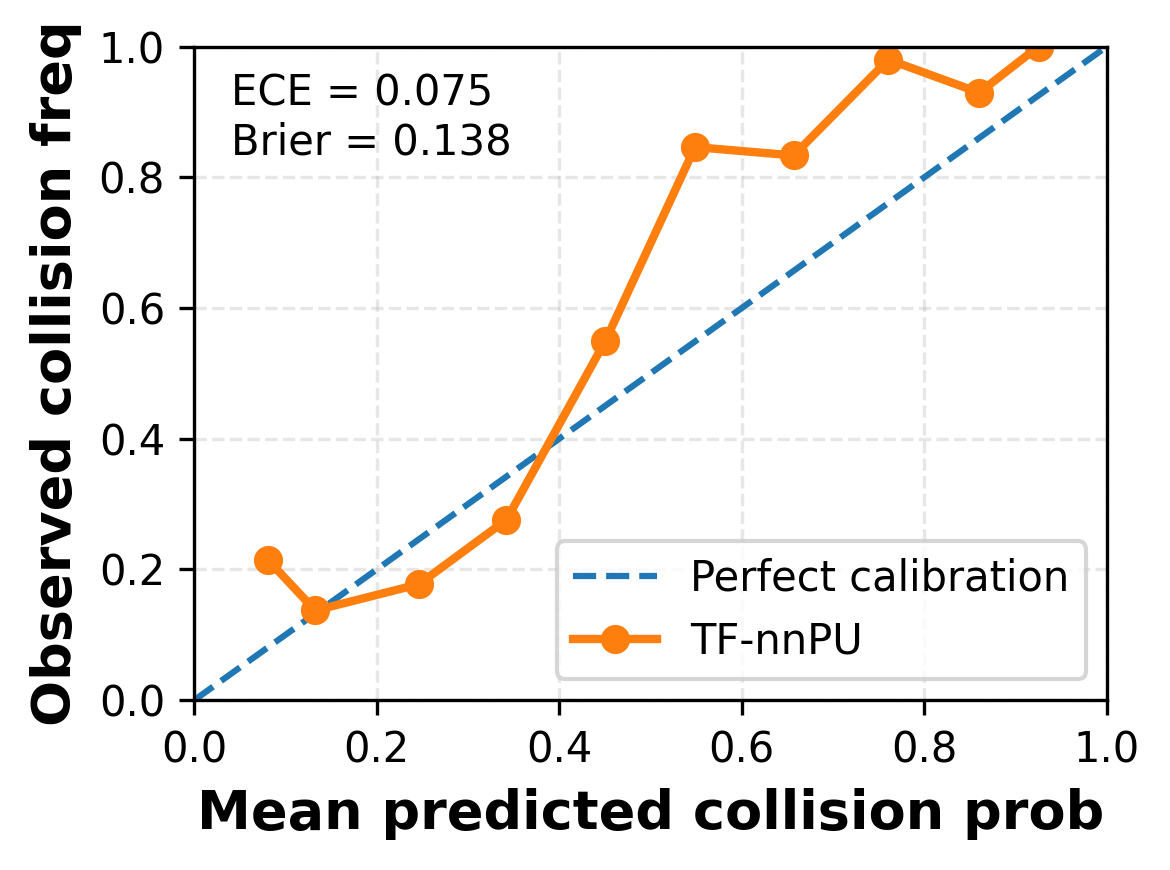

Saved: calibration_reliability_outcome.png


In [83]:
# ============================================================
# UPDATED RELIABILITY DIAGRAM
# Calibration target = eventual collision outcome Y^m
# ============================================================

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

# Perfect-calibration reference
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Perfect calibration",
)

# Empirical reliability curve
ax.plot(
    calibration_bins_df["mean_probability"],
    calibration_bins_df["collision_outcome_frequency"],
    marker="o",
    linewidth=2,
    label="TF-nnPU",
)

ax.set_xlabel("Mean predicted collision prob", fontsize=13, fontweight='bold')
ax.set_ylabel("Observed collision freq", fontsize=13, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(frameon=True)

ax.text(
    0.04,
    0.96,
    f"ECE = {cal_overall_ece:.3f}\nBrier = {cal_overall_brier:.3f}",
    transform=ax.transAxes,
    va="top",
)

plt.tight_layout()
plt.savefig(
    "calibration_reliability_outcome.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved: calibration_reliability_outcome.png")


In [78]:
# ============================================================
# COMPACT PAPER / REVIEWER-FACING CALIBRATION TABLE
# Representative prefix lengths + overall result
# ============================================================

representative_prefixes = [2, 5, 8, 10, 12, 15]

calibration_paper_table = calibration_by_prefix_df[
    calibration_by_prefix_df["prefix_length"].isin(
        representative_prefixes
    )
][
    [
        "prefix_length",
        "n_samples",
        "ECE",
        "Brier",
    ]
].copy()

overall_row = pd.DataFrame(
    [
        {
            "prefix_length": "Overall",
            "n_samples": len(calibration_predictions_df),
            "ECE": cal_overall_ece,
            "Brier": cal_overall_brier,
        }
    ]
)

calibration_paper_table = pd.concat(
    [
        calibration_paper_table,
        overall_row,
    ],
    ignore_index=True,
)

display(
    calibration_paper_table.round(
        {
            "ECE": 4,
            "Brier": 4,
        }
    )
)

calibration_paper_table.to_csv(
    "calibration_paper_table.csv",
    index=False,
)

print("Saved: calibration_paper_table.csv")


,prefix_length,n_samples,ECE,Brier
0,2,197,0.2000,0.2561
1,5,197,0.1668,0.2074
2,8,197,0.0837,0.1541
3,10,197,0.0830,0.0825
4,12,197,0.1213,0.0597
5,15,197,0.1314,0.0496
6,Overall,2758,0.0753,0.1381


Saved: calibration_paper_table.csv


COLLISION-DISTANCE CHARACTERIZATION
Total scenarios:       981
Collision scenarios:   371
Non-collision:         610

COLLISION MINIMUM-DISTANCE DISTRIBUTION


,Statistic,Distance
0,Mean,4.7285
1,Std,0.5531
2,Minimum,4.2123
3,Q05,4.2387
4,Q10,4.2554
5,Q25,4.3432
6,Median,4.5507
7,Q75,4.8783
8,Q90,5.4108
9,Q95,5.9218



FINAL FRAME VS. TRUE CLOSEST APPROACH
Mean(final - min):   0.0013
Median(final - min): 0.0000
Q95(final - min):    0.0000
Closest approach occurs at final frame: 97.04%
Final distance within 0.10 units of minimum: 100.00%
Final distance within 0.25 units of minimum: 100.00%
Final distance within 0.50 units of minimum: 100.00%
Final distance within 1.00 units of minimum: 100.00%

EMPIRICAL COLLISION-PROXIMITY BOUNDARY
Mean collision minimum distance:   4.7285
Median collision minimum distance: 4.5507
Q95 collision minimum distance:    5.9218

Recommended dataset-characterization boundary:
d_collision,95 = 5.9218

DATA-DRIVEN SCENARIO DISTRIBUTION
Collision: 371 (37.82%)
Near-miss non-collision: 382 (38.94% overall, 62.62% of non-collision)
Ordinary non-collision: 228 (23.24% overall, 37.38% of non-collision)

MINIMUM DISTANCE BY DATA-DRIVEN SCENARIO TYPE


,scenario_type_data_driven,N,Mean,Std,Minimum,Q25,Median,Q75,Maximum
0,Collision,371,4.7285,0.5531,4.2123,4.3432,4.5507,4.8783,7.1140
1,Near-miss non-collision,382,4.5725,0.7336,1.8987,4.0924,4.6830,5.0887,5.9022
2,Ordinary non-collision,228,8.7602,2.5765,5.9236,6.7728,7.8755,9.8524,15.3139



NEAR-MISS BOUNDARY SENSITIVITY


,Boundary,Distance,Near-miss scenarios,Near-miss % of non-collision
0,Collision Q75,4.878,235,38.525
1,Collision Q90,5.411,334,54.754
2,Collision Q95,5.922,382,62.623
3,Collision Q99,6.759,439,71.967
4,Collision maximum,7.114,463,75.902


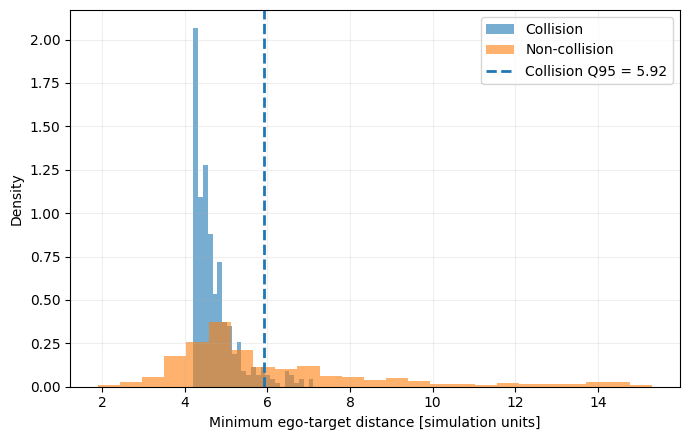


PAPER-READY SUMMARY


,Metric,Value
0,Collision scenarios,371
1,Non-collision scenarios,610
2,Mean collision minimum distance,4.729
3,Median collision minimum distance,4.551
4,Collision minimum-distance Q95,5.922
5,Data-driven near-miss scenarios,382
6,Ordinary non-collision scenarios,228
7,Near-miss fraction of non-collision,62.62%



Saved:
  collision_distance_statistics.csv
  near_miss_boundary_sensitivity.csv
  data_driven_near_miss_group_statistics.csv
  data_driven_near_miss_per_scenario.csv
  data_driven_near_miss_paper_summary.csv
  collision_distance_distribution.png


In [85]:
# ============================================================
# DATA-DRIVEN COLLISION-DISTANCE / NEAR-MISS CHARACTERIZATION
#
# PURPOSE:
#   1. Characterize the empirical collision-distance distribution.
#   2. Verify whether the final frame corresponds to closest approach.
#   3. Define a data-driven collision-proximity boundary.
#   4. Reclassify non-collision scenarios into:
#         - near-miss
#         - ordinary non-collision
#
# IMPORTANT:
#   This is ONLY for dataset characterization.
#   It does NOT replace d_th = 9 used by the PU/SAR training scheme.
#
# Feature order:
#   [distance, angle, sin(yaw), cos(yaw), speed]
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Reload the original dataset
# ------------------------------------------------------------

nm_raw_data = load_mix_txt(TXT_PATH)

nm_sequences, nm_frame_labels, nm_seq_ids = \
    group_sequences_with_frame_labels(nm_raw_data)


scenario_rows = []

for seq, labels, seq_id in zip(
    nm_sequences,
    nm_frame_labels,
    nm_seq_ids
):
    seq = np.asarray(seq)
    labels = np.asarray(labels)

    distance = seq[:, 0]

    # Sequence-level collision outcome
    Y = int(np.max(labels) > 0)

    d_min = float(np.min(distance))
    d_final = float(distance[-1])
    d_initial = float(distance[0])

    # Frame at which closest approach occurs
    min_frame = int(np.argmin(distance) + 1)

    scenario_rows.append({
        "sequence_id": int(seq_id),
        "collision": Y,
        "d_initial": d_initial,
        "d_min": d_min,
        "d_final": d_final,
        "min_frame": min_frame,

        # Difference between final separation and true closest approach
        "final_minus_min": d_final - d_min,
    })


nm_df = pd.DataFrame(scenario_rows)

collision_df = nm_df[
    nm_df["collision"] == 1
].copy()

noncollision_df = nm_df[
    nm_df["collision"] == 0
].copy()


print("=" * 80)
print("COLLISION-DISTANCE CHARACTERIZATION")
print("=" * 80)

print(f"Total scenarios:       {len(nm_df)}")
print(f"Collision scenarios:   {len(collision_df)}")
print(f"Non-collision:         {len(noncollision_df)}")


# ============================================================
# 2. COLLISION MINIMUM-DISTANCE DISTRIBUTION
# ============================================================

collision_min = collision_df["d_min"]

collision_stats = {
    "Mean": collision_min.mean(),
    "Std": collision_min.std(),
    "Minimum": collision_min.min(),
    "Q05": collision_min.quantile(0.05),
    "Q10": collision_min.quantile(0.10),
    "Q25": collision_min.quantile(0.25),
    "Median": collision_min.median(),
    "Q75": collision_min.quantile(0.75),
    "Q90": collision_min.quantile(0.90),
    "Q95": collision_min.quantile(0.95),
    "Maximum": collision_min.max(),
}

collision_stats_df = pd.DataFrame(
    collision_stats.items(),
    columns=["Statistic", "Distance"]
)

print("\n" + "=" * 80)
print("COLLISION MINIMUM-DISTANCE DISTRIBUTION")
print("=" * 80)

display(
    collision_stats_df.round(4)
)


# ============================================================
# 3. VERIFY WHETHER FINAL FRAME ~= CLOSEST APPROACH
# ============================================================

final_gap = collision_df["final_minus_min"]

print("\n" + "=" * 80)
print("FINAL FRAME VS. TRUE CLOSEST APPROACH")
print("=" * 80)

print(
    f"Mean(final - min):   "
    f"{final_gap.mean():.4f}"
)

print(
    f"Median(final - min): "
    f"{final_gap.median():.4f}"
)

print(
    f"Q95(final - min):    "
    f"{final_gap.quantile(0.95):.4f}"
)

print(
    f"Closest approach occurs at final frame: "
    f"{100 * (collision_df['min_frame'] == len(nm_sequences[0])).mean():.2f}%"
)

for tol in [0.1, 0.25, 0.5, 1.0]:

    fraction = (
        collision_df["final_minus_min"] <= tol
    ).mean()

    print(
        f"Final distance within {tol:.2f} units "
        f"of minimum: {100*fraction:.2f}%"
    )


# ============================================================
# 4. DATA-DRIVEN COLLISION PROXIMITY BOUNDARY
#
# Recommended definition:
# Q95 of minimum distance observed in true collision scenarios.
# ============================================================

D_COLLISION_Q95 = float(
    collision_min.quantile(0.95)
)

D_COLLISION_MEDIAN = float(
    collision_min.median()
)

D_COLLISION_MEAN = float(
    collision_min.mean()
)

print("\n" + "=" * 80)
print("EMPIRICAL COLLISION-PROXIMITY BOUNDARY")
print("=" * 80)

print(
    f"Mean collision minimum distance:   "
    f"{D_COLLISION_MEAN:.4f}"
)

print(
    f"Median collision minimum distance: "
    f"{D_COLLISION_MEDIAN:.4f}"
)

print(
    f"Q95 collision minimum distance:    "
    f"{D_COLLISION_Q95:.4f}"
)

print(
    "\nRecommended dataset-characterization boundary:"
)
print(
    f"d_collision,95 = {D_COLLISION_Q95:.4f}"
)


# ============================================================
# 5. DATA-DRIVEN NEAR-MISS DEFINITION
#
# Collision:
#     Y = 1
#
# Near miss:
#     Y = 0 and d_min <= Q95(collision d_min)
#
# Ordinary non-collision:
#     Y = 0 and d_min > Q95(collision d_min)
# ============================================================

def classify_scenario(row):

    if row["collision"] == 1:
        return "Collision"

    elif row["d_min"] <= D_COLLISION_Q95:
        return "Near-miss non-collision"

    else:
        return "Ordinary non-collision"


nm_df["scenario_type_data_driven"] = \
    nm_df.apply(classify_scenario, axis=1)


counts = (
    nm_df["scenario_type_data_driven"]
    .value_counts()
)

n_collision = int(
    (nm_df["scenario_type_data_driven"] == "Collision").sum()
)

n_near = int(
    (
        nm_df["scenario_type_data_driven"]
        == "Near-miss non-collision"
    ).sum()
)

n_safe = int(
    (
        nm_df["scenario_type_data_driven"]
        == "Ordinary non-collision"
    ).sum()
)

n_noncollision = n_near + n_safe


print("\n" + "=" * 80)
print("DATA-DRIVEN SCENARIO DISTRIBUTION")
print("=" * 80)

print(
    f"Collision: {n_collision} "
    f"({100*n_collision/len(nm_df):.2f}%)"
)

print(
    f"Near-miss non-collision: {n_near} "
    f"({100*n_near/len(nm_df):.2f}% overall, "
    f"{100*n_near/n_noncollision:.2f}% "
    f"of non-collision)"
)

print(
    f"Ordinary non-collision: {n_safe} "
    f"({100*n_safe/len(nm_df):.2f}% overall, "
    f"{100*n_safe/n_noncollision:.2f}% "
    f"of non-collision)"
)


# ============================================================
# 6. DISTANCE STATISTICS FOR NEW GROUPS
# ============================================================

new_group_stats = (
    nm_df
    .groupby("scenario_type_data_driven")
    ["d_min"]
    .agg(
        N="count",
        Mean="mean",
        Std="std",
        Minimum="min",
        Q25=lambda x: x.quantile(0.25),
        Median="median",
        Q75=lambda x: x.quantile(0.75),
        Maximum="max",
    )
    .reset_index()
)

print("\n" + "=" * 80)
print("MINIMUM DISTANCE BY DATA-DRIVEN SCENARIO TYPE")
print("=" * 80)

display(
    new_group_stats.round(4)
)


# ============================================================
# 7. COMPARE DIFFERENT EMPIRICAL COLLISION BOUNDARIES
#
# This lets you verify how sensitive the near-miss count is
# to Q90 vs Q95 vs maximum collision distance.
# ============================================================

candidate_boundaries = {
    "Collision Q75": collision_min.quantile(0.75),
    "Collision Q90": collision_min.quantile(0.90),
    "Collision Q95": collision_min.quantile(0.95),
    "Collision Q99": collision_min.quantile(0.99),
    "Collision maximum": collision_min.max(),
}


boundary_rows = []

for name, boundary in candidate_boundaries.items():

    n_nm = int(
        (
            noncollision_df["d_min"]
            <= boundary
        ).sum()
    )

    boundary_rows.append({
        "Boundary": name,
        "Distance": boundary,
        "Near-miss scenarios": n_nm,
        "Near-miss % of non-collision":
            100 * n_nm / len(noncollision_df),
    })


boundary_sensitivity_df = pd.DataFrame(
    boundary_rows
)


print("\n" + "=" * 80)
print("NEAR-MISS BOUNDARY SENSITIVITY")
print("=" * 80)

display(
    boundary_sensitivity_df.round(3)
)


# ============================================================
# 8. PLOT COLLISION VS NON-COLLISION MINIMUM DISTANCES
# ============================================================

plt.figure(figsize=(7, 4.5))

plt.hist(
    collision_df["d_min"],
    bins=25,
    alpha=0.6,
    label="Collision",
    density=True,
)

plt.hist(
    noncollision_df["d_min"],
    bins=25,
    alpha=0.6,
    label="Non-collision",
    density=True,
)

plt.axvline(
    D_COLLISION_Q95,
    linestyle="--",
    linewidth=2,
    label=(
        f"Collision Q95 = "
        f"{D_COLLISION_Q95:.2f}"
    ),
)

plt.xlabel("Minimum ego-target distance [simulation units]")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    "collision_distance_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 9. PAPER-READY SUMMARY
# ============================================================

paper_summary = pd.DataFrame({
    "Metric": [
        "Collision scenarios",
        "Non-collision scenarios",
        "Mean collision minimum distance",
        "Median collision minimum distance",
        "Collision minimum-distance Q95",
        "Data-driven near-miss scenarios",
        "Ordinary non-collision scenarios",
        "Near-miss fraction of non-collision",
    ],

    "Value": [
        n_collision,
        n_noncollision,

        f"{D_COLLISION_MEAN:.3f}",

        f"{D_COLLISION_MEDIAN:.3f}",

        f"{D_COLLISION_Q95:.3f}",

        n_near,

        n_safe,

        f"{100*n_near/n_noncollision:.2f}%",
    ]
})


print("\n" + "=" * 80)
print("PAPER-READY SUMMARY")
print("=" * 80)

display(paper_summary)


# ============================================================
# 10. SAVE RESULTS
# ============================================================

collision_stats_df.to_csv(
    "collision_distance_statistics.csv",
    index=False,
)

boundary_sensitivity_df.to_csv(
    "near_miss_boundary_sensitivity.csv",
    index=False,
)

new_group_stats.to_csv(
    "data_driven_near_miss_group_statistics.csv",
    index=False,
)

nm_df.to_csv(
    "data_driven_near_miss_per_scenario.csv",
    index=False,
)

paper_summary.to_csv(
    "data_driven_near_miss_paper_summary.csv",
    index=False,
)


print("\nSaved:")
print("  collision_distance_statistics.csv")
print("  near_miss_boundary_sensitivity.csv")
print("  data_driven_near_miss_group_statistics.csv")
print("  data_driven_near_miss_per_scenario.csv")
print("  data_driven_near_miss_paper_summary.csv")
print("  collision_distance_distribution.png")